# 14. Dimensionality reduction and matrix factorisation

A single 8×8 digit image is a point in $\mathbb{R}^{64}$; a customer record has dozens of
columns; a document over a vocabulary of 50 000 words lives in $\mathbb{R}^{50\,000}$. Yet
the *interesting* variation in such data is usually confined to far fewer directions: the
digits do not fill the 64-dimensional cube uniformly, they lie close to a thin, curved
subset of it. **Dimensionality reduction** is the art of finding a small number of
coordinates that capture what matters, and **matrix factorisation** is the algebraic
machinery behind most of it — the same machinery that recommends films and finds topics
in text.

This notebook moves from the linear, exactly solvable case (principal component analysis,
which we derive and implement three ways) through its relatives (LDA, random projections,
NMF, latent-factor recommenders) to the non-linear manifold learners (kernel PCA, Isomap,
LLE, t-SNE, UMAP) that produce the beautiful — and easily misread — 2-D pictures of
high-dimensional data.

**Prerequisites:** notebook 2 (eigen-decomposition, SVD, projections), notebook 5
(cross-validation), notebook 13 (clustering — several of the datasets and the "no ground
truth" mindset carry over). Notebook 8 introduced the curse of dimensionality that we are
now fighting.

## Learning objectives

After working through this notebook you will be able to

- explain why high-dimensional data can often be compressed, and state the manifold hypothesis;
- derive PCA as variance maximisation *and* as reconstruction-error minimisation, and implement it via the covariance eigen-decomposition and via the SVD;
- read scree plots, choose the number of components, interpret loadings, and use PCA correctly inside a pipeline (scaling!);
- contrast PCA with LDA (supervised), random projections (Johnson–Lindenstrauss), NMF (parts-based) and truncated SVD (LSA);
- implement a latent-factor recommender by alternating least squares and evaluate it with held-out RMSE;
- describe how kernel PCA, Isomap, LLE, t-SNE and UMAP work and what each preserves;
- run t-SNE with an appropriate perplexity and avoid the classic misreadings of its output;
- state the strengths, weaknesses and failure modes of each method, and *demonstrate* two of them — that PCA discards a low-variance discriminative direction, and that a t-SNE map preserves neither cluster sizes nor inter-cluster distances;
- tune the parameters that matter — `n_components`, `whiten`, the scaling decision, `perplexity`, `learning_rate`, `max_iter`, `n_neighbors`/`min_dist`, and the rank and regularisation of a factorisation — with validation curves and heat maps;
- decide when dimensionality reduction is a visualisation tool and when it is a feature-engineering step, and evaluate it downstream on a real dataset from end to end.

## Setup

In [1]:
import time                        # time.perf_counter() times the solvers and embeddings below

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns              # imported as in the other notebooks; not used in this one

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_reviews() returns the bundled product-review corpus as a DataFrame (used for topics in section 3.3)
from course_utils import set_style, PALETTE, load_reviews

RANDOM_STATE = 42                          # one fixed seed so every run gives the same numbers
rng = np.random.default_rng(RANDOM_STATE)  # seeded random-number generator for all synthetic data
set_style()                                # apply the course-wide matplotlib settings once

## 1. Why reduce dimensions?

There are four classic reasons, and a fifth that explains why the first four are possible.

1. **Visualisation.** We can look at two, perhaps three, dimensions. Every "map" of a
   dataset — of customers, of documents, of cell types — is a dimensionality reduction.
2. **Noise removal.** Directions with little variance are often measurement noise;
   projecting them away can *improve* a downstream classifier (we will see this on the
   digits: nearest neighbours in 20 principal components beat nearest neighbours in the
   original 64 pixels).
3. **Compression and speed.** A 64-dimensional image stored as 20 coefficients; a
   $50\,000$-word document as a 100-dimensional vector. Distances, nearest-neighbour
   searches and model fits all get cheaper.
4. **Fighting the curse of dimensionality.** Notebook 8 showed that in high dimensions
   pairwise distances concentrate — the nearest and the farthest neighbour become almost
   equally far — so that local methods (kNN, kernel density estimation, DBSCAN) degrade.
   Reducing $d$ before applying them restores contrast in the distances.

The fifth reason is the **manifold hypothesis**: real high-dimensional data are typically
generated by a small number of underlying degrees of freedom (the writer's hand position,
the pose and lighting of a face, the topic of a document), so the data concentrate near a
low-dimensional *manifold* — a curved surface — embedded in $\mathbb{R}^d$. Linear methods
approximate that surface by a flat subspace; non-linear methods try to "unroll" it.

> **Key idea.** Dimensionality reduction learns a map $\mathbf{x} \in \mathbb{R}^d \mapsto
> \mathbf{z} \in \mathbb{R}^k$ with $k \ll d$ that preserves *something* — global variance
> (PCA), class separation (LDA), pairwise distances (random projections, Isomap), local
> neighbourhoods (LLE, t-SNE, UMAP) or non-negative parts (NMF). Which "something" you need
> decides the method, and no single picture preserves everything.

## 2. Principal component analysis

### 2.1 Intuition and two derivations

Imagine a cloud of centred data points in $\mathbb{R}^d$. PCA asks: *along which single
direction does the cloud spread out the most?* That direction is the first principal
component. The second is the direction of largest spread among those orthogonal to the
first, and so on. Equivalently — and this was Pearson's (1901) original formulation — PCA
finds the $k$-dimensional flat that is *closest* to the points in the least-squares sense.

> **Real-life example.** A clothing manufacturer measures height, arm length, inside-leg length,
> chest and waist of 10 000 customers to design its size chart. The five numbers rise and fall
> together, so the first principal component is overall body size (all five weights positive)
> and the second contrasts girth with length — stocky versus slender. Two scores per customer
> instead of five measurements are enough to define sizes such as "M regular" and "M long".

**Setting.** Let $\mathbf{X} \in \mathbb{R}^{n \times d}$ be the data matrix with the
column means subtracted (centring is part of PCA; without it the first component just
points at the mean). The sample covariance matrix is

$$
\mathbf{C} \;=\; \frac{1}{n-1}\,\mathbf{X}^\top\mathbf{X} \;\in\; \mathbb{R}^{d \times d},
$$

symmetric and positive semi-definite, hence with real eigenvalues
$\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_d \ge 0$ and orthonormal eigenvectors
$\mathbf{u}_1, \dots, \mathbf{u}_d$ (notebook 2).

**Variance maximisation.** Project every point onto a unit vector $\mathbf{u}$:
$z_i = \mathbf{u}^\top\mathbf{x}_i$. Because the data are centred the $z_i$ have mean zero,
and their variance is

$$
\frac{1}{n-1}\sum_{i=1}^n z_i^2 \;=\; \frac{1}{n-1}\,\mathbf{u}^\top\mathbf{X}^\top\mathbf{X}\,\mathbf{u} \;=\; \mathbf{u}^\top\mathbf{C}\,\mathbf{u}.
$$

We maximise this subject to $\|\mathbf{u}\|_2 = 1$ (otherwise the variance could be made
arbitrarily large by scaling $\mathbf{u}$). With a Lagrange multiplier $\lambda$ the
objective is $\mathbf{u}^\top\mathbf{C}\mathbf{u} - \lambda(\mathbf{u}^\top\mathbf{u} - 1)$;
setting its gradient with respect to $\mathbf{u}$ to zero gives

$$
2\,\mathbf{C}\mathbf{u} - 2\lambda\mathbf{u} = \mathbf{0} \quad\Longleftrightarrow\quad \mathbf{C}\mathbf{u} = \lambda\mathbf{u}.
$$

So the optimum is an *eigenvector* of $\mathbf{C}$, and the variance it captures is
$\mathbf{u}^\top\mathbf{C}\mathbf{u} = \lambda\,\mathbf{u}^\top\mathbf{u} = \lambda$ — its
eigenvalue. The best direction is therefore the eigenvector with the *largest* eigenvalue,
$\mathbf{u}_1$. Repeating the argument in the orthogonal complement of the components
already found yields $\mathbf{u}_2, \mathbf{u}_3, \dots$ (Hotelling, 1933).

**Reconstruction-error minimisation.** Let $\mathbf{U}_k = [\mathbf{u}_1 \cdots \mathbf{u}_k]$
be any $d \times k$ matrix with orthonormal columns. The orthogonal projection of
$\mathbf{x}_i$ onto its column space is $\mathbf{U}_k\mathbf{U}_k^\top\mathbf{x}_i$, and by
Pythagoras

$$
\sum_{i=1}^n \big\|\mathbf{x}_i - \mathbf{U}_k\mathbf{U}_k^\top\mathbf{x}_i\big\|_2^2
\;=\; \underbrace{\sum_{i=1}^n \|\mathbf{x}_i\|_2^2}_{\text{fixed}} \;-\; \sum_{i=1}^n \big\|\mathbf{U}_k^\top\mathbf{x}_i\big\|_2^2 .
$$

Minimising the reconstruction error is therefore the same as maximising the projected
variance $\sum_i \|\mathbf{U}_k^\top\mathbf{x}_i\|^2 = (n-1)\sum_{j \le k}\mathbf{u}_j^\top\mathbf{C}\mathbf{u}_j$
— the two views coincide, and the minimal reconstruction error equals
$(n-1)\sum_{j > k}\lambda_j$: **the sum of the discarded eigenvalues** (we will verify this
numerically).

**The SVD route.** Write the thin singular value decomposition $\mathbf{X} = \mathbf{U}\mathbf{S}\mathbf{V}^\top$
(notebook 2), with singular values $s_1 \ge s_2 \ge \dots$. Then
$\mathbf{X}^\top\mathbf{X} = \mathbf{V}\mathbf{S}^2\mathbf{V}^\top$, so the right singular
vectors $\mathbf{v}_j$ are the eigenvectors of $\mathbf{C}$ with eigenvalues
$\lambda_j = s_j^2/(n-1)$, and the projected coordinates (*scores*) are
$\mathbf{Z} = \mathbf{X}\mathbf{V}_k = \mathbf{U}_k\mathbf{S}_k$. The SVD never forms
$\mathbf{X}^\top\mathbf{X}$, which squares the condition number of $\mathbf{X}$ and can
lose precision; that is why scikit-learn (and every serious implementation) uses the SVD.

**Vocabulary.**

| Term | Meaning |
|---|---|
| components / loadings | the eigenvectors $\mathbf{u}_j$ (rows of `pca.components_`): the weight of each original feature in component $j$ |
| scores / projections | $\mathbf{Z} = \mathbf{X}\mathbf{U}_k$ (`pca.transform(X)`): the new coordinates |
| explained variance | $\lambda_j$; *ratio* $\lambda_j / \sum_l \lambda_l$ |
| reconstruction | $\hat{\mathbf{X}} = \mathbf{Z}\mathbf{U}_k^\top + \bar{\mathbf{x}}$ (`pca.inverse_transform`) |
| whitening | additionally dividing each score by $\sqrt{\lambda_j}$ so that all components have unit variance |

### 2.2 PCA from scratch, three ways, and a check against scikit-learn

We use the digits data (1 797 images of handwritten digits, 8×8 pixels, 64 features) —
Alimoglu & Alpaydin's dataset that ships with scikit-learn.

In [2]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()                             # a Bunch (dict-like object) with .data, .target, .images, ...
X_digits, y_digits = digits.data, digits.target    # X: (1797, 64), one flattened 8x8 image per row; y: digit 0-9
n, d = X_digits.shape
print(f"digits: n = {n} images, d = {d} pixel features, {len(np.unique(y_digits))} classes")

def pca_eig(X, k):
    """PCA via the eigen-decomposition of the covariance matrix.

    X is the (n, d) data matrix, k the number of components to keep. Returns the components (k, d),
    all d eigenvalues in descending order, and the scores (n, k).
    """
    X_centred = X - X.mean(axis=0)                     # subtract each column's mean (broadcast over the rows)
    C = X_centred.T @ X_centred / (len(X) - 1)         # sample covariance matrix, (d, d)
    eigvals, eigvecs = np.linalg.eigh(C)              # eigh: symmetric matrix, ascending order
    order = np.argsort(eigvals)[::-1]                  # sort descending
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]   # eigenvectors are the columns, so reorder the columns
    return eigvecs[:, :k].T, eigvals, X_centred @ eigvecs[:, :k]   # components (k x d), all eigenvalues, scores

def pca_svd(X, k):
    """PCA via the singular value decomposition of the centred data.

    Same inputs and outputs as pca_eig, but never forms the covariance matrix (numerically safer).
    """
    X_centred = X - X.mean(axis=0)
    # thin SVD (n > d here): U (n, d), singular values s (d,) in descending order, Vt (d, d)
    U, s, Vt = np.linalg.svd(X_centred, full_matrices=False)
    eigvals = s**2 / (len(X) - 1)                      # lambda_j = s_j^2 / (n - 1)
    return Vt[:k], eigvals, U[:, :k] * s[:k]           # scores = U_k S_k = X V_k

k = 10
comp_eig, ev_eig, Z_eig = pca_eig(X_digits, k)
comp_svd, ev_svd, Z_svd = pca_svd(X_digits, k)
# scikit-learn's PCA: n_components = how many to keep (random_state only matters for the arpack/randomized solvers)
sk = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_digits)
Z_sk = sk.transform(X_digits)                      # subtract the fitted mean_, project onto components_ -> (n, k)

# Eigenvectors are defined only up to sign, so compare |components| and align the signs of the scores.
# np.allclose(a, b) is True when all entries agree up to floating-point tolerance;
# explained_variance_ holds the k largest eigenvalues, components_ the components as rows, (k, d)
print("eigenvalues  eig vs svd     :", np.allclose(ev_eig, ev_svd))
print("eigenvalues  ours vs sklearn:", np.allclose(ev_svd[:k], sk.explained_variance_))
print("components   eig vs svd     :", np.allclose(np.abs(comp_eig), np.abs(comp_svd)))
print("components   ours vs sklearn:", np.allclose(np.abs(comp_svd), np.abs(sk.components_)))
# the column sums of Z_svd * Z_sk are positive where two score columns point the same way, negative where flipped
signs = np.sign(np.sum(Z_svd * Z_sk, axis=0))          # +1 or -1 per component
print("scores       ours vs sklearn:", np.allclose(Z_svd * signs, Z_sk))   # (n, k) * (k,) flips whole columns
# explained_variance_ratio_: each component's eigenvalue divided by the total variance
print(f"first five explained-variance ratios: {np.round(sk.explained_variance_ratio_[:5], 3)}")

digits: n = 1797 images, d = 64 pixel features, 10 classes
eigenvalues  eig vs svd     : True
eigenvalues  ours vs sklearn: True
components   eig vs svd     : True
components   ours vs sklearn: True
scores       ours vs sklearn: True
first five explained-variance ratios: [0.149 0.136 0.118 0.084 0.058]


All three agree to floating-point precision (up to the sign of each component, which is
arbitrary — scikit-learn fixes it with a deterministic convention). From now on we use
`PCA`, but you know exactly what it does: centre, SVD, keep $k$ right singular vectors.

### 2.3 How many components? Scree plots and explained variance

Each eigenvalue $\lambda_j$ is the variance along component $j$, and
$\sum_j \lambda_j = \operatorname{tr}(\mathbf{C})$ is the total variance. The
*explained-variance ratio* $\lambda_j / \sum_l \lambda_l$ and its cumulative sum are the
basis for the usual heuristics:

- keep enough components to explain a target fraction of the variance (90 %, 95 %, 99 %);
- look for an "elbow" in the **scree plot** (eigenvalues in decreasing order) after which
  the curve flattens — the flat tail is often noise;
- or, best of all when there is a downstream task, treat $k$ as a hyper-parameter and
  choose it by cross-validation (section 2.6).

> **Real-life example.** A psychologist gives 5 000 people a 50-question personality
> questionnaire (answers on a 1–5 scale). The scree plot of the answers typically falls steeply
> over the first five or so components and then flattens: the questionnaire was built to measure
> five broad traits, and the remaining directions are mostly question-specific noise. Keeping
> five scores per person instead of 50 answers is the decision the elbow supports.

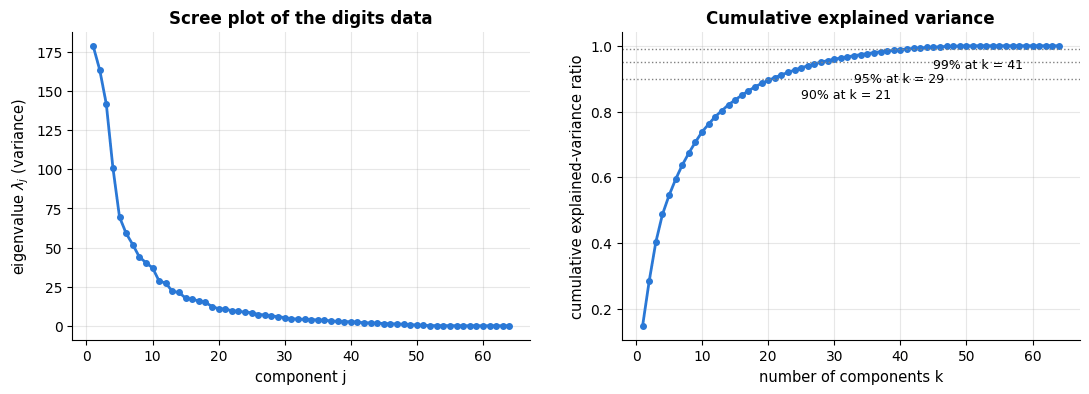

components needed for 90 % / 95 % / 99 % of the variance: 21 / 29 / 41 (of 64)


In [3]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_digits)    # no n_components: keep all 64 components
evr = pca_full.explained_variance_ratio_                  # (64,) share of the total variance per component
cum = np.cumsum(evr)                                      # cum[k - 1] = share kept by the first k components
# np.searchsorted(cum, t) is the first index where cum >= t; + 1 turns that index into a number of components.
# the generator expression yields three values, which are unpacked into three names
k_90, k_95, k_99 = (np.searchsorted(cum, t) + 1 for t in (0.90, 0.95, 0.99))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# explained_variance_ holds the eigenvalues lambda_j; ms = marker size
axes[0].plot(np.arange(1, d + 1), pca_full.explained_variance_, marker="o", ms=4)
axes[0].set_xlabel("component j")
axes[0].set_ylabel("eigenvalue $\\lambda_j$ (variance)")
axes[0].set_title("Scree plot of the digits data")
axes[1].plot(np.arange(1, d + 1), cum, marker="o", ms=4)
for t, kk in [(0.90, k_90), (0.95, k_95), (0.99, k_99)]:
    axes[1].axhline(t, color="gray", ls=":", lw=1)            # dotted horizontal line at the target fraction
    # annotate(text, xy, xytext=...): text placed at xytext, labelling the point xy; {t:.0%} prints 0.9 as 90%
    axes[1].annotate(f"{t:.0%} at k = {kk}", (kk, t), xytext=(kk + 4, t - 0.06), fontsize=9)
axes[1].set_xlabel("number of components k")
axes[1].set_ylabel("cumulative explained-variance ratio")
axes[1].set_title("Cumulative explained variance")
plt.show()
print(f"components needed for 90 % / 95 % / 99 % of the variance: {k_90} / {k_95} / {k_99} (of {d})")

Roughly half of the 64 pixel dimensions carry 99 % of the variance, and the last dozen
eigenvalues are nearly zero — some border pixels are almost always blank, so those
directions carry no information at all.

**Whitening.** `PCA(whiten=True)` divides each score by $\sqrt{\lambda_j}$, so the
transformed features have unit variance and are uncorrelated (identity covariance). This
is useful before algorithms that assume isotropic inputs (some clustering methods, ICA),
but it *amplifies* low-variance directions — including noise — so it is not a default.

> **Real-life example.** A neuroscience lab records brain activity with 64 scalp electrodes
> (EEG). Neighbouring electrodes pick up largely the same signals, so the channels are strongly
> correlated. Before independent component analysis (ICA) separates eye blinks and muscle
> twitches from brain activity, the recordings are whitened: once the channels are uncorrelated
> with unit variance, ICA only has to find a rotation.

In [4]:
# whiten=True divides each score by sqrt(lambda_j); fit_transform = fit, then transform the same data -> (1797, 10)
Z_white = PCA(n_components=10, whiten=True, random_state=RANDOM_STATE).fit_transform(X_digits)
cov_white = np.cov(Z_white.T)       # np.cov treats rows as variables, hence the .T -> (10, 10) covariance matrix
# np.diag(M) is the diagonal of M (the variances). |cov - I| is a covariance off the diagonal and the gap
# between a variance and 1 on it; :.1e prints in scientific notation
print("whitened scores: variances", np.round(np.diag(cov_white)[:5], 3),
      "| largest off-diagonal covariance", f"{np.abs(cov_white - np.eye(10)).max():.1e}")

whitened scores: variances [1. 1. 1. 1. 1.] | largest off-diagonal covariance 1.0e-15


### 2.4 Eigen-digits: looking at components and reconstructions

Because the features are pixels, the components are images too. The mean digit plus a
weighted sum of the first $k$ "eigen-digits" reconstructs any image; the more components,
the sharper the reconstruction.

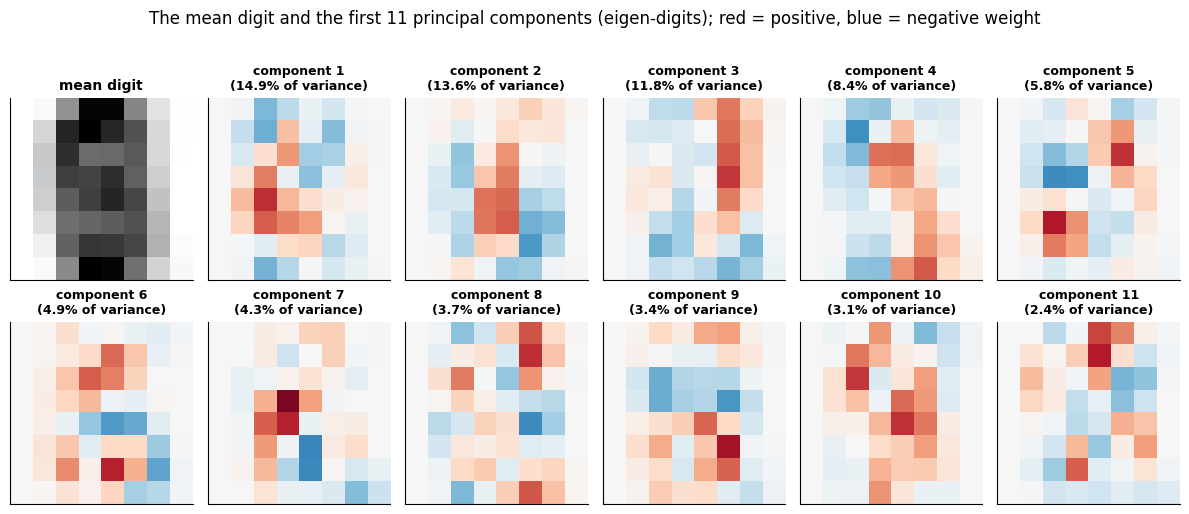

In [5]:
fig, axes = plt.subplots(2, 6, figsize=(12, 5.2))
# mean_ is the per-pixel mean that PCA subtracts, (64,); reshape(8, 8) turns a flat row back into an image.
# imshow draws a 2-D array as an image; cmap="gray_r" is the reversed grey scale (high values dark)
axes[0, 0].imshow(pca_full.mean_.reshape(8, 8), cmap="gray_r")
axes[0, 0].set_title("mean digit", fontsize=10)
for j in range(11):
    ax = axes.flat[j + 1]               # .flat walks the 2 x 6 grid row by row; + 1 skips the mean-digit panel
    # RdBu_r: red = positive, blue = negative; vmin / vmax symmetric around 0 so that 0 is white
    ax.imshow(pca_full.components_[j].reshape(8, 8), cmap="RdBu_r", vmin=-0.5, vmax=0.5)
    ax.set_title(f"component {j + 1}\n({evr[j]:.1%} of variance)", fontsize=9)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)     # ";" separates statements: hide ticks and grid
fig.suptitle("The mean digit and the first 11 principal components (eigen-digits); red = positive, blue = negative weight", y=1.02)
plt.tight_layout()
plt.show()

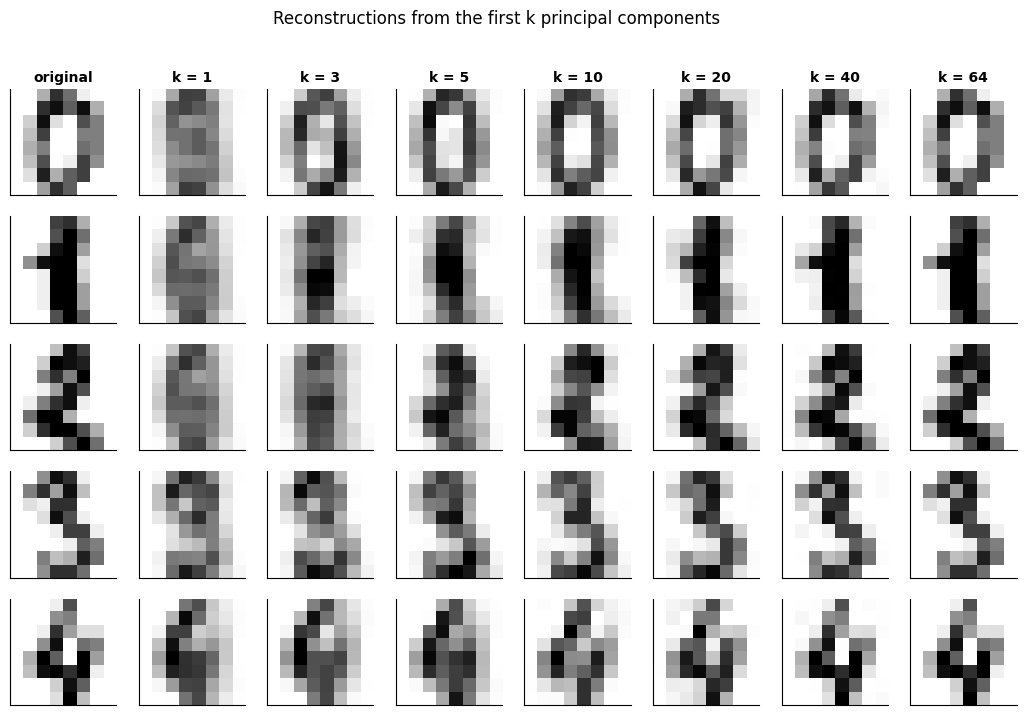

In [6]:
ks = [1, 3, 5, 10, 20, 40, 64]
examples = [0, 1, 2, 3, 4]                       # the first five images (digits 0, 1, 2, 3, 4)
fig, axes = plt.subplots(len(examples), len(ks) + 1, figsize=(13, 8))   # one row per image, column 0 = original
for r, i in enumerate(examples):
    axes[r, 0].imshow(X_digits[i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)   # pixel values run from 0 to 16
    axes[r, 0].set_title("original" if r == 0 else "", fontsize=10)               # titles on the top row only
    for c, kk in enumerate(ks, start=1):         # start=1: the reconstructions fill columns 1, 2, ...
        pca_k = PCA(n_components=kk, random_state=RANDOM_STATE).fit(X_digits)
        # X_digits[i:i + 1] keeps the 2-D shape (1, 64) that transform expects; transform gives (1, kk) scores and
        # inverse_transform maps them back to pixels (scores @ components_ + mean_) -> (1, 64)
        recon = pca_k.inverse_transform(pca_k.transform(X_digits[i:i + 1]))
        axes[r, c].imshow(recon.reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
        if r == 0:
            axes[r, c].set_title(f"k = {kk}", fontsize=10)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Reconstructions from the first k principal components")
plt.show()

Ten components already give recognisable digits; twenty are nearly indistinguishable
from the original at this resolution. Let us verify the theory of section 2.1: the mean
squared reconstruction error must equal the sum of the discarded eigenvalues.

In [7]:
rows = []
for kk in [1, 5, 10, 20, 30, 40]:
    pca_k = PCA(n_components=kk, random_state=RANDOM_STATE).fit(X_digits)
    X_rec = pca_k.inverse_transform(pca_k.transform(X_digits))     # compress to kk numbers per image and back
    err = np.mean(np.sum((X_digits - X_rec) ** 2, axis=1))        # mean over images of the squared error
    theory = pca_full.explained_variance_[kk:].sum() * (n - 1) / n  # discarded eigenvalues (n-1 -> n: population variance)
    # one dict per k; cum[kk - 1] is the variance ratio kept by the first kk components
    rows.append({"k": kk, "reconstruction MSE": err, "discarded eigenvalues": theory, "cum. variance ratio": cum[kk - 1]})
# a list of dicts becomes a DataFrame with one row per dict; set_index("k") makes the k column the row labels
pd.DataFrame(rows).set_index("k").round(2)

,reconstruction MSE,discarded eigenvalues,cum. variance ratio
k,,,
1,1022.57,1022.57,0.15
5,546.72,546.72,0.54
10,314.51,314.51,0.74
20,126.99,126.99,0.89
30,49.16,49.16,0.96
40,14.17,14.17,0.99


### 2.5 Scaling matters: PCA on the wine data

PCA maximises *variance*, and variance depends on units. If one feature is measured in
milligrams and another in kilograms, the first will dominate the covariance matrix and the
first component will simply point along it. The wine data (178 wines, 13 chemical
measurements, 3 cultivars) show this vividly: `proline` has a standard deviation of about
314, most other features have standard deviations below 3.

feature standard deviations (raw units):
proline              314.02
magnesium             14.24
alcalinity_of_ash      3.33
color_intensity        2.31


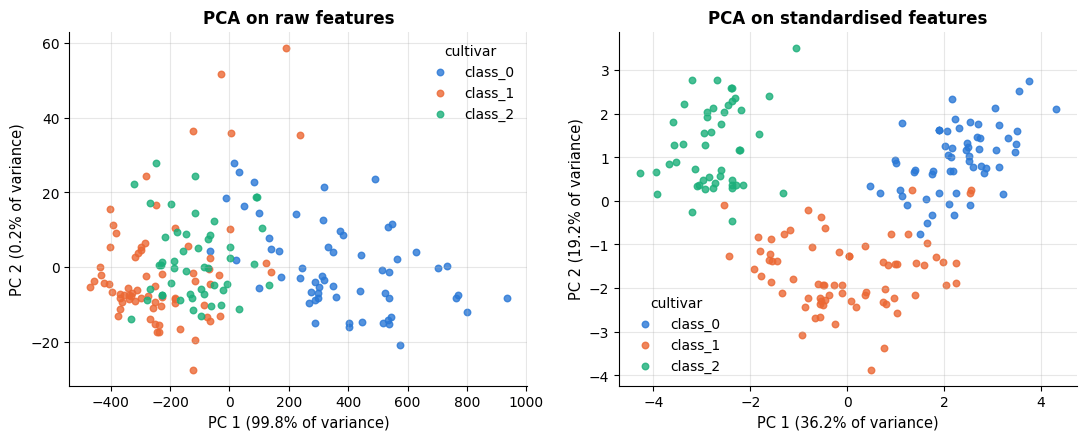

PC 1 loadings on raw data   (largest): proline weight 1.000


In [8]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()                       # 178 wines x 13 chemical measurements, 3 cultivars
X_wine, y_wine = wine.data, wine.target
# the standard deviation of every column, labelled with the feature names
feature_std = pd.Series(X_wine.std(axis=0), index=wine.feature_names).round(2)
print("feature standard deviations (raw units):")
# largest first, keep four rows; to_string() prints them without the dtype line
print(feature_std.sort_values(ascending=False).head(4).to_string())

# StandardScaler rescales every column to mean 0 and standard deviation 1 (fit_transform learns and applies it)
X_wine_std = StandardScaler().fit_transform(X_wine)
pca_raw = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_wine)        # PCA on the raw units
pca_std = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_wine_std)    # PCA on the standardised features

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, pca_m, Xm, title in [(axes[0], pca_raw, X_wine, "PCA on raw features"),
                             (axes[1], pca_std, X_wine_std, "PCA on standardised features")]:
    Z = pca_m.transform(Xm)                      # (178, 2) scores
    for c in range(3):                           # one scatter per cultivar, so each gets a colour and a legend entry
        # the boolean mask y_wine == c selects the rows of cultivar c; column 0 is PC 1, column 1 is PC 2
        ax.scatter(Z[y_wine == c, 0], Z[y_wine == c, 1], s=22, alpha=0.8, color=PALETTE[c], label=wine.target_names[c])
    ax.set_xlabel(f"PC 1 ({pca_m.explained_variance_ratio_[0]:.1%} of variance)")
    ax.set_ylabel(f"PC 2 ({pca_m.explained_variance_ratio_[1]:.1%} of variance)")
    ax.set_title(title)
    ax.legend(title="cultivar")
plt.show()
# np.argmax(np.abs(...)) is the position of PC 1's largest-magnitude loading; feature_std.index holds the names
print("PC 1 loadings on raw data   (largest):", feature_std.index[np.argmax(np.abs(pca_raw.components_[0]))],
      f"weight {pca_raw.components_[0][np.argmax(np.abs(pca_raw.components_[0]))]:.3f}")

On raw features PC 1 is essentially `proline` (loading ≈ 1.0) and "explains" 99.8 % of
the variance — of a quantity that is dominated by units, not by chemistry. After
standardisation, the first two components separate the three cultivars nicely, and the
loadings become interpretable:

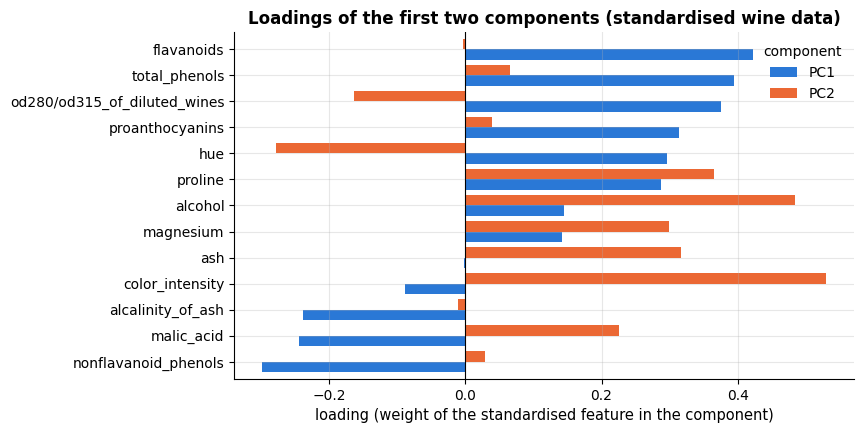

In [9]:
# components_ is (2, 13); .T gives one row per feature and one column per component
loadings = pd.DataFrame(pca_std.components_.T, index=wine.feature_names, columns=["PC1", "PC2"])
fig, ax = plt.subplots(figsize=(8, 4.5))
# pandas plotting: .plot.barh draws one group of horizontal bars per row, one bar per column (PC1, PC2)
loadings.sort_values("PC1").plot.barh(ax=ax, color=[PALETTE[0], PALETTE[1]], width=0.8)
ax.axvline(0, color="black", lw=0.8)     # vertical reference line at zero loading
ax.set_xlabel("loading (weight of the standardised feature in the component)")
ax.set_title("Loadings of the first two components (standardised wine data)")
ax.legend(title="component")
plt.show()

PC 1 contrasts the phenolic compounds (`flavanoids`, `total_phenols`, `proanthocyanins`,
`od280/od315`) with `malic_acid`, `alcalinity_of_ash` and `nonflavanoid_phenols`: it is a
"phenol richness" axis. PC 2 is dominated by `color_intensity`, `alcohol` and `proline`.
Reading loadings this way is how PCA is used in the sciences to *name* latent factors — with
the caveat that components are constrained to be orthogonal, which real factors need not be.

> **Warning.** Always standardise (or otherwise put on comparable scales) before PCA
> unless the features genuinely share a unit — pixels of one image, counts of one kind.
> And, as with every fitted transformation, fit the scaler and the PCA on training data
> only, inside a `Pipeline` (notebook 5, section 7.1).

### 2.6 PCA as preprocessing: choosing $k$ by cross-validation

When the reduced data feed a model, the number of components is a hyper-parameter like any
other. Here we put PCA in front of a $k$-nearest-neighbour classifier and a logistic
regression on the digits and cross-validate the number of components.

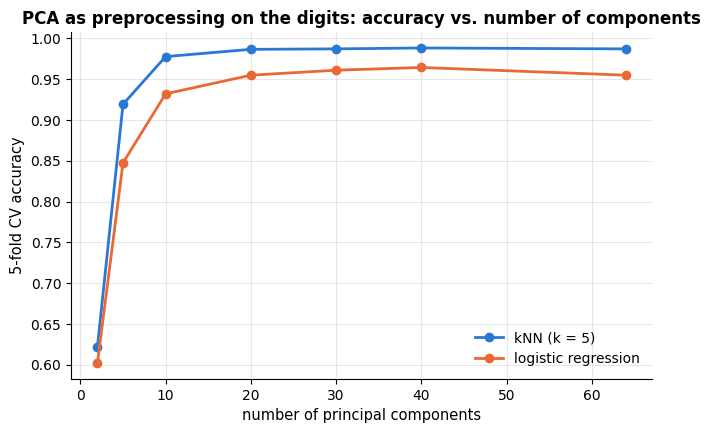

kNN (k = 5)          best k = 40 (accuracy 0.988);  all 64 components: 0.987
logistic regression  best k = 40 (accuracy 0.964);  all 64 components: 0.955


In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 5 folds that keep the class proportions; shuffle=True shuffles the rows (with this seed) before splitting
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
n_comps = [2, 5, 10, 20, 30, 40, 64]
scores = {"kNN (k = 5)": [], "logistic regression": []}      # model name -> mean CV accuracy for each k
for kk in n_comps:
    # Pipeline([(name, step), ...]) chains the steps: fit runs each step's fit_transform in turn and fits the last one,
    # so inside cross-validation the PCA is refitted on the training folds only
    knn_pipe = Pipeline([("pca", PCA(n_components=kk, random_state=RANDOM_STATE)),
                         ("knn", KNeighborsClassifier(n_neighbors=5))])   # vote of the 5 nearest points
    lr_pipe = Pipeline([("pca", PCA(n_components=kk, random_state=RANDOM_STATE)), ("scale", StandardScaler()),
                        ("lr", LogisticRegression(max_iter=3000))])       # max_iter: solver iteration limit
    # cross_val_score fits on 4 folds and scores (accuracy) on the 5th, once per fold -> array of 5 scores
    scores["kNN (k = 5)"].append(cross_val_score(knn_pipe, X_digits, y_digits, cv=cv).mean())
    scores["logistic regression"].append(cross_val_score(lr_pipe, X_digits, y_digits, cv=cv).mean())

fig, ax = plt.subplots()
for name, s in scores.items():
    ax.plot(n_comps, s, marker="o", label=name)
ax.set_xlabel("number of principal components")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("PCA as preprocessing on the digits: accuracy vs. number of components")
ax.legend()
plt.show()
for name, s in scores.items():
    # n_comps[argmax] is the k with the best score; {name:20s} pads to 20 characters, {...:2d} is an integer of width 2
    print(f"{name:20s} best k = {n_comps[int(np.argmax(s))]:2d} (accuracy {max(s):.3f});  all 64 components: {s[-1]:.3f}")

Two lessons. First, 20–30 components carry practically all the class information — a
two- to threefold compression at no cost in accuracy. Second, nothing is lost by
discarding the trailing components, and a little is gained: kNN with 30–40 components is
at least as accurate as with all 64 pixels, and logistic regression is almost a point
*more* accurate. The trailing components are mostly noise (some border pixels are nearly
constant), which a model must otherwise learn to ignore — dropping them acts as a mild
regulariser (reasons 2 and 4 of section 1).

### 2.7 Large data: randomised and incremental PCA

A full SVD of an $n \times d$ matrix costs $O(n d \min(n, d))$ — fine for thousands of
rows and hundreds of columns, painful for millions. Two remedies are built into
scikit-learn:

- **Randomised SVD** (Halko, Martinsson & Tropp, 2011; `svd_solver="randomized"`, the
  default for large inputs when `n_components` is small): multiply $\mathbf{X}$ by a random
  Gaussian matrix with a few more than $k$ columns, orthonormalise, and compute an exact
  SVD of the resulting small matrix. Accurate to a few digits with a couple of power
  iterations, at $O(n d k)$ cost.
- **Incremental PCA** (`IncrementalPCA.partial_fit`): updates the components from
  mini-batches, so the data never need to be in memory at once.

> **Real-life examples.**
> - *Randomised SVD:* climate scientists run PCA — they call it EOF analysis — on decades of
>   sea-surface temperature maps, each with hundreds of thousands of ocean grid points. Only the
>   leading few components are wanted (over the tropical Pacific the first one is the El Niño
>   pattern), which is exactly the case a randomised solver is built for.
> - *Incremental PCA:* an energy utility receives one file per day with the half-hourly
>   smart-meter readings of millions of homes (48 numbers per home and day). `partial_fit`
>   updates the typical load-profile components file by file, without loading the full history.

In [11]:
from sklearn.decomposition import IncrementalPCA

# (2000, 10) @ (10, 400) is a (2000, 400) matrix of rank 10; then noise of the same shape is added
# e.g. 2000 households x 400 smart-meter readings, driven by 10 usage patterns plus noise
X_big = rng.normal(size=(2000, 10)) @ rng.normal(size=(10, 400)) + rng.normal(size=(2000, 400))   # rank 10 + noise
timings = {}                                      # solver name -> (seconds, variance captured)
for solver in ["full", "randomized"]:
    t0 = time.perf_counter()
    # svd_solver="full": exact SVD; "randomized": the randomised SVD described above (stochastic, hence random_state)
    p = PCA(n_components=10, svd_solver=solver, random_state=RANDOM_STATE).fit(X_big)
    timings[solver] = (time.perf_counter() - t0, p.explained_variance_ratio_.sum())
t0 = time.perf_counter()
# IncrementalPCA updates the components one mini-batch of batch_size rows at a time
ipca = IncrementalPCA(n_components=10, batch_size=500).fit(X_big)   # internally calls partial_fit on 4 batches (2000 rows / 500)
timings["incremental"] = (time.perf_counter() - t0, ipca.explained_variance_ratio_.sum())
for name, (secs, ratio) in timings.items():       # (secs, ratio) unpacks each stored tuple
    print(f"{name:12s} {secs:6.2f} s   variance captured by 10 components: {ratio:.4f}")

full           0.20 s   variance captured by 10 components: 0.9100
randomized     0.27 s   variance captured by 10 components: 0.9100
incremental    0.28 s   variance captured by 10 components: 0.9100


### 2.8 What PCA cannot do

- **It is linear.** A curved manifold (a spiral, a swiss roll) is not captured by any flat
  subspace — section 5.
- **Variance is not relevance.** PCA is unsupervised: the direction that separates your
  classes may have small variance and be discarded. LDA (section 3.1) is the supervised
  answer.
- **Sensitivity to outliers and scale.** A single extreme point can tilt the first
  component; scale decides everything (section 2.5). Robust PCA variants exist.
- **Components are dense and global.** Every original feature contributes to every
  component, which makes them hard to read; sparse PCA and NMF (section 3.3) trade
  optimality for interpretability.

> **Real-life example.** A delivery company runs PCA on 50 000 parcels described by weight (kg)
> and length, width and height (cm). One parcel whose weight was typed in grams — 12 000
> instead of 12 — adds more to the variance of the weight column than all the other parcels
> together, and the first component swings round to point at that single record. Look for
> impossible values before fitting, or use a robust variant.

> **Going deeper.** PCA has a probabilistic formulation: if
> $\mathbf{x} = \mathbf{W}\mathbf{z} + \boldsymbol{\mu} + \boldsymbol{\varepsilon}$ with
> $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_k)$ and isotropic Gaussian noise, the
> maximum-likelihood $\mathbf{W}$ spans the principal subspace (Tipping & Bishop, 1999).
> This *probabilistic PCA* handles missing values, gives a likelihood for choosing $k$,
> and is the linear special case of the variational autoencoder. Bishop
> (2006, chapter 12) is the reference treatment.

## 3. Relatives of PCA

### 3.1 Linear discriminant analysis: a supervised projection

PCA ignores labels. **Fisher's linear discriminant analysis** (LDA) uses them: it seeks
directions $\mathbf{w}$ along which the projected class means are far apart *relative to*
the spread within each class. With the between-class scatter
$\mathbf{S}_B = \sum_c n_c (\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^\top$
and the within-class scatter
$\mathbf{S}_W = \sum_c \sum_{i \in c} (\mathbf{x}_i - \boldsymbol{\mu}_c)(\mathbf{x}_i - \boldsymbol{\mu}_c)^\top$,
LDA maximises the *Fisher criterion*

$$
J(\mathbf{w}) \;=\; \frac{\mathbf{w}^\top\mathbf{S}_B\,\mathbf{w}}{\mathbf{w}^\top\mathbf{S}_W\,\mathbf{w}},
$$

whose solutions are the leading eigenvectors of the generalised eigenproblem
$\mathbf{S}_B\mathbf{w} = \lambda\,\mathbf{S}_W\mathbf{w}$. Because $\mathbf{S}_B$ has rank
at most $K - 1$ for $K$ classes, LDA yields at most $K - 1$ components — for the three
wine cultivars, two. (`LinearDiscriminantAnalysis` is also a classifier — the Gaussian
generative model of notebook 8 with a shared covariance; its `transform` is the
projection.)

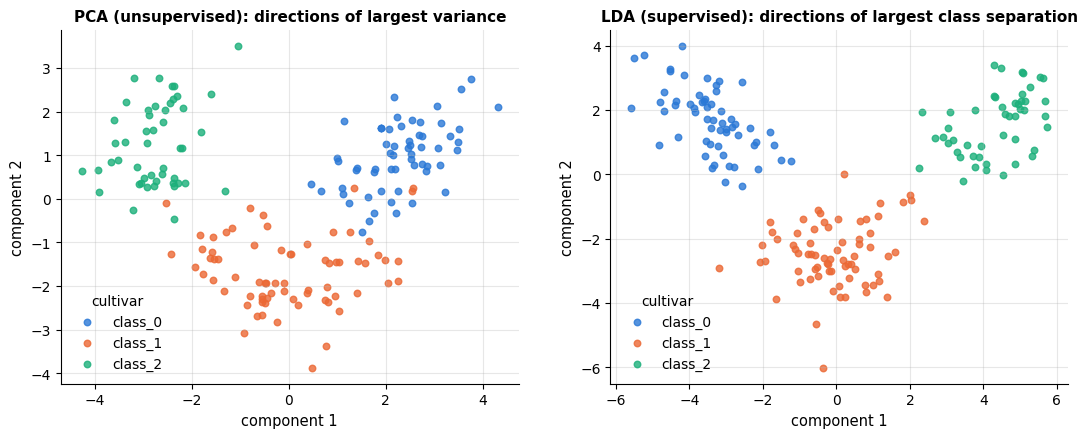

logistic regression on 2 PCA components: CV accuracy 0.961
logistic regression on 2 LDA components: CV accuracy 1.000


In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA needs the labels in fit; n_components can be at most (number of classes - 1) = 2
lda = LinearDiscriminantAnalysis(n_components=2).fit(X_wine_std, y_wine)
Z_pca = pca_std.transform(X_wine_std)       # (178, 2) PCA scores
Z_lda = lda.transform(X_wine_std)           # (178, 2) projection onto the two discriminant directions

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, Z, title in [(axes[0], Z_pca, "PCA (unsupervised): directions of largest variance"),
                     (axes[1], Z_lda, "LDA (supervised): directions of largest class separation")]:
    for c in range(3):
        ax.scatter(Z[y_wine == c, 0], Z[y_wine == c, 1], s=22, alpha=0.8, color=PALETTE[c], label=wine.target_names[c])
    ax.set_xlabel("component 1"); ax.set_ylabel("component 2"); ax.set_title(title, fontsize=11)
    ax.legend(title="cultivar")
plt.show()

for name, Z in [("PCA", Z_pca), ("LDA", Z_lda)]:
    # both projections were fitted on all 178 wines before cross-validation, which flatters LDA (see below)
    acc = cross_val_score(LogisticRegression(max_iter=2000), Z, y_wine, cv=cv).mean()
    print(f"logistic regression on 2 {name} components: CV accuracy {acc:.3f}")

Both pictures separate the cultivars, but LDA's are cleaner: it spends its two dimensions
on exactly what we care about. The comparison is not entirely fair, though — the LDA
projection was fitted on all the data *including the labels of the validation folds*, so
its CV score is optimistic (a leak of the kind discussed in notebook 5). In a real
pipeline LDA, like PCA, belongs *inside* the cross-validated `Pipeline`.

### 3.2 Random projections and the Johnson–Lindenstrauss lemma

Here is a result that sounds too good to be true. Take any $n$ points in $\mathbb{R}^d$
and any tolerance $0 < \varepsilon < 1$. Then a *random* linear map into
$k = O(\varepsilon^{-2}\log n)$ dimensions preserves **all** pairwise Euclidean distances
within a factor $1 \pm \varepsilon$ with high probability (Johnson & Lindenstrauss, 1984).
The target dimension does not depend on $d$ at all, only on $n$ and $\varepsilon$, and
the map costs nothing to "fit": it is a matrix of i.i.d. Gaussians scaled by $1/\sqrt{k}$
(or a sparse ±1 matrix, `SparseRandomProjection`).

Why does it work? For a fixed pair of points with difference $\mathbf{v}$, each projected
coordinate $\mathbf{r}_j^\top\mathbf{v}/\sqrt{k}$ is Gaussian with variance
$\|\mathbf{v}\|^2/k$; the squared projected length is a sum of $k$ such terms, with mean
$\|\mathbf{v}\|^2$ and relative standard deviation $\sqrt{2/k}$. Concentration of measure
plus a union bound over the $\binom{n}{2}$ pairs gives the lemma.

eps = 0.10: JL bound for n = 1000 points needs k >= 5920 dimensions
eps = 0.25: JL bound for n = 1000 points needs k >= 1061 dimensions
eps = 0.50: JL bound for n = 1000 points needs k >= 331 dimensions


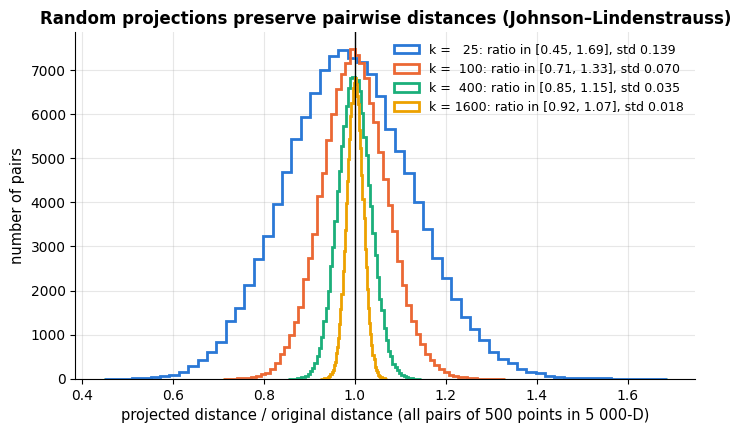

In [13]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim, GaussianRandomProjection
from sklearn.metrics import pairwise_distances

for eps in [0.1, 0.25, 0.5]:
    # johnson_lindenstrauss_min_dim(n_samples, eps): the k at which the JL lemma guarantees distortion within 1 ± eps
    print(f"eps = {eps:.2f}: JL bound for n = 1000 points needs k >= {johnson_lindenstrauss_min_dim(1000, eps=eps)} dimensions")

n_pts, d_high = 500, 5000
# e.g. 500 news articles as standardised word weights over a 5000-word vocabulary
X_high = rng.normal(size=(n_pts, d_high))          # 500 random points in 5000 dimensions
# pairwise_distances(X) is the (n, n) matrix of Euclidean distances; np.triu_indices(n, 1) gives the (row, col)
# indices above the diagonal, so each pair is kept once and the zero self-distances are dropped -> a 1-D array
D_orig = pairwise_distances(X_high)[np.triu_indices(n_pts, 1)]

fig, ax = plt.subplots(figsize=(8, 4.5))
for kk, colour in zip([25, 100, 400, 1600], PALETTE):    # zip stops at the shorter input: 4 values, 4 colours
    # multiplies the data by a random (d, kk) matrix with N(0, 1 / kk) entries; "fitting" only draws that matrix
    proj = GaussianRandomProjection(n_components=kk, random_state=RANDOM_STATE)
    D_proj = pairwise_distances(proj.fit_transform(X_high))[np.triu_indices(n_pts, 1)]   # same pairs, same order
    ratio = D_proj / D_orig                       # 1.0 = distance perfectly preserved
    # histtype="step" draws only the outline, so the four histograms can overlap
    ax.hist(ratio, bins=60, histtype="step", lw=2, color=colour,
            label=f"k = {kk:4d}: ratio in [{ratio.min():.2f}, {ratio.max():.2f}], std {ratio.std():.3f}")
ax.axvline(1, color="black", lw=1)
ax.set_xlabel("projected distance / original distance (all pairs of 500 points in 5 000-D)")
ax.set_ylabel("number of pairs")
ax.set_title("Random projections preserve pairwise distances (Johnson–Lindenstrauss)")
ax.legend(fontsize=9)
plt.show()

The spread of the distance ratios shrinks like $1/\sqrt{k}$, as predicted, and is
independent of the original dimension. Random projections are the tool of choice when
$d$ is enormous (hashing text features, genomic data) and only distances matter — they are
much cheaper than PCA and need no fitting, but unlike PCA they do not remove noise or
reveal structure.

> **Real-life example.** A news aggregator stores every article as word counts over a
> 200 000-word vocabulary and must flag near-duplicates — the same agency story reposted by
> dozens of outlets. One fixed random matrix with a few hundred columns maps each article to a
> few hundred numbers with the distances between articles almost unchanged, so the duplicate
> search runs in the small space and new articles are projected without refitting anything.

### 3.3 Non-negative matrix factorisation: parts and topics

PCA components are signed and dense, and their mixing coefficients can cancel each other:
a face is "the mean face plus 0.7 of component 3 minus 0.4 of component 8". **NMF**
(Lee & Seung, 1999) constrains everything to be non-negative,

$$
\mathbf{X} \;\approx\; \mathbf{W}\mathbf{H}, \qquad \mathbf{W} \in \mathbb{R}_{\ge 0}^{n \times k},\ \mathbf{H} \in \mathbb{R}_{\ge 0}^{k \times d},
\qquad \min_{\mathbf{W}, \mathbf{H} \ge 0}\ \|\mathbf{X} - \mathbf{W}\mathbf{H}\|_F^2 ,
$$

which forces an *additive, parts-based* representation: each row of $\mathbf{H}$ is a
"part" (a facial feature, a group of words that co-occur), and each row of $\mathbf{W}$
says how much of each part a sample contains. The problem is non-convex; Lee & Seung's
multiplicative updates and scikit-learn's default coordinate descent find a local optimum,
so the result depends on the initialisation (`init="nndsvda"` is a deterministic SVD-based
start).

On a **term–document matrix** — rows are documents, columns are words, entries are
(TF-IDF-weighted) counts, all non-negative — the parts are **topics**. Our review corpus
(`load_reviews()`, 2 400 short product reviews about six kinds of products) is a good test
bed because we know the ground truth: each review talks about *one* product, and the
`product` column is available to check the topics (we do not use it to fit them).

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

reviews = load_reviews()                     # one review per row; columns include "product" and "text"
print(reviews[["product", "text"]].head(3).to_string())
print(f"\n{len(reviews)} reviews, products: {sorted(reviews['product'].unique())}")

def show_topics(model, terms, n_words=7):
    """Print the n_words highest-weighted terms of every topic.

    model is a fitted factorisation whose components_ has one row per topic and one column per term;
    terms is the array of vocabulary words in the same column order.
    """
    for j, row in enumerate(model.components_):
        top = terms[np.argsort(row)[::-1][:n_words]]    # positions of the largest weights, largest first -> words
        print(f"  topic {j}: {', '.join(top)}")          # ", ".join(...) glues the words into one string

# first attempt: the whole vocabulary (minus English stop words)
# TfidfVectorizer turns each text into a row of TF-IDF weights, one column per vocabulary word;
# stop_words="english" drops words such as "the" and "and", min_df=3 drops words found in fewer than 3 reviews
tfidf_all = TfidfVectorizer(stop_words="english", min_df=3)
A_all = tfidf_all.fit_transform(reviews["text"])     # learn the vocabulary and build a sparse (reviews, words) matrix
# NMF: factorise A ~ W H with 6 topics; init="nndsvda" is the deterministic SVD-based start, max_iter caps the solver
nmf_all = NMF(n_components=6, init="nndsvda", random_state=RANDOM_STATE, max_iter=500).fit(A_all)
print(f"\nTF-IDF matrix {A_all.shape}, NMF with 6 topics on the full vocabulary:")
show_topics(nmf_all, tfidf_all.get_feature_names_out())   # get_feature_names_out(): the vocabulary in column order

      product                                                                                                      text
0  headphones    I was skeptical but the sound turned out lovely. Five stars for the fantastic sound. Price seems fair.
1  headphones  Not comfortable at all — the fit is dreadful. Nothing about the bass is impressive; it is disappointing.
2      vacuum                                                 Manual is in three languages. Honestly poor noise, avoid.

2400 reviews, products: ['coffee maker', 'headphones', 'laptop', 'novel', 'running shoes', 'vacuum']

TF-IDF matrix (2400, 107), NMF with 6 topics on the full vocabulary:
  topic 0: price, buy, really, love, advertised, works, turned
  topic 1: sadly, feels, honestly, avoid, simply, star, expected
  topic 2: returned, service, customer, bad, disappointing, time, cheap
  topic 3: absolutely, exceeded, expectations, noise, wonderful, reliable, smooth
  topic 4: working, week, stopped, uncomfortable, broken, battery,

These "topics" are not products at all — they are the *review boilerplate* ("returned it,
bad customer service", "absolutely exceeded my expectations", "stopped working after a
week"). NMF found the dominant co-occurrence structure in the counts, and in this corpus
the dominant structure is sentiment phrasing shared by all products. Nothing is wrong with
the algorithm: it answers the question "which groups of words appear together?", not
"which groups of words do *I* find interesting?".

The standard remedy is to remove words that occur in too many documents. In real corpora
`max_df=0.5` is a common choice; here the boilerplate words each appear in about 10 % of
reviews while product-specific words appear in about 5 %, so a threshold of 6 % separates
them. (Look at `tfidf_all.vocabulary_` and the document frequencies yourself before
trusting such a number — it is a corpus-specific decision.)

In [15]:
# max_df=0.06 also drops every word that appears in more than 6 % of the reviews (the shared boilerplate)
tfidf = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.06)
A = tfidf.fit_transform(reviews["text"])
terms = tfidf.get_feature_names_out()
nmf = NMF(n_components=6, init="nndsvda", random_state=RANDOM_STATE, max_iter=500)
W = nmf.fit_transform(A)            # documents x topics
H = nmf.components_                 # topics x words
print(f"vocabulary after max_df filter: {len(terms)} words;  W {W.shape}, H {H.shape}")
show_topics(nmf, terms)

# A.sum(axis=1) on a sparse matrix is an (n, 1) np.matrix; np.asarray(...).ravel() turns it into a flat (n,) array
no_words_left = np.asarray(A.sum(axis=1)).ravel() == 0        # reviews whose every word was filtered out
topic_of_review = np.where(no_words_left, -1, W.argmax(axis=1))   # dominant topic per review, -1 if it is empty
crosstab = pd.crosstab(reviews["product"], topic_of_review)       # counts: product (rows) x dominant topic (columns)
# rename the columns; the conditional expression inside the comprehension labels -1 as "no words left"
crosstab.columns = ["no words left" if j < 0 else f"topic {j}" for j in crosstab.columns]
print(f"\n{no_words_left.sum()} reviews have no vocabulary words left after the filter")
print("product (ground truth, not used) vs. dominant NMF topic:")
crosstab

vocabulary after max_df filter: 32 words;  W (2400, 6), H (6, 32)
  topic 0: comfort, cancelling, sound, fit, bass, support, temperature
  topic 1: temperature, carafe, coffee, cleaning, design, brewing, trackpad
  topic 2: attachments, filter, suction, temperature, writing, support, sizing
  topic 3: keyboard, trackpad, fan, performance, screen, life, temperature
  topic 4: sizing, support, arch, grip, cushioning, durability, bass
  topic 5: writing, plot, characters, pacing, dialogue, ending, sound

163 reviews have no vocabulary words left after the filter
product (ground truth, not used) vs. dominant NMF topic:


,no words left,topic 0,topic 1,topic 2,topic 3,topic 4,topic 5
product,,,,,,,
coffee maker,0,0,426,0,0,0,0
headphones,25,396,0,0,0,0,0
laptop,0,0,0,0,389,0,0
novel,0,0,0,0,0,0,384
running shoes,18,0,0,0,0,345,0
vacuum,120,0,0,297,0,0,0


Now every topic is a product ("keyboard, trackpad, screen, performance, fan" = laptop;
"plot, characters, pacing, dialogue" = novel), and the cross-tabulation shows that the
dominant topic identifies the product for every review that still has words. The
exceptions are instructive: the words that vacuums share with headphones and laptops
(*battery*, *noise*, *weight*) were frequent enough to be removed by the filter, so 120
vacuum reviews that mention nothing else are left with an empty vector and no topic at
all. Topics are about *words*, and a filter that sharpens the topics also throws documents
away — check what your preprocessing discards.

> **History.** Latent semantic analysis (Deerwester et al., 1990) applied the truncated
> SVD to term–document matrices for the same purpose a decade before NMF;
> scikit-learn's `TruncatedSVD` works directly on sparse matrices and is the standard
> "LSA" tool. Its components are signed and harder to read as topics, but as *features* for
> a downstream classifier they are excellent (notebook 15). Probabilistic topic models
> (latent Dirichlet allocation, Blei et al., 2003) are the third option and are also
> covered in notebook 15.

In [16]:
from sklearn.decomposition import TruncatedSVD

# TruncatedSVD keeps the top singular vectors without centring, so it works directly on the sparse matrix (LSA)
lsa = TruncatedSVD(n_components=6, random_state=RANDOM_STATE).fit(A)
print("LSA / truncated SVD on the same matrix — top words by |weight| (signs are arbitrary):")
for j, row in enumerate(lsa.components_[:3]):            # only the first three components
    top = terms[np.argsort(np.abs(row))[::-1][:7]]       # rank the words by |weight|, since the signs are arbitrary
    print(f"  component {j}: {', '.join(top)}")
print(f"variance of the TF-IDF matrix captured by 6 components: {lsa.explained_variance_ratio_.sum():.1%}")

LSA / truncated SVD on the same matrix — top words by |weight| (signs are arbitrary):
  component 0: comfort, cancelling, sound, fit, bass, performance, coffee
  component 1: temperature, carafe, cleaning, coffee, design, brewing, attachments
  component 2: attachments, filter, suction, temperature, design, carafe, coffee
variance of the TF-IDF matrix captured by 6 components: 28.6%


## 4. Matrix factorisation for recommendation

The most commercially successful application of matrix factorisation is **collaborative
filtering** (Koren, Bell & Volinsky, 2009 — the method that won the Netflix Prize). The
data are a ratings matrix $\mathbf{R} \in \mathbb{R}^{n_u \times n_i}$ (users × items) of
which only a small fraction $\mathcal{K}$ of entries is observed. The model assumes that
each user $u$ and each item $i$ have $k$-dimensional *latent factors*
$\mathbf{p}_u, \mathbf{q}_i \in \mathbb{R}^k$ — unobserved "taste" and "genre" coordinates
— plus biases:

$$
\hat r_{ui} \;=\; \mu + b_u + b_i + \mathbf{p}_u^\top\mathbf{q}_i ,
$$

where $\mu$ is the global mean rating, $b_u$ how generous user $u$ is, $b_i$ how well liked
item $i$ is. The parameters are fitted by regularised least squares **over the observed
entries only**:

$$
\min_{\mathbf{P}, \mathbf{Q}, \mathbf{b}}\ \sum_{(u,i) \in \mathcal{K}} \big(r_{ui} - \hat r_{ui}\big)^2
\;+\; \lambda \Big(\sum_u \big(\|\mathbf{p}_u\|^2 + b_u^2\big) + \sum_i \big(\|\mathbf{q}_i\|^2 + b_i^2\big)\Big).
$$

This is *not* an SVD: the SVD needs a complete matrix, and filling the missing 95 % with
zeros or means and then truncating the SVD gives poor recommendations (though it is a
reasonable starting point — try `TruncatedSVD` on the mean-filled matrix in exercise 4).

> **Real-life example.** An online bookshop has two million customers and 300 000 titles, and a
> typical customer has rated about twenty of them, so more than 99.9 % of the matrix is empty.
> A user bias captures the reader who gives everything five stars; the latent factors might
> come out as "literary versus genre fiction" or "fiction versus non-fiction". The "you might
> also like" list is simply the unread titles with the highest predicted rating.

**Two solvers.** The objective is non-convex in $(\mathbf{P}, \mathbf{Q})$ jointly, but
*quadratic in $\mathbf{P}$ when $\mathbf{Q}$ is fixed* and vice versa. Hence

- **Alternating least squares (ALS).** Fix the item factors; then, for each user $u$, the
  best $(b_u, \mathbf{p}_u)$ is the solution of a small ridge regression (notebook 6) of
  the residuals $r_{ui} - \mu - b_i$ on the features $[1, \mathbf{q}_i]$ over the items
  $u$ has rated. Do this for every user, then swap roles and solve for every item. Each
  sweep decreases the objective; a dozen sweeps usually suffice. The per-user problems are
  independent, so ALS parallelises trivially.
- **Stochastic gradient descent (SGD).** Visit the observed ratings in random order and,
  for each, compute the error $e_{ui} = r_{ui} - \hat r_{ui}$ and update
  $\mathbf{p}_u \leftarrow \mathbf{p}_u + \eta\,(e_{ui}\mathbf{q}_i - \lambda\mathbf{p}_u)$,
  $\mathbf{q}_i \leftarrow \mathbf{q}_i + \eta\,(e_{ui}\mathbf{p}_u - \lambda\mathbf{q}_i)$,
  and likewise for the biases. Simpler to write, but it needs a learning rate and, started
  from small random factors, it can sit for many epochs on a plateau near
  $\mathbf{P} = \mathbf{Q} = \mathbf{0}$ (exercise 4 explores this).

We implement ALS. First a synthetic ratings matrix with *known* latent structure — four
true factors, user and item biases, Gaussian noise, ratings clipped to 1–5, and only 10 %
of the entries observed.

In [17]:
n_users, n_items, true_rank = 500, 300, 4      # e.g. readers, books and taste dimensions of a bookshop
P_true = rng.normal(0, 1, (n_users, true_rank))      # true user factors, (500, 4)
Q_true = rng.normal(0, 1, (n_items, true_rank))      # true item factors, (300, 4)
bu_true, bi_true, mu_true = rng.normal(0, 0.4, n_users), rng.normal(0, 0.4, n_items), 3.5
# the full (500, 300) ratings matrix: (500, 1) + (1, 300) broadcasts the biases, P Q^T holds every user-item dot
# product (divided by sqrt(rank) to keep its variance near 1), plus noise with standard deviation 0.5
R_full = (mu_true + bu_true[:, None] + bi_true[None, :] + P_true @ Q_true.T / np.sqrt(true_rank)
          + rng.normal(0, 0.5, (n_users, n_items)))

observed = rng.random((n_users, n_items)) < 0.10                 # which ratings we get to see
users, items = np.nonzero(observed)          # row and column indices of the True entries: one (user, item) per rating
ratings = np.clip(R_full[users, items], 1, 5)    # R_full[users[j], items[j]] for every j, clipped to the 1-5 scale
perm = rng.permutation(len(ratings))         # the rating positions in random order
n_test = len(ratings) // 5                   # 20 % held out (// is integer division)
test_idx, train_idx = perm[:n_test], perm[n_test:]
u_tr, i_tr, r_tr = users[train_idx], items[train_idx], ratings[train_idx]   # parallel arrays: user, item, rating
u_te, i_te, r_te = users[test_idx], items[test_idx], ratings[test_idx]
print(f"{n_users} users x {n_items} items, {observed.mean():.1%} observed -> {len(r_tr)} training and {len(r_te)} test ratings")
# np.bincount(u_tr, minlength=n_users) counts the training ratings of every user (0 for users without any)
print(f"ratings per user: median {np.median(np.bincount(u_tr, minlength=n_users)):.0f}; mean rating {r_tr.mean():.2f}")

500 users x 300 items, 10.1% observed -> 12116 training and 3029 test ratings
ratings per user: median 24; mean rating 3.40


Baselines first (notebook 5): predicting the global mean, and the bias-only model
($k = 0$), which is what our ALS implementation reduces to when `n_factors=0`.

In [18]:
def rmse(pred, truth):
    """Root-mean-squared error between predictions and true values (a scalar pred is broadcast)."""
    return np.sqrt(np.mean((pred - truth) ** 2))

def predict(mu, bu, bi, P, Q, u, i):
    """Predicted ratings mu + b_u + b_i + p_u . q_i for parallel arrays of user indices u and item indices i.

    P[u] and Q[i] are (m, k), one factor row per rating, so the row-wise dot product is a sum over axis 1.
    Returns an array of m predictions.
    """
    return mu + bu[u] + bi[i] + np.sum(P[u] * Q[i], axis=1)

def fit_als(u_tr, i_tr, r_tr, n_users, n_items, n_factors=4, reg=2.0, n_sweeps=15, eval_sets=(), seed=RANDOM_STATE):
    """Biased matrix factorisation r_ui ~ mu + b_u + b_i + p_u . q_i, fitted by alternating least squares.

    u_tr, i_tr, r_tr   parallel arrays of training ratings: user index, item index, rating
    n_factors          number of latent factors k (0 gives the bias-only model)
    reg                ridge penalty lambda on the factors and the biases
    n_sweeps           number of passes; each solves every user, then every item
    eval_sets          (u, i, r) triples on which the RMSE is recorded after every sweep
    Returns ((mu, bu, bi, P, Q), history), where history has shape (n_sweeps, len(eval_sets)).
    """
    g = np.random.default_rng(seed)          # its own generator, so the initial factors are reproducible
    mu = r_tr.mean()                         # global mean rating, kept fixed
    bu, bi = np.zeros(n_users), np.zeros(n_items)
    P, Q = g.normal(0, 0.1, (n_users, n_factors)), g.normal(0, 0.1, (n_items, n_factors))   # small random start
    by_user = [np.flatnonzero(u_tr == u) for u in range(n_users)]   # indices of the ratings of each user
    by_item = [np.flatnonzero(i_tr == i) for i in range(n_items)]
    ridge = reg * np.eye(n_factors + 1)      # lambda * I for the k + 1 unknowns (bias + k factors)
    history = []
    for sweep in range(n_sweeps):
        for u in range(n_users):                     # user step: ridge regression on [1, q_i] for the items u rated
            idx = by_user[u]
            if len(idx) == 0:
                continue                             # no training ratings: keep the initial values
            A = np.column_stack([np.ones(len(idx)), Q[i_tr[idx]]])     # (m, 1 + k): ones, then item factors
            target = r_tr[idx] - mu - bi[i_tr[idx]]                    # rating minus global mean and item bias
            w = np.linalg.solve(A.T @ A + ridge, A.T @ target)         # solve (A^T A + lambda I) w = A^T y (ridge)
            bu[u], P[u] = w[0], w[1:]                                  # first weight = user bias, the rest = factors
        for i in range(n_items):                     # item step: ridge regression on [1, p_u] for the users who rated i
            idx = by_item[i]
            if len(idx) == 0:
                continue
            A = np.column_stack([np.ones(len(idx)), P[u_tr[idx]]])
            target = r_tr[idx] - mu - bu[u_tr[idx]]
            w = np.linalg.solve(A.T @ A + ridge, A.T @ target)
            bi[i], Q[i] = w[0], w[1:]
        # one RMSE per evaluation set after this sweep; (u, i, r) unpacks each triple
        history.append([rmse(predict(mu, bu, bi, P, Q, u, i), r) for (u, i, r) in eval_sets])
    return (mu, bu, bi, P, Q), np.array(history)

eval_sets = [(u_tr, i_tr, r_tr), (u_te, i_te, r_te)]      # history column 0 = training RMSE, column 1 = test RMSE
print(f"baseline  global mean         test RMSE {rmse(r_tr.mean(), r_te):.3f}")   # predict the mean for every rating
_, hist0 = fit_als(u_tr, i_tr, r_tr, n_users, n_items, n_factors=0, eval_sets=eval_sets)   # _ discards the parameters
print(f"baseline  biases only (k = 0) test RMSE {hist0[-1, 1]:.3f}")    # [-1, 1]: last sweep, test set
params, hist4 = fit_als(u_tr, i_tr, r_tr, n_users, n_items, n_factors=4, eval_sets=eval_sets)
print(f"ALS with k = 4 factors:       train RMSE {hist4[-1, 0]:.3f}, test RMSE {hist4[-1, 1]:.3f}")

baseline  global mean         test RMSE 1.079
baseline  biases only (k = 0) test RMSE 0.991
ALS with k = 4 factors:       train RMSE 0.420, test RMSE 0.593


oracle (true factors, no noise) test RMSE: 0.460  <- the noise floor


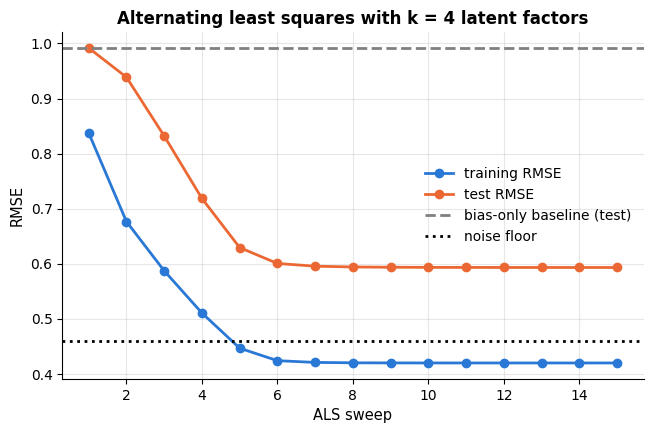

In [19]:
# The best achievable test RMSE: the true model (without the noise) predicting the noisy ratings.
oracle = np.clip(mu_true + bu_true[u_te] + bi_true[i_te] + np.sum(P_true[u_te] * Q_true[i_te], axis=1) / np.sqrt(true_rank), 1, 5)
noise_floor = rmse(oracle, r_te)
print(f"oracle (true factors, no noise) test RMSE: {noise_floor:.3f}  <- the noise floor")

fig, ax = plt.subplots()
# hist4[:, 0] = training RMSE after each sweep, hist4[:, 1] = test RMSE
ax.plot(np.arange(1, len(hist4) + 1), hist4[:, 0], marker="o", label="training RMSE")
ax.plot(np.arange(1, len(hist4) + 1), hist4[:, 1], marker="o", label="test RMSE")
ax.axhline(hist0[-1, 1], color="gray", ls="--", label="bias-only baseline (test)")
ax.axhline(noise_floor, color="black", ls=":", label="noise floor")
ax.set_xlabel("ALS sweep")
ax.set_ylabel("RMSE")
ax.set_title("Alternating least squares with k = 4 latent factors")
ax.legend()
plt.show()

ALS converges in a handful of sweeps: the test RMSE drops from about 0.99 (biases only)
to about 0.58, not far above the noise floor of 0.45 that even the true factors cannot
beat.
(The remaining gap is estimation error: with 24 ratings per user, the factors are
inevitably imprecise.) How many factors should we use if we did not know the truth? Exactly as for every other hyper-parameter:
by held-out error.

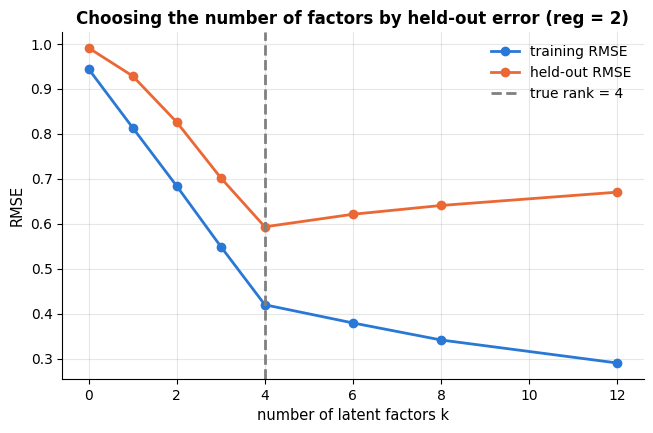

best k by held-out RMSE: 4 (test RMSE 0.593); k = 12: 0.670


In [20]:
factor_grid = [0, 1, 2, 3, 4, 6, 8, 12]
train_rmse, test_rmse = [], []
for kk in factor_grid:
    _, h = fit_als(u_tr, i_tr, r_tr, n_users, n_items, n_factors=kk, eval_sets=eval_sets)
    train_rmse.append(h[-1, 0]); test_rmse.append(h[-1, 1])     # training and test RMSE after the last sweep

fig, ax = plt.subplots()
ax.plot(factor_grid, train_rmse, marker="o", label="training RMSE")
ax.plot(factor_grid, test_rmse, marker="o", label="held-out RMSE")
ax.axvline(true_rank, color="gray", ls="--", label=f"true rank = {true_rank}")
ax.set_xlabel("number of latent factors k")
ax.set_ylabel("RMSE")
ax.set_title("Choosing the number of factors by held-out error (reg = 2)")
ax.legend()
plt.show()
best_k = factor_grid[int(np.argmin(test_rmse))]      # the k with the lowest held-out RMSE
print(f"best k by held-out RMSE: {best_k} (test RMSE {min(test_rmse):.3f}); k = 12: {test_rmse[-1]:.3f}")

Training error falls monotonically with $k$ while held-out error is U-shaped with its
minimum at the true rank — the bias–variance trade-off of notebook 5 in a new costume.
Beyond the true rank the extra factors fit noise in the sparse observations; a larger
`reg` flattens the right side of the U (exercise 4). In practice, with millions of ratings
and no known rank, $k$ between 20 and 200 and $\lambda$ are tuned on a validation split,
and the same model is extended with implicit feedback, time effects and side information
(Koren et al., 2009).

## 5. Non-linear manifold learning

Linear methods cannot unroll a curved manifold. The **swiss roll** — a 2-D sheet rolled
up in 3-D — is the standard example. The sheet is intrinsically two-dimensional, yet no
linear projection to 2-D unrolls it: PCA shows the spiral seen from the side, with points
from different turns of the roll (different colours) next to each other, and any other
projection superimposes the layers.

> **Real-life example.** A warehouse robot logs the signal strengths of 40 Wi-Fi access points
> at thousands of spots. Each log is a point in 40 dimensions but is essentially fixed by two
> numbers, the robot's position, so the logs lie on a curved 2-D sheet (signal strength falls off
> non-linearly with distance). A flat projection can lay distant aisles on top of each other; a
> method that follows chains of similar neighbouring logs can recover a map of the floor.

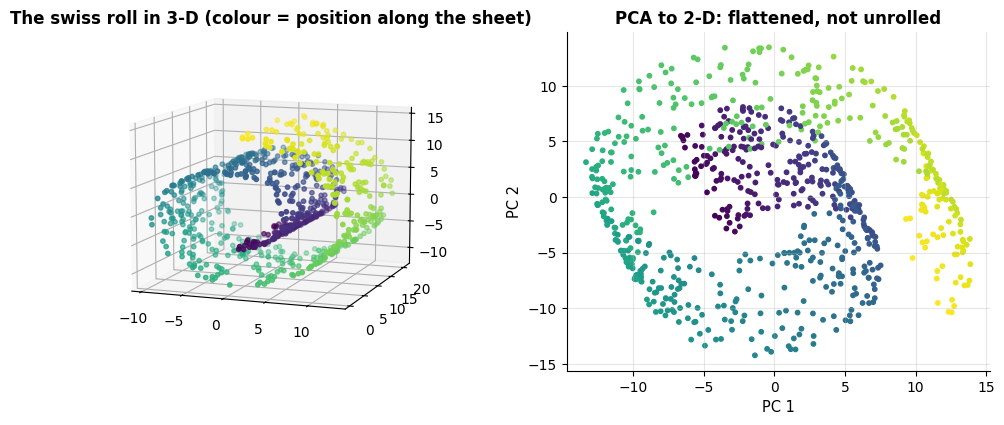

In [21]:
from sklearn.datasets import make_swiss_roll

# X_roll is (800, 3); noise = standard deviation of the Gaussian noise added to every point
# e.g. the signal strengths of 3 access points, a curved function of a robot's 2-D position on the floor
X_roll, t_roll = make_swiss_roll(n_samples=800, noise=0.05, random_state=RANDOM_STATE)  # t = position along the roll
fig = plt.figure(figsize=(12, 4.4))
ax3 = fig.add_subplot(1, 2, 1, projection="3d")      # left panel of a 1 x 2 grid, with 3-D axes
ax3.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=t_roll, cmap="viridis", s=10)   # c: one colour value per point
ax3.set_title("The swiss roll in 3-D (colour = position along the sheet)")
ax3.view_init(elev=10, azim=-70)                     # camera angles in degrees: elevation and azimuth
ax2 = fig.add_subplot(1, 2, 2)
Z_roll_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_roll)
ax2.scatter(Z_roll_pca[:, 0], Z_roll_pca[:, 1], c=t_roll, cmap="viridis", s=10)
ax2.set_title("PCA to 2-D: flattened, not unrolled")
ax2.set_xlabel("PC 1"); ax2.set_ylabel("PC 2")
plt.show()

### 5.1 Kernel PCA, Isomap and LLE

| Method | Idea | Preserves | Key hyper-parameters | Cost |
|---|---|---|---|---|
| **Kernel PCA** (Schölkopf, Smola & Müller, 1998) | PCA in the feature space of a kernel (notebook 11): eigen-decompose the centred $n \times n$ kernel matrix | whatever the kernel measures; with an RBF kernel, local similarity | kernel, `gamma` | $O(n^2)$ memory, $O(n^3)$ time |
| **Isomap** (Tenenbaum, de Silva & Langford, 2000) | build a $k$-nearest-neighbour graph, compute *geodesic* distances as shortest paths, then classical multidimensional scaling | global geodesic distances along the manifold | `n_neighbors` | $O(n^2 \log n)$ shortest paths |
| **LLE** (Roweis & Saul, 2000) | express each point as a linear combination of its neighbours, then find low-dimensional coordinates reproducing the same weights | local linear geometry | `n_neighbors`, `reg` | sparse eigenproblem, fast |

Kernel PCA is the easiest to understand: it is exactly section 2 applied after a
non-linear feature map $\phi$, computed implicitly through $K_{ij} = \phi(\mathbf{x}_i)^\top\phi(\mathbf{x}_j)$.
A two-class example that no linear projection can separate — concentric circles — becomes
linearly separable after an RBF kernel PCA:

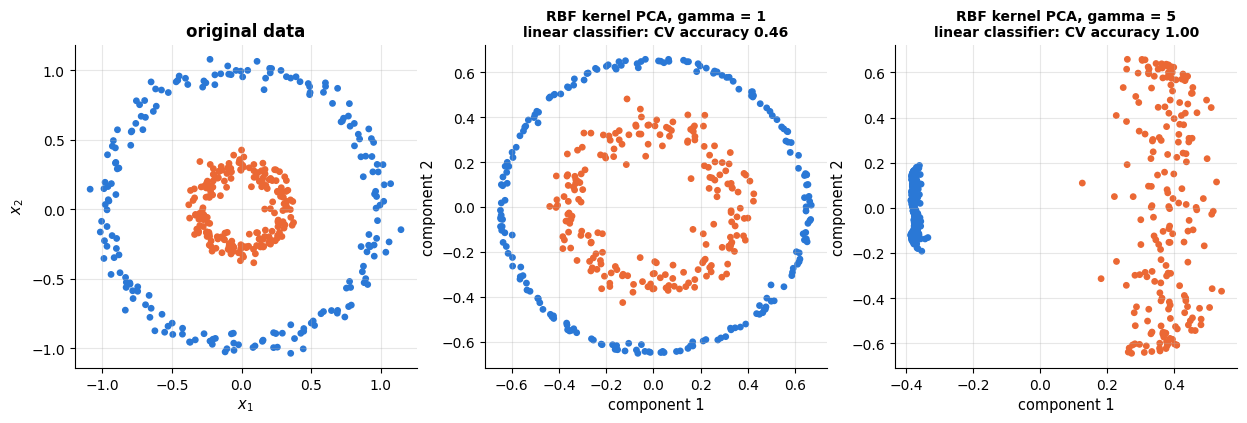

In [22]:
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA

# two concentric circles (class 0 outer, class 1 inner); factor = inner radius / outer radius
# e.g. x1, x2 = a patient's deviation from normal temperature and heart rate; inner = well, outer = unwell
X_circ, y_circ = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].scatter(X_circ[:, 0], X_circ[:, 1], c=[PALETTE[c] for c in y_circ], s=15)   # one colour per point, by class
axes[0].set_title("original data"); axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")
for ax, gamma in zip(axes[1:], [1, 5]):          # panels 1 and 2: two kernel widths
    # kernel PCA with the RBF kernel K(x, x') = exp(-gamma * ||x - x'||^2), i.e. PCA in that kernel's feature space
    Z = KernelPCA(n_components=2, kernel="rbf", gamma=gamma).fit_transform(X_circ)
    acc = cross_val_score(LogisticRegression(), Z, y_circ, cv=cv).mean()   # can a linear model separate them now?
    ax.scatter(Z[:, 0], Z[:, 1], c=[PALETTE[c] for c in y_circ], s=15)
    ax.set_title(f"RBF kernel PCA, gamma = {gamma}\nlinear classifier: CV accuracy {acc:.2f}", fontsize=10)
    ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
plt.show()

As always with kernels, `gamma` matters: too small and the kernel is nearly linear
(nothing gained), too large and every point is only similar to itself.

> **Real-life example.** Think of the two coordinates as a patient's deviation from normal body
> temperature and from normal heart rate. Patients near the centre are well; patients far out
> in *any* direction — fever or hypothermia, a racing or a very slow pulse — need attention. No
> straight line separates the centre from the ring around it; after an RBF kernel PCA, one does.

### 5.2 t-SNE: how it works

**t-distributed stochastic neighbour embedding** (van der Maaten & Hinton, 2008) is the
most popular tool for 2-D maps of high-dimensional data. It preserves *neighbourhoods*,
not distances, and it does so through probabilities:

1. In the original space, define for each point $i$ a distribution over its potential
   neighbours,
   $$p_{j \mid i} = \frac{\exp\!\big(-\|\mathbf{x}_i - \mathbf{x}_j\|^2 / 2\sigma_i^2\big)}{\sum_{l \ne i}\exp\!\big(-\|\mathbf{x}_i - \mathbf{x}_l\|^2 / 2\sigma_i^2\big)},$$
   and symmetrise: $p_{ij} = (p_{j \mid i} + p_{i \mid j}) / 2n$. The bandwidth
   $\sigma_i$ is chosen *per point* by binary search so that the distribution
   $p_{\cdot \mid i}$ has a prescribed **perplexity**
   $\operatorname{Perp} = 2^{H(p_{\cdot\mid i})}$, where $H$ is the entropy in bits — the
   perplexity is a smooth "effective number of neighbours", typically set between 5
   and 50.
2. In the 2-D map with coordinates $\mathbf{y}_i$, define the analogous distribution with
   a **Student-$t$ kernel** (one degree of freedom, i.e. a Cauchy kernel):
   $$q_{ij} = \frac{(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}}{\sum_{k \ne l}(1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2)^{-1}} .$$
   Its heavy tail is the crucial trick: moderately distant points in high dimensions can be
   placed *far* apart in the map without penalty, which relieves the "crowding" that plagued
   the earlier Gaussian SNE and produces the well-separated clusters t-SNE is known for.
3. Minimise the Kullback–Leibler divergence (notebook 2)
   $\operatorname{KL}(P \,\|\, Q) = \sum_{i \ne j} p_{ij}\log\frac{p_{ij}}{q_{ij}}$ over the
   $\mathbf{y}_i$ by gradient descent with momentum, starting (in scikit-learn's default)
   from the PCA projection, with an "early exaggeration" phase that multiplies the $p_{ij}$
   to let clusters form.

The KL divergence is asymmetric: a large $p_{ij}$ (true neighbours) mapped to a small
$q_{ij}$ (far apart) is heavily penalised, whereas non-neighbours placed close together
cost little. This is why t-SNE is faithful *locally* and unreliable *globally*. Exact
t-SNE costs $O(n^2)$ per iteration; the Barnes–Hut approximation used by scikit-learn
(`method="barnes_hut"`) brings that to $O(n \log n)$, but a run on tens of thousands of
points still takes minutes. Note also that t-SNE has no `transform` for new points — it is
a visualisation, not a feature map.

Let us run it on a subsample of the digits with several perplexities.

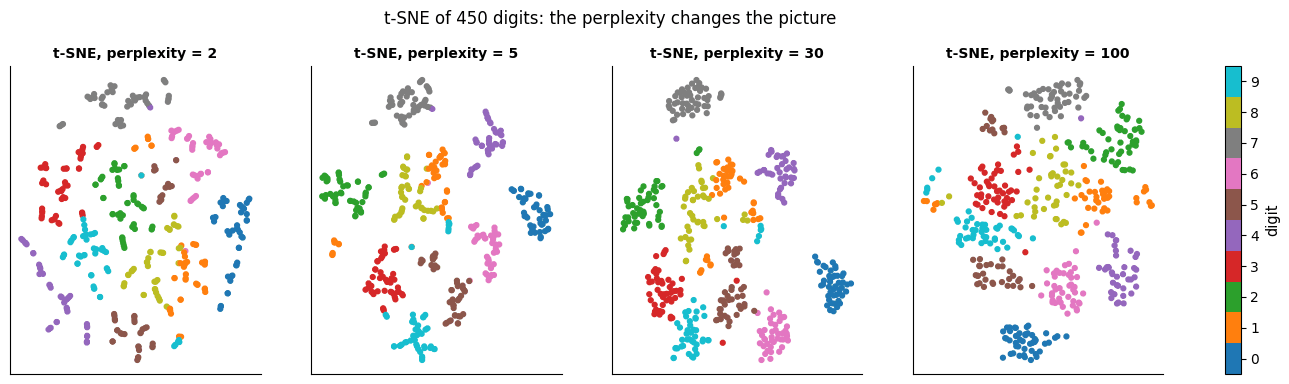

In [23]:
from sklearn.manifold import TSNE, trustworthiness

sub = rng.choice(n, size=450, replace=False)                 # 450 digits keep every t-SNE run to a few seconds
X_sub, y_sub = X_digits[sub], y_digits[sub]

def scatter_by_class(ax, Z, labels, title):
    """Scatter the 2-D embedding Z on ax, coloured by the digit labels 0-9, without ticks or grid.

    Returns the scatter object, so that a colour bar can be attached to it.
    """
    # tab10 has 10 distinct colours; vmin=-0.5, vmax=9.5 give each integer label its own colour
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=12, vmin=-0.5, vmax=9.5)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    return sc

perplexities = [2, 5, 30, 100]
tsne_runs = {}                     # keep each embedding and its diagnostics; reused by the tuning guide (section 9.4)
fig, axes = plt.subplots(1, len(perplexities), figsize=(16, 4))
for ax, perp in zip(axes, perplexities):
    # perplexity = effective number of neighbours; init="pca" starts from the PCA layout;
    # max_iter = number of gradient-descent iterations
    ts = TSNE(n_components=2, perplexity=perp, init="pca", max_iter=500, random_state=RANDOM_STATE)
    Z = ts.fit_transform(X_sub)                  # (450, 2) map coordinates (t-SNE has no separate transform)
    # kl_divergence_: the final value of the objective; trustworthiness (0 to 1) penalises points that are among
    # a point's 12 nearest neighbours in the map but not in the original space
    tsne_runs[perp] = (Z, ts.kl_divergence_, trustworthiness(X_sub, Z, n_neighbors=12))
    sc = scatter_by_class(ax, Z, y_sub, f"t-SNE, perplexity = {perp}")
# one colour bar for all panels (ax=axes); fraction = how much space it takes from them
fig.colorbar(sc, ax=axes, ticks=range(10), label="digit", fraction=0.02)
fig.suptitle(f"t-SNE of {len(X_sub)} digits: the perplexity changes the picture", y=1.02)
plt.show()

With perplexity 2 the map fragments into many small clumps (each point only "sees" two
neighbours); with 5–30 the ten digit classes appear as separate islands; with 100 (a
sixth of the data) the picture blurs towards something closer to PCA. Note that the
*labels* were never used — t-SNE found the classes from pixel similarity alone, which is
why it is such a popular exploratory tool.

> **Real-life example.** A cancer-research lab measures the activity of about 20 000 genes in
> each of 10 000 single cells from a tumour biopsy. A t-SNE map of the cells shows islands, and
> the biologists name each island a cell type (T cells, B cells, tumour cells, …) from the
> marker genes active in it — without any labels, just as the digit classes appeared above.
> Single-cell biology uses t-SNE and UMAP maps in this way every day.

### 5.3 How *not* to read a t-SNE plot

Wattenberg, Viégas & Johnson (2016) catalogued the misreadings that t-SNE invites. Three
of them can be demonstrated with tiny synthetic datasets whose truth we know.

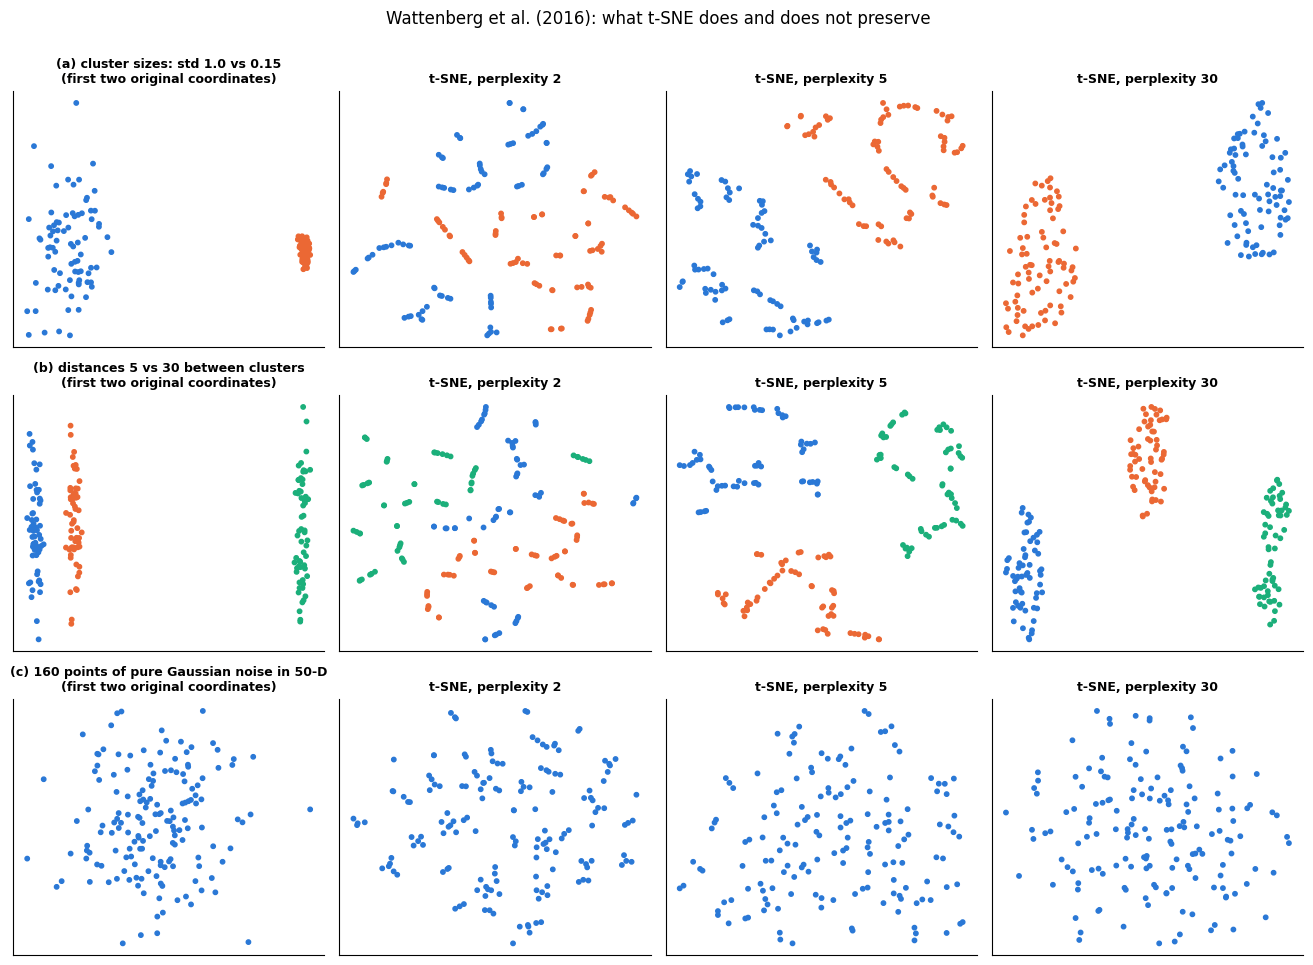

In [24]:
def tsne_gallery(datasets, perplexities, title):
    """Plot a grid with one row per dataset: the data in column 0, then one t-SNE map per perplexity.

    datasets is a dict name -> (X, labels) (column 0 shows the first two coordinates of X);
    perplexities is a list of perplexity values, one column each; title goes above the whole figure.
    """
    fig, axes = plt.subplots(len(datasets), len(perplexities) + 1, figsize=(3.3 * (len(perplexities) + 1), 3.2 * len(datasets)))
    for r, (name, (Xd, cd)) in enumerate(datasets.items()):     # nested unpacking of (name, (data, labels))
        axes[r, 0].scatter(Xd[:, 0], Xd[:, 1], c=[PALETTE[c] for c in cd], s=10)
        axes[r, 0].set_title(f"{name}\n(first two original coordinates)", fontsize=9)
        for c, perp in enumerate(perplexities, start=1):
            Z = TSNE(n_components=2, perplexity=perp, init="pca", max_iter=400, random_state=RANDOM_STATE).fit_transform(Xd)
            axes[r, c].scatter(Z[:, 0], Z[:, 1], c=[PALETTE[k] for k in cd], s=10)
            axes[r, c].set_title(f"t-SNE, perplexity {perp}", fontsize=9)
    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    fig.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.show()

# (a) two clusters with very different spreads; (b) three clusters at distances 5 and 30; (c) pure 50-D noise
# e.g. (a) parts from a precise and a sloppy machine, (b) two related species and a distant one, (c) noise
# np.r_[a, b] stacks arrays along the first axis; rng.normal([12, 0], 0.15, ...) is centred at x = 12, y = 0
X_a = np.r_[rng.normal(0, 1.0, (80, 2)), rng.normal([12, 0], 0.15, (80, 2))]
c_a = np.r_[np.zeros(80, int), np.ones(80, int)]          # labels: 80 zeros, then 80 ones
X_b = np.r_[rng.normal([0, 0], 0.5, (60, 2)), rng.normal([5, 0], 0.5, (60, 2)), rng.normal([35, 0], 0.5, (60, 2))]
c_b = np.repeat([0, 1, 2], 60)                            # 60 zeros, 60 ones, 60 twos
X_c = rng.normal(size=(160, 50))
c_c = np.zeros(160, int)                                  # a single "class"
tsne_gallery({"(a) cluster sizes: std 1.0 vs 0.15": (X_a, c_a),
              "(b) distances 5 vs 30 between clusters": (X_b, c_b),
              "(c) 160 points of pure Gaussian noise in 50-D": (X_c, c_c)},
             perplexities=[2, 5, 30], title="Wattenberg et al. (2016): what t-SNE does and does not preserve")

- **(a) Cluster sizes mean nothing.** The tight cluster and the diffuse cluster come out
  the same size: t-SNE equalises densities because each point's bandwidth $\sigma_i$
  adapts to its own neighbourhood.
- **(b) Distances between clusters may mean nothing.** The cluster that is six times
  farther away is not six times farther in the map; at some perplexities the three
  clusters are equidistant. Global geometry is not what the objective rewards.
- **(c) Random noise does not look random.** At low perplexity, structureless Gaussian
  noise produces convincing "clusters". If you see clusters, check that they survive a
  change of perplexity and of random seed — and ideally that they mean something
  downstream.

> **Real-life example.** A marketing analyst runs t-SNE on the purchase histories of 50 000
> shoppers and finds one compact island far from the rest. "A very homogeneous segment, very
> different from everyone else" is the tempting report — but compactness and distance are
> exactly what the map does not preserve, so both must be checked in the original features
> before anyone builds a campaign around that segment.

To these add: the perplexity must be smaller than the number of points (and the
picture depends on it — always try several); the number of iterations must be enough for
the layout to stabilise; and *different runs give different pictures* (the objective is
non-convex), so never compare two t-SNE maps by their coordinates.

> **Warning.** Never cluster on t-SNE coordinates and report the result as "the clusters
> in the data" without further checks. The map exaggerates separations, invents
> structure in noise at low perplexity, and can tear one continuous manifold into pieces.
> Use it to *generate* hypotheses; test them in the original space (silhouette scores,
> stability across seeds, downstream accuracy — notebook 13).

### 5.4 UMAP (optional) and a gallery

**UMAP** (McInnes, Healy & Melville, 2018) starts from a similar idea — a fuzzy
neighbourhood graph in the original space, a low-dimensional layout that matches it — but
uses a cross-entropy objective with attractive *and* repulsive terms derived from a
topological (fuzzy simplicial set) construction. In practice UMAP is several times faster
than t-SNE, scales to millions of points, has a `transform` for new data, and tends to keep
more of the global arrangement of clusters; its knobs are `n_neighbors` (the analogue of
perplexity) and `min_dist` (how tightly points may pack). All of the t-SNE caveats apply to
UMAP too. The package `umap-learn` is not part of scikit-learn, so this section runs only
if it is installed.

umap-learn is not installed — skipping the UMAP panels (conda install -c conda-forge umap-learn).


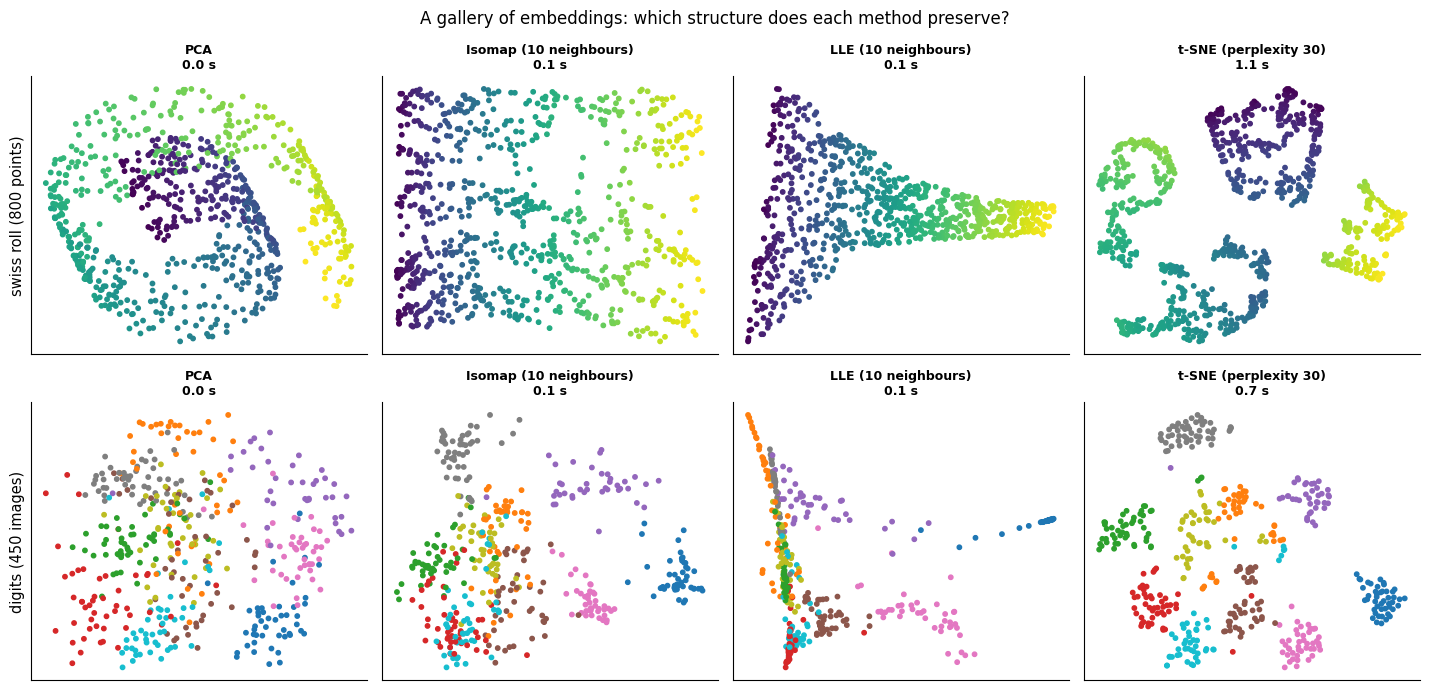

In [25]:
try:
    import umap                       # the optional umap-learn package
    HAS_UMAP = True
except ImportError:                   # raised when the package is not installed
    HAS_UMAP = False
    print("umap-learn is not installed — skipping the UMAP panels (conda install -c conda-forge umap-learn).")

from sklearn.manifold import Isomap, LocallyLinearEmbedding

# name -> unfitted estimator, each with fit_transform(X) -> (n, 2). Isomap: geodesic distances on a 10-nearest-
# neighbour graph; LLE: reconstruct each point from its 10 neighbours (random_state seeds its eigen-solver)
methods = {
    "PCA": PCA(n_components=2, random_state=RANDOM_STATE),
    "Isomap (10 neighbours)": Isomap(n_neighbors=10, n_components=2),
    "LLE (10 neighbours)": LocallyLinearEmbedding(n_neighbors=10, n_components=2, random_state=RANDOM_STATE),
    "t-SNE (perplexity 30)": TSNE(n_components=2, perplexity=30, init="pca", max_iter=500, random_state=RANDOM_STATE),
}
if HAS_UMAP:
    methods["UMAP (15 neighbours)"] = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, len(methods), figsize=(3.6 * len(methods), 7))   # row 0: swiss roll, row 1: digits
for c, (name, method) in enumerate(methods.items()):
    for r, (Xd, colour, cmap) in enumerate([(X_roll, t_roll, "viridis"), (X_sub, y_sub, "tab10")]):
        t0 = time.perf_counter()
        Z = method.fit_transform(Xd)          # refits the same estimator on each dataset
        axes[r, c].scatter(Z[:, 0], Z[:, 1], c=colour, cmap=cmap, s=10)
        axes[r, c].set_title(f"{name}\n{time.perf_counter() - t0:.1f} s", fontsize=9)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([]); axes[r, c].grid(False)
axes[0, 0].set_ylabel(f"swiss roll ({len(X_roll)} points)")
axes[1, 0].set_ylabel(f"digits ({len(X_sub)} images)")
fig.suptitle("A gallery of embeddings: which structure does each method preserve?")
plt.tight_layout()
plt.show()

Isomap unrolls the swiss roll almost perfectly because its geodesic distances follow the
sheet; LLE unrolls it too but distorts the proportions; t-SNE squeezes the continuous
sheet into a twisted ribbon — the local order along the roll survives, the shape of the
sheet does not, and a manifold without clusters is exactly the case where t-SNE misleads.
On the digits, which *do* form clusters, t-SNE gives the crispest picture, Isomap a
smoother and more global one, and standard LLE collapses most classes into a few spikes
(a known weakness of the basic algorithm; `method="modified"` is more robust). The
gallery is the practical summary of this section: **the method must match the structure
you expect**, and a method that beautifies clustered data may misrepresent continuous
data.

## 6. Autoencoders: non-linear PCA (concept)

An **autoencoder** is a neural network trained to reproduce its input through a narrow
bottleneck: an encoder $\mathbf{z} = f_{\text{enc}}(\mathbf{x}) \in \mathbb{R}^k$, a decoder
$\hat{\mathbf{x}} = f_{\text{dec}}(\mathbf{z})$, and the reconstruction loss
$\sum_i \|\mathbf{x}_i - \hat{\mathbf{x}}_i\|^2$ — precisely PCA's objective from section
2.1. If encoder and decoder are *linear*, the optimum spans the principal subspace (Baldi &
Hornik, 1989); with non-linear layers the network can learn a curved manifold, and with a
probabilistic bottleneck it becomes the variational autoencoder (Kingma & Welling, 2014),
a generative model. Autoencoders belong to a deep-learning course; their linear special case is exactly the PCA of section 2. The lesson to carry over is that *reconstruction error is the
common currency* of PCA, NMF, matrix-factorisation recommenders and autoencoders — they
differ in the constraints placed on the encoder and decoder.

> **Real-life example.** A card issuer trains an autoencoder on millions of normal transactions
> (amount, merchant category, time of day, distance from home, …). Typical transactions pass
> through the bottleneck almost unchanged; an unusual one is reconstructed badly, and a large
> reconstruction error sends it to a fraud analyst — PCA-style anomaly detection with a curved
> instead of a flat "normal" surface.

## 7. Using dimensionality reduction responsibly

1. **Decide what the reduction is for.** For *visualisation*, any method that makes the
   structure you care about visible is fine, provided you read it with the caveats of
   section 5.3. For *features* feeding a model, the reduction is a preprocessing step:
   put it in the `Pipeline`, fit it on training folds only, and choose $k$ by
   cross-validation on the downstream metric (section 2.6). Methods without a `transform`
   (t-SNE) cannot play this role.
2. **Scale first** (section 2.5), unless features share a unit.
3. **Prefer the simplest method that works.** PCA is fast, deterministic, invertible and
   has no hyper-parameters except $k$; try it before anything non-linear. Random
   projections when $d$ is huge; NMF when non-negativity and interpretability matter;
   LDA when you have labels and want separation.
4. **Check stability.** Re-run non-convex methods (NMF, t-SNE, UMAP, ALS) with different
   seeds and hyper-parameters; structure that comes and goes is not structure.
5. **Evaluate downstream.** Explained variance and KL divergence are proxies. The real
   question is whether the reduced representation clusters, classifies or recommends
   better — measure that, with held-out data.
6. **Beware of the survivorship of pretty pictures.** A 2-D map that "shows" groups is
   persuasive; ask what would have to be true in the original space for those groups to be
   real, and test it.

## 8. Strengths, weaknesses and when to use each method

Sections 2–6 introduced five families: PCA and its linear relatives, NMF, latent-factor
matrix factorisation, and the neighbourhood embeddings t-SNE and UMAP. This section states
plainly what each is good for, what it cannot do, and — for the two methods that are most
often misused — *shows* the failure on data whose truth we control. A method's weakness is
never a reason not to use it; it is the reason to check whether your data trip it up.

### 8.1 Demonstrated failure — PCA: variance is not relevance

PCA ranks directions by variance, and variance is a property of the *inputs* alone. Nothing
in the objective knows that one direction happens to separate your classes. When the
discriminative direction is a *low*-variance one, PCA discards it first, and the "cleaned
up" representation is worse than the raw features.

> **Real-life example.** A bottling plant photographs every bottle on the line to catch hairline
> cracks. Across the images, most of the pixel variance comes from lighting, the bottle's exact
> position and the printed label; a crack changes a few pixels by a little. PCA keeps the
> lighting and position directions and ranks the crack direction near the very end — compress
> to the "top" components and the defect is gone.

The construction is deliberately extreme so that the effect is unmistakable. We build
$n = 600$ points in $\mathbb{R}^{10}$:

- one direction carries the class signal, with class means at $\pm 0.6$ and within-class
  standard deviation $0.35$ — total standard deviation about $0.69$;
- the other nine directions are pure Gaussian noise with standard deviation $3.0$ and no
  class information whatsoever.

Then we rotate the whole cloud by a random orthogonal matrix, so that the signal is not
hiding in a named column — PCA is rotation-equivariant, so this changes nothing about its
behaviour, but it makes the point that "look at the features one by one" would not save you
either.

In [26]:
# e.g. 600 bottle images: y = cracked or not, signal = the faint crack, nuisance = lighting, position, label
n_lv, d_lv = 600, 10
y_lv = rng.integers(0, 2, size=n_lv)            # 600 random labels, 0 or 1
signal = np.where(y_lv == 1, 0.6, -0.6) + rng.normal(0, 0.35, n_lv)     # sd ~ 0.69, carries the label
nuisance = rng.normal(0, 3.0, (n_lv, d_lv - 1))                          # sd 3.0, carries nothing
X_lv = np.column_stack([signal, nuisance])                               # (600, 10), the signal in column 0
# np.linalg.qr(M) factorises M = Q R, where Q has orthonormal columns; "_" discards R
Q_rot, _ = np.linalg.qr(rng.normal(size=(d_lv, d_lv)))                   # a random orthonormal basis
X_lv = X_lv @ Q_rot.T                                                    # hide the signal in a generic direction
signal_dir = Q_rot[:, 0]                                                 # X_lv @ signal_dir recovers the signal

pca_lv = PCA().fit(X_lv)                         # all 10 components
# components_ (10, 10) @ signal_dir (10,): both unit length, so each dot product is a cosine
align = np.abs(pca_lv.components_ @ signal_dir)          # |cos angle| between each component and the signal
rank_signal = int(np.argmax(align)) + 1                  # 1-based number of the best-aligned component
print(f"the discriminative direction is best matched by component {rank_signal} of {d_lv} "
      f"(|cos| = {align.max():.2f})")
print(f"that component explains {pca_lv.explained_variance_ratio_[rank_signal - 1]:.2%} of the total variance; "
      f"component 1 explains {pca_lv.explained_variance_ratio_[0]:.1%}")

the discriminative direction is best matched by component 10 of 10 (|cos| = 1.00)
that component explains 0.56% of the total variance; component 1 explains 13.5%


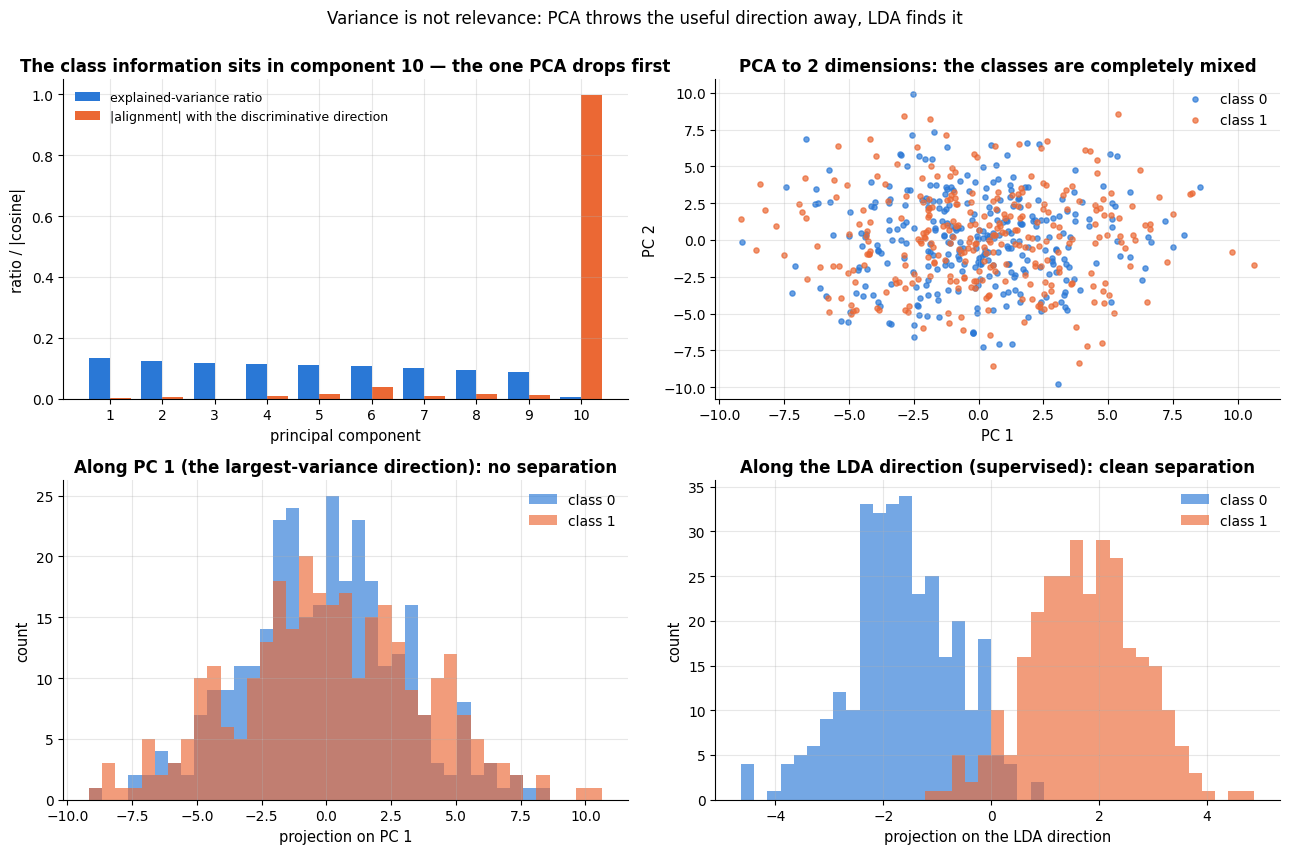

In [27]:
Z_lv_pca = pca_lv.transform(X_lv)[:, :2]                        # scores on the first two components, (600, 2)
lda_lv = LinearDiscriminantAnalysis(n_components=1).fit(X_lv, y_lv)   # two classes -> at most 1 component
z_lv_lda = lda_lv.transform(X_lv).ravel()                       # (600, 1) -> (600,)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
idx = np.arange(1, d_lv + 1)
w = 0.4                                           # bar width; the two bar series are shifted by -w/2 and +w/2
axes[0, 0].bar(idx - w / 2, pca_lv.explained_variance_ratio_, width=w, color=PALETTE[0],
               label="explained-variance ratio")
axes[0, 0].bar(idx + w / 2, align, width=w, color=PALETTE[1],
               label="|alignment| with the discriminative direction")
axes[0, 0].set_xticks(idx)
axes[0, 0].set_xlabel("principal component")
axes[0, 0].set_ylabel("ratio / |cosine|")
axes[0, 0].set_title(f"The class information sits in component {rank_signal} — the one PCA drops first")
axes[0, 0].legend(fontsize=9)

for c, name in enumerate(["class 0", "class 1"]):
    axes[0, 1].scatter(Z_lv_pca[y_lv == c, 0], Z_lv_pca[y_lv == c, 1], s=14, alpha=0.7,
                       color=PALETTE[c], label=name)
axes[0, 1].set_xlabel("PC 1"); axes[0, 1].set_ylabel("PC 2")
axes[0, 1].set_title("PCA to 2 dimensions: the classes are completely mixed")
axes[0, 1].legend()

# 40 shared bin edges per panel, so both classes' histograms use the same bins
bins_pc = np.linspace(Z_lv_pca[:, 0].min(), Z_lv_pca[:, 0].max(), 40)
bins_ld = np.linspace(z_lv_lda.min(), z_lv_lda.max(), 40)
for c in (0, 1):
    axes[1, 0].hist(Z_lv_pca[y_lv == c, 0], bins=bins_pc, alpha=0.65, color=PALETTE[c], label=f"class {c}")
    axes[1, 1].hist(z_lv_lda[y_lv == c], bins=bins_ld, alpha=0.65, color=PALETTE[c], label=f"class {c}")
axes[1, 0].set_xlabel("projection on PC 1"); axes[1, 0].set_ylabel("count")
axes[1, 0].set_title("Along PC 1 (the largest-variance direction): no separation")
axes[1, 0].legend()
axes[1, 1].set_xlabel("projection on the LDA direction"); axes[1, 1].set_ylabel("count")
axes[1, 1].set_title("Along the LDA direction (supervised): clean separation")
axes[1, 1].legend()
fig.suptitle("Variance is not relevance: PCA throws the useful direction away, LDA finds it", y=1.0)
plt.tight_layout()
plt.show()

The picture is unambiguous: every one of the nine noise directions has more variance than
the signal, so the signal ends up in the *last* component; two principal components show a
featureless blob; one supervised direction splits the classes almost perfectly. The
downstream consequence is what matters in practice:

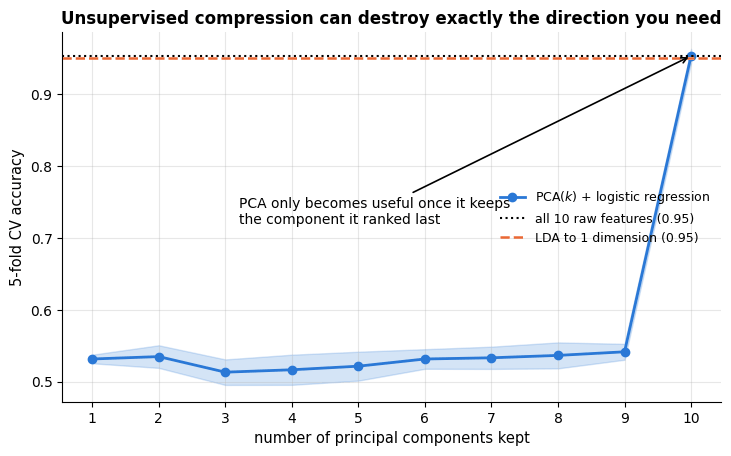

PCA with 1 component: 0.532;  with 9: 0.542;  with all 10: 0.953;  LDA with 1: 0.950


In [28]:
comp_grid_lv = np.arange(1, d_lv + 1)
acc_pca_lv, se_pca_lv = [], []
for kk in comp_grid_lv:
    pipe_lv = Pipeline([("pca", PCA(n_components=kk, random_state=RANDOM_STATE)),
                        ("lr", LogisticRegression(max_iter=2000))])
    s = cross_val_score(pipe_lv, X_lv, y_lv, cv=cv)
    acc_pca_lv.append(s.mean()); se_pca_lv.append(s.std() / np.sqrt(len(s)))   # mean and standard error of 5 scores
acc_pca_lv, se_pca_lv = np.array(acc_pca_lv), np.array(se_pca_lv)   # arrays, so the band below is element-wise

acc_raw_lv = cross_val_score(LogisticRegression(max_iter=2000), X_lv, y_lv, cv=cv).mean()   # no reduction
# LDA to one dimension inside the pipeline, so it only sees the labels of the training folds
acc_lda_lv = cross_val_score(Pipeline([("lda", LinearDiscriminantAnalysis(n_components=1)),
                                       ("lr", LogisticRegression(max_iter=2000))]), X_lv, y_lv, cv=cv).mean()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(comp_grid_lv, acc_pca_lv, marker="o", color=PALETTE[0], label="PCA($k$) + logistic regression")
# fill_between(x, lower, upper) shades the band of ± one standard error
ax.fill_between(comp_grid_lv, acc_pca_lv - se_pca_lv, acc_pca_lv + se_pca_lv, color=PALETTE[0], alpha=0.2)
ax.axhline(acc_raw_lv, color="black", ls=":", lw=1.5, label=f"all {d_lv} raw features ({acc_raw_lv:.2f})")
ax.axhline(acc_lda_lv, color=PALETTE[1], ls="--", lw=1.8, label=f"LDA to 1 dimension ({acc_lda_lv:.2f})")
# arrowprops draws an arrow from the text (at xytext) to the point xy
ax.annotate("PCA only becomes useful once it keeps\nthe component it ranked last",
            xy=(d_lv, acc_pca_lv[-1]), xytext=(3.2, 0.72),
            arrowprops=dict(arrowstyle="->", lw=1.2), fontsize=10)
ax.set_xticks(comp_grid_lv)
ax.set_xlabel("number of principal components kept")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Unsupervised compression can destroy exactly the direction you need")
ax.legend(loc="center right", fontsize=9)
plt.show()
print(f"PCA with 1 component: {acc_pca_lv[0]:.3f};  with {d_lv - 1}: {acc_pca_lv[-2]:.3f};  "   # [-2]: 9 components
      f"with all {d_lv}: {acc_pca_lv[-1]:.3f};  LDA with 1: {acc_lda_lv:.3f}")

A single LDA dimension matches what PCA needs all ten components to achieve. Real data are
rarely this adversarial — on the digits (section 2.6) the class information *is* in the
high-variance directions, which is why PCA works so well there — but "rarely" is not
"never", and the check is cheap: **cross-validate the downstream task instead of trusting
the explained-variance ratio** (section 9.1). If you have labels and want a small
projection, LDA is the tool built for the job; if you want to keep PCA, keep enough
components that the low-variance signal survives.

> **Warning.** The same trap is waiting in feature selection by variance
> (`VarianceThreshold`) and in "drop the near-constant columns" folklore. Low variance
> means low *spread*, not low *information*.

### 8.2 Demonstrated failure — t-SNE: the map has no scale

Section 5.3 showed qualitatively that t-SNE equalises cluster sizes and distorts
inter-cluster distances. Here we measure it. We build three isotropic Gaussian clusters in
$\mathbb{R}^{20}$ whose geometry we *choose*:

| cluster | centre | radius (standard deviation) |
|---|---|---|
| A | origin | 1.0 |
| B | 10 units from A | 0.25 |
| C | 40 units from A, 30 from B | 3.0 |

so the true radius ratios are $r_B/r_A = 0.25$ and $r_C/r_A = 3.0$, and the true distance
ratios are $d_{BC}/d_{AB} = 3.0$ and $d_{AC}/d_{AB} = 4.0$. A faithful 2-D picture should
reproduce those four numbers. PCA nearly does — it is an orthogonal projection, so it can
only shrink distances, never invent them — while t-SNE reports something else entirely.

In [29]:
# e.g. 20 blood values of three patient groups: A typical, B a tight subgroup near A, C varied and far away
centres_geo = np.zeros((3, 20))                      # one cluster centre per row, in 20-D; A stays at the origin
centres_geo[1, 0], centres_geo[2, 0] = 10.0, 40.0    # B at 10 and C at 40 along the first axis
radii_geo = np.array([1.0, 0.25, 3.0])               # standard deviation of each cluster
# 150 points per cluster (centre + radius * standard normal noise); np.vstack stacks the three (150, 20) blocks
X_geo = np.vstack([c + s * rng.normal(size=(150, 20)) for c, s in zip(centres_geo, radii_geo)])
y_geo = np.repeat([0, 1, 2], 150)

def geometry_ratios(Z, labels):
    """Median cluster radii and centroid distances, each normalised to cluster A / the A-B distance.

    Z is a data matrix or embedding (n, dims); labels gives the cluster 0, 1 or 2 (A, B, C) of each row.
    A cluster's radius is the median distance of its points to its centroid.
    Returns the array [r_B / r_A, r_C / r_A, d_BC / d_AB, d_AC / d_AB].
    """
    cents = np.array([Z[labels == c].mean(axis=0) for c in range(3)])    # centroid of each cluster, (3, dims)
    # np.linalg.norm(..., axis=1) is the length of each row: each point's distance to its centroid
    rad = np.array([np.median(np.linalg.norm(Z[labels == c] - cents[c], axis=1)) for c in range(3)])
    d_ab = np.linalg.norm(cents[0] - cents[1])
    d_bc = np.linalg.norm(cents[1] - cents[2])
    d_ac = np.linalg.norm(cents[0] - cents[2])
    return np.array([rad[1] / rad[0], rad[2] / rad[0], d_bc / d_ab, d_ac / d_ab])

Z_geo_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_geo)
Z_geo_tsne = TSNE(n_components=2, perplexity=30, init="pca", max_iter=500,
                  random_state=RANDOM_STATE).fit_transform(X_geo)

truth = np.array([radii_geo[1] / radii_geo[0], radii_geo[2] / radii_geo[0], 30 / 10, 40 / 10])   # the built-in ratios
# one column per source of the four ratios, one row per ratio
table_geo = pd.DataFrame(
    {"ground truth": truth, "PCA": geometry_ratios(Z_geo_pca, y_geo), "t-SNE": geometry_ratios(Z_geo_tsne, y_geo)},
    index=["radius B / radius A", "radius C / radius A", "dist(B,C) / dist(A,B)", "dist(A,C) / dist(A,B)"])
table_geo.round(2)

,ground truth,PCA,t-SNE
radius B / radius A,0.25,0.20,0.96
radius C / radius A,3.00,3.16,0.98
"dist(B,C) / dist(A,B)",3.00,3.03,0.96
"dist(A,C) / dist(A,B)",4.00,4.02,0.93


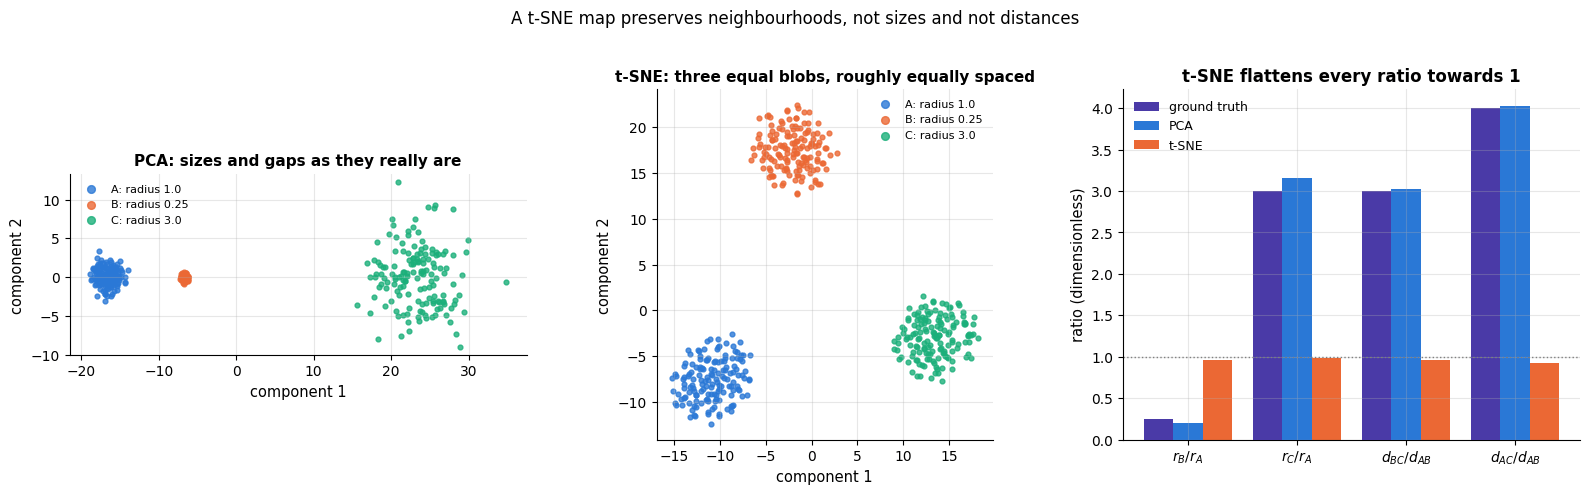

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
names_geo = ["A: radius 1.0", "B: radius 0.25", "C: radius 3.0"]
for ax, Z, title in [(axes[0], Z_geo_pca, "PCA: sizes and gaps as they really are"),
                     (axes[1], Z_geo_tsne, "t-SNE: three equal blobs, roughly equally spaced")]:
    for c in range(3):
        ax.scatter(Z[y_geo == c, 0], Z[y_geo == c, 1], s=12, alpha=0.8, color=PALETTE[c], label=names_geo[c])
    ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, markerscale=1.6)     # markerscale enlarges the legend's dots
axes[0].set_aspect("equal")                    # one unit on x = one unit on y, so sizes and gaps are not distorted
axes[1].set_aspect("equal")

x_geo = np.arange(len(table_geo))              # one group of bars per ratio
for i, (col, colour) in enumerate(zip(table_geo.columns, [PALETTE[6], PALETTE[0], PALETTE[1]])):
    # (i - 1) * 0.27 places the three series left, centre and right within each group
    axes[2].bar(x_geo + (i - 1) * 0.27, table_geo[col], width=0.27, color=colour, label=col)
axes[2].set_xticks(x_geo)
axes[2].set_xticklabels(["$r_B/r_A$", "$r_C/r_A$", "$d_{BC}/d_{AB}$", "$d_{AC}/d_{AB}$"])
axes[2].axhline(1, color="gray", lw=1, ls=":")
axes[2].set_ylabel("ratio (dimensionless)")
axes[2].set_title("t-SNE flattens every ratio towards 1")
axes[2].legend(fontsize=9)
fig.suptitle("A t-SNE map preserves neighbourhoods, not sizes and not distances", y=1.02)
plt.tight_layout()
plt.show()

t-SNE returns three blobs of practically the same size, and squeezes a fourfold difference
in separation down to a factor of two, from data in which one cluster is twelve times
tighter than another. This is not a bug: the per-point bandwidth
$\sigma_i$ deliberately normalises local density, and the Student-$t$ tail makes all
sufficiently large distances almost equally cheap. The map answers "who is next to whom",
and nothing else.

> **Key idea.** Read a t-SNE (or UMAP) plot as a *graph drawing*: the edges are meaningful,
> the coordinates are not. If a question in your analysis involves the word "how far" or
> "how big", answer it in the original space — or use PCA/MDS, which are about distances.

### 8.3 Demonstrated failure — NMF: a different answer every time you start

PCA has one answer (up to signs). NMF's objective is non-convex, so the answer depends on
the initialisation; run it twice from random starts and you get two different sets of
topics, both locally optimal. The deterministic SVD-based `init="nndsvda"` is the usual
cure, and it is worth knowing how large the spread would otherwise be. We re-fit the
six-topic model of section 3.3 from four random starts and compare.

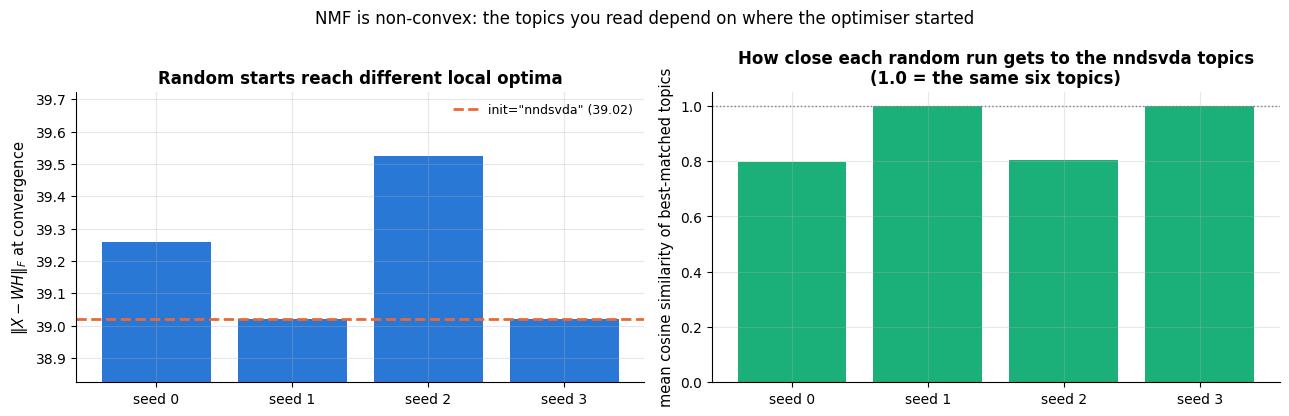

reconstruction error: nndsvda 39.020, random starts 39.020–39.524
topic agreement with nndsvda across seeds: 0.80–1.00


In [31]:
from scipy.optimize import linear_sum_assignment

def unit_rows(M):
    """Return M with every row divided by its Euclidean length, so that each row has length 1."""
    # keepdims=True keeps the norms as an (n, 1) column that broadcasts across each row;
    # np.maximum(..., 1e-12) avoids dividing by zero for an all-zero row
    return M / np.maximum(np.linalg.norm(M, axis=1, keepdims=True), 1e-12)

nmf_ref = NMF(n_components=6, init="nndsvda", random_state=RANDOM_STATE, max_iter=1000).fit(A)   # the reference fit
H_ref = unit_rows(nmf_ref.components_)          # (6, words): topic-word vectors of length 1

seeds = [0, 1, 2, 3]
errs_rand, match_rand = [], []
for s in seeds:
    m = NMF(n_components=6, init="random", random_state=s, max_iter=1000).fit(A)   # random non-negative start
    errs_rand.append(m.reconstruction_err_)     # ||A - WH||_F (Frobenius norm) at convergence
    sim = unit_rows(m.components_) @ H_ref.T                    # cosine similarity between topic-word vectors
    # linear_sum_assignment(cost) finds the one-to-one row-to-column pairing with the smallest total cost (Hungarian
    # algorithm) and returns the row and column indices; the minus sign makes it maximise the similarity instead
    r, c = linear_sum_assignment(-sim)                          # best one-to-one matching of topics
    match_rand.append(sim[r, c].mean())         # sim[r, c] picks the similarity of each matched pair

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar([f"seed {s}" for s in seeds], errs_rand, color=PALETTE[0])
axes[0].axhline(nmf_ref.reconstruction_err_, color=PALETTE[1], ls="--", lw=2,
                label=f'init="nndsvda" ({nmf_ref.reconstruction_err_:.2f})')
# zoom the y-axis onto the errors; errs_rand + [x] is a new list with one more value
axes[0].set_ylim(min(errs_rand + [nmf_ref.reconstruction_err_]) * 0.995,
                 max(errs_rand + [nmf_ref.reconstruction_err_]) * 1.005)
axes[0].set_ylabel(r"$\|X - WH\|_F$ at convergence")      # r"..." is a raw string: the backslashes stay for LaTeX
axes[0].set_title('Random starts reach different local optima')
axes[0].legend(fontsize=9)

axes[1].bar([f"seed {s}" for s in seeds], match_rand, color=PALETTE[2])
axes[1].axhline(1.0, color="gray", ls=":", lw=1)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("mean cosine similarity of best-matched topics")
axes[1].set_title('How close each random run gets to the nndsvda topics\n(1.0 = the same six topics)')
fig.suptitle("NMF is non-convex: the topics you read depend on where the optimiser started")
plt.tight_layout()
plt.show()
print(f"reconstruction error: nndsvda {nmf_ref.reconstruction_err_:.3f}, "
      f"random starts {min(errs_rand):.3f}–{max(errs_rand):.3f}")
print(f"topic agreement with nndsvda across seeds: {min(match_rand):.2f}–{max(match_rand):.2f}")

The reconstruction errors differ only in the third digit, yet the *topics* — the thing you
would read and report — do not match one another nearly as well. That is the honest summary
of every non-convex factorisation: the loss is nearly flat across very different-looking
solutions. Fix the initialisation, report it, and check that your conclusions survive a
change of seed. The same advice applies to t-SNE, UMAP and the ALS recommender.

### 8.4 The tables

**PCA (and its linear relatives: truncated SVD, LDA, random projections)**

| | |
|---|---|
| **Assumptions / inductive bias** | the interesting structure is a *linear* subspace, and "interesting" = "high variance"; features are on comparable scales; second moments describe the data (exactly right for Gaussians) |
| **Strengths** | closed-form, deterministic and fast; optimal linear reconstruction for every $k$ at once (Eckart–Young), so one fit gives the whole family; invertible (`inverse_transform`), so you can denoise and look at what was lost; has a `transform` for new data, hence usable inside a `Pipeline`; only one hyper-parameter |
| **Weaknesses / failure modes** | cannot unroll curved manifolds (section 5); **variance ≠ relevance** (section 8.1); unit-dependent — a rescaled feature changes the answer (section 2.5); one outlier can tilt a component; components are dense, so each one mixes all original features and is hard to name |
| **Data it suits** | continuous, roughly elliptical clouds; any $n$ vs. $d$ (use `randomized`/`IncrementalPCA` when both are large); standardise unless features share a unit; no missing values (impute first, or use probabilistic PCA) |
| **Complexity** | $O(n d \min(n, d))$ for a full SVD, $O(n d k)$ randomised; memory $O(nd)$, or $O(bd)$ per batch for `IncrementalPCA`; transform is $O(n d k)$ |
| **Interpretability** | loadings show which features move together (section 2.5); explained-variance ratios quantify what each component is worth; the reconstruction shows exactly what $k$ components can and cannot represent |
| **Use it when / avoid it when** | Use it first, always: as a denoiser, a compressor, a plotting device and a baseline for anything fancier. Avoid it as your *only* reduction when you have labels (use LDA or CV-chosen $k$), when the manifold is curved, or when you need sparse, nameable factors. |

**NMF (and topic factorisations of count data)**

| | |
|---|---|
| **Assumptions / inductive bias** | the data are non-negative and *additive*: every sample is a sum of parts, with no cancellation; parts are shared across samples |
| **Strengths** | parts-based factors that a domain expert can read ("this topic is the laptop topic"); works directly on sparse count / TF-IDF matrices; the same machinery gives topics, audio sources and image parts; naturally sparse factors |
| **Weaknesses / failure modes** | non-convex, so the solution depends on the initialisation and the seed (section 8.3); needs $k$ and a divergence chosen in advance; no `inverse_transform` guarantee of optimality — PCA always reconstructs better at the same $k$; sensitive to how you weight the matrix (raw counts, TF-IDF, `max_df`), as section 3.3 showed dramatically; undefined for data with negative entries |
| **Data it suits** | non-negative matrices: term–document counts, spectra, images, purchase counts; $n$ and $d$ up to millions if the matrix is sparse |
| **Complexity** | $O(\text{nnz} \cdot k)$ per coordinate-descent sweep; tens to hundreds of sweeps; memory $O(\text{nnz} + (n + d)k)$ |
| **Interpretability** | the best of the family: rows of $\mathbf{H}$ are readable parts, rows of $\mathbf{W}$ are mixing weights, and both are non-negative |
| **Use it when / avoid it when** | Use it when the data are counts and you must *explain* the factors. Avoid it when you need the optimal low-rank approximation (use the SVD), when the data have signs, or when reproducibility across seeds matters more than readability. |

**t-SNE and UMAP (neighbourhood embeddings)**

| | |
|---|---|
| **Assumptions / inductive bias** | only *local* neighbourhoods carry meaning; the data lie on a manifold that is locally Euclidean; the goal is a picture, not a coordinate system |
| **Strengths** | by far the most revealing 2-D pictures of clustered high-dimensional data; find structure that no linear projection shows; UMAP is fast enough for millions of points and has a `transform` |
| **Weaknesses / failure modes** | cluster sizes, inter-cluster distances and empty space are **not** meaningful (section 8.2); low perplexity conjures clusters out of pure noise (section 5.3); non-convex, so every seed gives a different picture; t-SNE has no `transform` for new data; $O(n \log n)$ per iteration is still slow; a continuous manifold gets torn into apparent clusters |
| **Data it suits** | anything you can define a distance on, after a first reduction (PCA to 30–50 dimensions is the standard preprocessing); $n$ from hundreds to $\sim 10^5$ for t-SNE, far more for UMAP |
| **Complexity** | t-SNE: $O(n^2)$ exact, $O(n\log n)$ Barnes–Hut, per iteration, $\sim 10^3$ iterations; UMAP: approximate $k$-NN graph plus stochastic-gradient layout, roughly $O(n^{1.14})$ in practice |
| **Interpretability** | groups and their members; *nothing* quantitative — no axes, no distances, no sizes |
| **Use it when / avoid it when** | Use it to explore, to generate hypotheses, and to communicate cluster structure you have verified elsewhere. Never use its coordinates as features, never cluster on them and report the clusters as data structure, never compare two maps numerically. |

**Latent-factor matrix factorisation (recommenders)**

| | |
|---|---|
| **Assumptions / inductive bias** | the ratings matrix is approximately low-rank plus row/column offsets; entries are missing *at random enough* that observed entries identify the factors; users with similar histories will behave similarly |
| **Strengths** | handles a 90–99 % missing matrix natively by fitting only the observed entries; $k$ and $\lambda$ give a smooth capacity dial; biases alone already beat the global mean; ALS parallelises over users and items, SGD streams; extends cleanly to implicit feedback, time and side information |
| **Weaknesses / failure modes** | **cold start**: a new user or item has no observed entries and gets only the biases; popularity bias — heavy items dominate the loss; non-convex, so the factors are not identifiable (only the product $\mathbf{P}\mathbf{Q}^\top$ is); RMSE on held-out ratings is a poor proxy for whether a recommendation is *useful*; needs explicit regularisation or it fits noise immediately (section 4) |
| **Data it suits** | very sparse, very large user × item matrices; millions of rows and columns with $\sim 10^{-2}$ density; ratings, plays, clicks, purchases |
| **Complexity** | ALS: $O(|\mathcal{K}|k^2 + (n_u + n_i)k^3)$ per sweep; SGD: $O(|\mathcal{K}|k)$ per epoch; memory $O(|\mathcal{K}| + (n_u + n_i)k)$ |
| **Interpretability** | biases are directly meaningful (generous users, well-liked items); latent factors are rotation-indeterminate and only interpretable by inspecting the items at each extreme |
| **Use it when / avoid it when** | Use it as the baseline for any recommendation problem with explicit or implicit feedback. Avoid it when most users or items are brand new (use content features), or when the business question is ranking quality rather than rating accuracy — measure the thing you care about. |

**The supporting cast, in one table**

| Method | One-line bias | Strength | Failure mode |
|---|---|---|---|
| **LDA** (supervised) | class means are far apart relative to within-class scatter | at most $K-1$ dimensions that are *about the classes*; doubles as a classifier | needs labels; assumes shared covariance; $K-1$ may be far too few; overfits when $n \lesssim d$ |
| **Random projection** | distances are all that matter | no fitting, $O(1)$ memory for the map, distance error $\pm\varepsilon$ guaranteed by Johnson–Lindenstrauss | keeps noise as faithfully as signal; needs a large $k$ for small $\varepsilon$; no interpretation |
| **Truncated SVD (LSA)** | as PCA, but without centring, so sparse matrices stay sparse | the standard reduction for TF-IDF; works on `scipy.sparse` | components are signed and hard to name; the uncentred first component mostly tracks document length |
| **Kernel PCA** | similarity is given by a kernel | non-linear structure with a `transform`; the circles of section 5.1 | $O(n^2)$ memory, $O(n^3)$ time; `gamma` is delicate; the pre-image (inverse transform) is approximate |
| **Isomap** | geodesic distances along the manifold | genuinely unrolls the swiss roll; global structure preserved | one badly placed neighbour "short-circuits" the manifold and ruins the graph; $O(n^2)$ |
| **LLE** | local linear reconstruction weights | fast sparse eigenproblem | collapses classes into spikes (section 5.4); regularisation-sensitive |

## 9. Tuning guide

Dimensionality reduction has fewer knobs than a gradient-boosting model, but they matter
more, because they act on the *representation* that everything downstream sees.

| Method | Parameter | What it controls | Typical range / scale | Default to start from |
|---|---|---|---|---|
| `PCA` | `n_components` | capacity: bias (too few) vs. noise (too many) | 2–200, or a variance target, or an integer chosen by CV | `0.95` (a float means "this much variance") |
| | `whiten` | whether components are rescaled to unit variance | `False` / `True` | `False` |
| | `svd_solver` | exactness vs. speed | `full`, `randomized`, `arpack`, `auto` | `auto` |
| | *(scaling before it)* | which features may dominate the variance | `StandardScaler` or nothing | standardise unless features share a unit |
| `NMF` | `n_components` | number of parts / topics | 2–100, linear; judged by readability | the number of groups you expect |
| | `init`, `random_state` | which local optimum you land in | `nndsvda` (deterministic) or `random` | `nndsvda` |
| | `alpha_W`, `l1_ratio` | sparsity of the factors | 0–1, log | `0` (no penalty) |
| `TSNE` | `perplexity` | effective number of neighbours = local vs. global | 5–50, roughly log; must be $< n$ | `30` |
| | `learning_rate` | step size of the layout optimiser | 10–1000, log, or `"auto"` = $n/12$ | `"auto"` |
| | `max_iter` | whether the layout has converged | 250 (minimum) – 2000, linear | `1000` |
| | `init` | reproducibility and global structure | `"pca"` vs. `"random"` | `"pca"` |
| `umap.UMAP` | `n_neighbors` | local vs. global, like perplexity | 5–100, log | `15` |
| | `min_dist` | how tightly points may pack in the map | 0.0–0.99, linear | `0.1` |
| biased MF | `n_factors` ($k$) | capacity of the latent space | 1–200, log | 10–50, then tune |
| | `reg` ($\lambda$) | shrinkage of factors and biases | $10^{-2}$–$10^{2}$, log | tune jointly with $k$ |
| | `n_sweeps` | convergence of ALS | 10–30, linear | 15 |

**Tune in this order.**

1. **The scaling decision, before anything else** (section 9.3). It changes which
   directions exist; no later parameter can undo it.
2. **`n_components` / `n_factors` / the granularity parameter** (sections 9.1, 9.6). This
   dominates every other choice. Pick it by the *downstream* metric when there is a
   downstream task and by cumulative variance only when there is not.
3. **The locality parameter of a neighbourhood method** — `perplexity`, `n_neighbors`
   (sections 9.4, 9.5). Always look at three or four values; there is no single right one.
4. **Regularisation, where the method has it** — `reg` for matrix factorisation, `alpha_W`
   for NMF. It interacts with capacity: more factors need more shrinkage, which is why
   section 9.6 tunes the pair on a grid instead of one at a time.
5. **`whiten`, `init`, `svd_solver`, `n_sweeps`** — cheap insurance and speed knobs
   (section 9.2). Set them once, sensibly, and stop thinking about them.

### 9.1 `n_components`: two criteria, and what to do when they disagree

There are two defensible ways to choose $k$.

- **Cumulative explained variance.** Keep enough components for 90 / 95 / 99 % of the
  variance. It needs no labels and no model, and it is the right answer when the reduction
  *is* the deliverable (compression, storage, a plot).
- **Cross-validation on the downstream task.** Put the reduction in a `Pipeline` and let
  the metric you actually care about pick $k$. It is the right answer whenever there is a
  downstream task — which is most of the time.

They are answers to different questions, so they need not agree. Below, both criteria are
computed for the digits (where they roughly agree) and for the breast-cancer data (where
they emphatically do not).

In [32]:
from sklearn.datasets import load_breast_cancer

X_bc, y_bc = load_breast_cancer(return_X_y=True)     # return_X_y=True returns the arrays: X (569, 30), y (569,)
bc_grid = [1, 2, 3, 4, 5, 7, 10, 15, 20, 30]
# all 30 components of the standardised data, to read off the cumulative variance
pca_bc_full = PCA(random_state=RANDOM_STATE).fit(StandardScaler().fit_transform(X_bc))
cum_bc = np.cumsum(pca_bc_full.explained_variance_ratio_)
k95_bc = int(np.searchsorted(cum_bc, 0.95) + 1)      # components needed for 95 % of the variance

acc_bc, se_bc = [], []
for kk in bc_grid:
    pipe_bc = Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=kk, random_state=RANDOM_STATE)),
                        ("lr", LogisticRegression(max_iter=5000))])
    s = cross_val_score(pipe_bc, X_bc, y_bc, cv=cv)
    acc_bc.append(s.mean()); se_bc.append(s.std() / np.sqrt(len(s)))
acc_bc, se_bc = np.array(acc_bc), np.array(se_bc)
k_cv_bc = bc_grid[int(np.argmax(acc_bc))]           # the k with the highest mean CV accuracy
# one-standard-error rule: the smallest k within one SE of the best
thr_bc = acc_bc.max() - se_bc[int(np.argmax(acc_bc))]      # best score minus its standard error
k_1se_bc = bc_grid[int(np.argmax(acc_bc >= thr_bc))]       # argmax of a boolean array = position of the first True
print(f"breast cancer: 95 % of the variance needs k = {k95_bc}; "
      f"CV-optimal k = {k_cv_bc} ({acc_bc.max():.3f}); one-SE choice k = {k_1se_bc}")

breast cancer: 95 % of the variance needs k = 10; CV-optimal k = 10 (0.977); one-SE choice k = 10


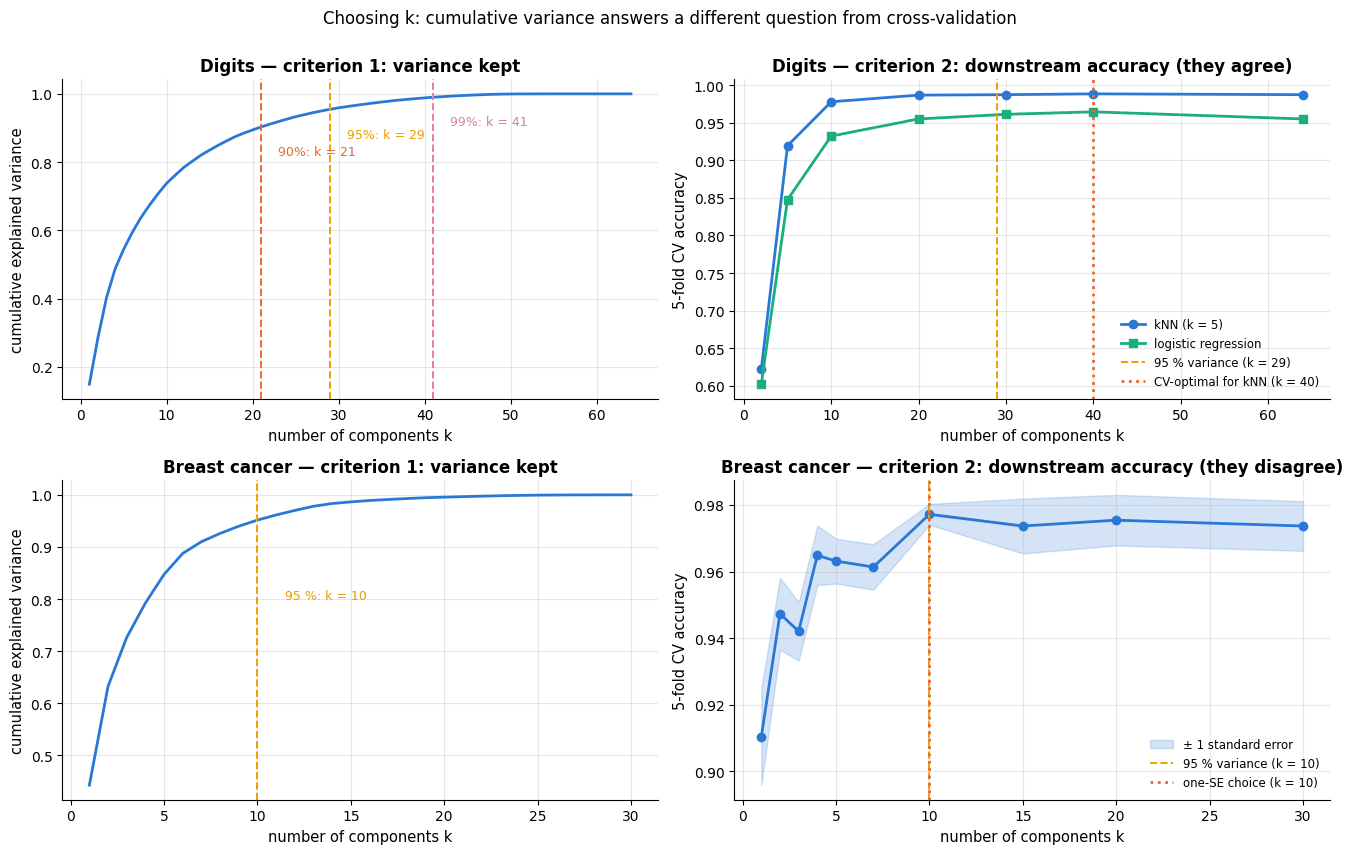

In [33]:
k_cv_digits = n_comps[int(np.argmax(scores["kNN (k = 5)"]))]     # best k for kNN in section 2.6

fig, axes = plt.subplots(2, 2, figsize=(13.5, 8.5))
# --- digits (top row): the two criteria roughly agree
axes[0, 0].plot(np.arange(1, d + 1), cum, color=PALETTE[0], lw=2)
for t, kk, colour in [(0.90, k_90, PALETTE[1]), (0.95, k_95, PALETTE[3]), (0.99, k_99, PALETTE[4])]:
    axes[0, 0].axvline(kk, color=colour, ls="--", lw=1.4)
    axes[0, 0].annotate(f"{t:.0%}: k = {kk}", xy=(kk, t), xytext=(kk + 2, t - 0.08), color=colour, fontsize=9)
axes[0, 0].set_xlabel("number of components k"); axes[0, 0].set_ylabel("cumulative explained variance")
axes[0, 0].set_title("Digits — criterion 1: variance kept")

axes[0, 1].plot(n_comps, scores["kNN (k = 5)"], marker="o", color=PALETTE[0], label="kNN (k = 5)")
axes[0, 1].plot(n_comps, scores["logistic regression"], marker="s", color=PALETTE[2], label="logistic regression")
axes[0, 1].axvline(k_95, color=PALETTE[3], ls="--", lw=1.4, label=f"95 % variance (k = {k_95})")
axes[0, 1].axvline(k_cv_digits, color=PALETTE[1], ls=":", lw=2, label=f"CV-optimal for kNN (k = {k_cv_digits})")
axes[0, 1].set_xlabel("number of components k"); axes[0, 1].set_ylabel("5-fold CV accuracy")
axes[0, 1].set_title("Digits — criterion 2: downstream accuracy (they agree)")
axes[0, 1].legend(fontsize=8.5, loc="lower right")

# --- breast cancer (bottom row): the two criteria disagree by an order of magnitude
axes[1, 0].plot(np.arange(1, len(cum_bc) + 1), cum_bc, color=PALETTE[0], lw=2)
axes[1, 0].axvline(k95_bc, color=PALETTE[3], ls="--", lw=1.4)
axes[1, 0].annotate(f"95 %: k = {k95_bc}", xy=(k95_bc, 0.95), xytext=(k95_bc + 1.5, 0.80), color=PALETTE[3], fontsize=9)
axes[1, 0].set_xlabel("number of components k"); axes[1, 0].set_ylabel("cumulative explained variance")
axes[1, 0].set_title("Breast cancer — criterion 1: variance kept")

axes[1, 1].plot(bc_grid, acc_bc, marker="o", color=PALETTE[0])
axes[1, 1].fill_between(bc_grid, acc_bc - se_bc, acc_bc + se_bc, color=PALETTE[0], alpha=0.2, label="± 1 standard error")
axes[1, 1].axvline(k95_bc, color=PALETTE[3], ls="--", lw=1.4, label=f"95 % variance (k = {k95_bc})")
axes[1, 1].axvline(k_1se_bc, color=PALETTE[1], ls=":", lw=2, label=f"one-SE choice (k = {k_1se_bc})")
axes[1, 1].set_xlabel("number of components k"); axes[1, 1].set_ylabel("5-fold CV accuracy")
axes[1, 1].set_title("Breast cancer — criterion 2: downstream accuracy (they disagree)")
axes[1, 1].legend(fontsize=8.5, loc="lower right")
fig.suptitle("Choosing k: cumulative variance answers a different question from cross-validation", y=1.0)
plt.tight_layout()
plt.show()

On the digits both criteria land in the same neighbourhood, because the pixels that vary
most are also the pixels that distinguish digits. On the breast-cancer data the variance
criterion asks for an order of magnitude more components than the classifier needs: two or
three standardised components already carry the malignant/benign contrast, and everything
after them adds variance without adding accuracy. If you had compressed this dataset "to
95 % of the variance" you would have kept several times more numbers than the task
requires.

**Practical notes.**

- `PCA(n_components=0.95)` accepts a *float* and picks $k$ itself — convenient, and exactly
  the criterion-1 answer. Inside a pipeline it is refitted per fold, which is correct.
- When the CV curve is flat, apply the **one-standard-error rule**: take the smallest $k$
  whose score is within one standard error of the best (above, $k = $ `k_1se_bc`). Flat is
  the normal case, and the simplest model on the plateau is the one that will transfer.
- If the best $k$ sits at the **edge of your grid**, extend the grid. A best-at-the-maximum
  is a message that the reduction is not helping at all.
- $k$ is not worth tuning finely: the curve between $k$ and $k+1$ is noise. Use a
  geometric-ish grid (2, 5, 10, 20, 40, …).

### 9.2 `whiten`: helpful for distance-based models, harmful when the tail is noise

Whitening divides each score by $\sqrt{\lambda_j}$, so the components come out with equal
variance. That is exactly what a distance-based model wants when the raw components have
wildly different scales — and exactly what you do *not* want when the trailing components
are measurement noise, because whitening amplifies them to the same size as the signal.

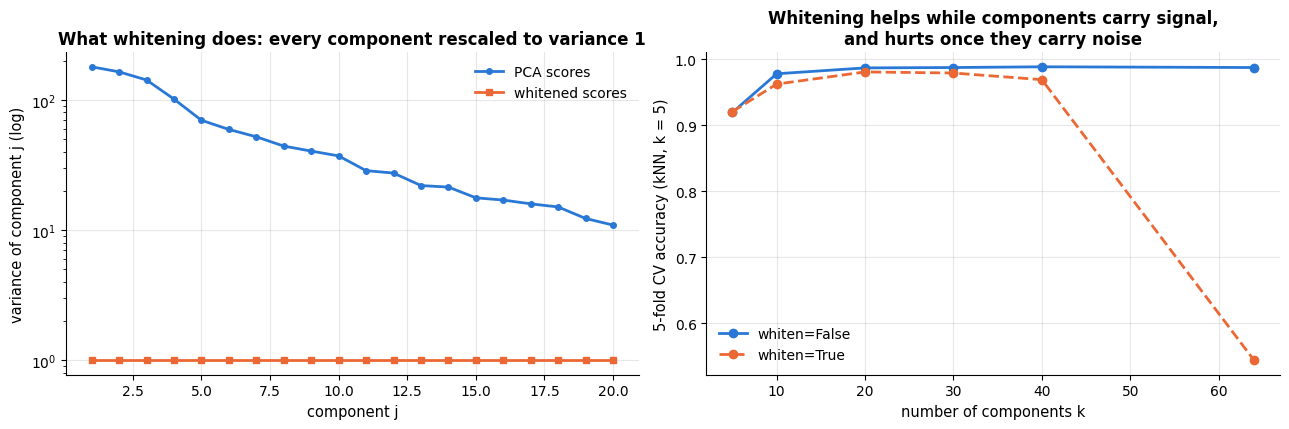

whiten=False: k=5: 0.919  k=10: 0.978  k=20: 0.987  k=30: 0.987  k=40: 0.988  k=64: 0.987
whiten=True : k=5: 0.920  k=10: 0.962  k=20: 0.981  k=30: 0.979  k=40: 0.969  k=64: 0.544


In [34]:
whiten_grid = [5, 10, 20, 30, 40, 64]
acc_whiten = {False: [], True: []}              # whiten flag -> mean CV accuracy for each k
for wh in (False, True):
    for kk in whiten_grid:
        pipe_w = Pipeline([("pca", PCA(n_components=kk, whiten=wh, random_state=RANDOM_STATE)),
                           ("knn", KNeighborsClassifier(n_neighbors=5))])
        acc_whiten[wh].append(cross_val_score(pipe_w, X_digits, y_digits, cv=cv).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
# left: the variance of each of the first 20 components, before (the eigenvalues) and after whitening (all 1)
axes[0].plot(np.arange(1, 21), pca_full.explained_variance_[:20], marker="o", ms=4, color=PALETTE[0],
             label="PCA scores")
axes[0].plot(np.arange(1, 21), np.ones(20), marker="s", ms=4, color=PALETTE[1], label="whitened scores")
axes[0].set_yscale("log")
axes[0].set_xlabel("component j"); axes[0].set_ylabel("variance of component j (log)")
axes[0].set_title("What whitening does: every component rescaled to variance 1")
axes[0].legend()

for wh, colour, style in [(False, PALETTE[0], "-"), (True, PALETTE[1], "--")]:
    axes[1].plot(whiten_grid, acc_whiten[wh], marker="o", ls=style, color=colour, label=f"whiten={wh}")
axes[1].set_xlabel("number of components k"); axes[1].set_ylabel("5-fold CV accuracy (kNN, k = 5)")
axes[1].set_title("Whitening helps while components carry signal,\nand hurts once they carry noise")
axes[1].legend()
plt.tight_layout()
plt.show()
for wh in (False, True):
    # {str(wh):5s} pads "True" to the width of "False"; "  ".join(...) joins the per-k results with two spaces
    print(f"whiten={str(wh):5s}: " + "  ".join(f"k={kk}: {a:.3f}" for kk, a in zip(whiten_grid, acc_whiten[wh])))

The pattern is the one the theory predicts. With few components, whitening helps or is
neutral: those components all carry real structure and equalising them stops the first
component from dominating the Euclidean distance. As $k$ grows into the noise tail, the
whitened representation gives a nearly blank pixel direction the same weight as the stroke
directions, and accuracy falls away. **Whiten when you keep few components and the
downstream method is distance- or isotropy-based** (kNN, $k$-means, ICA, a Gaussian mixture
with spherical covariances); leave it off otherwise.

### 9.3 The scaling decision

This is not a hyper-parameter of `PCA` but it dominates the result, so it belongs at the
top of the tuning list. Section 2.5 showed the picture; here is the downstream number, on
the wine data, with everything inside a cross-validated pipeline so that no information
leaks.

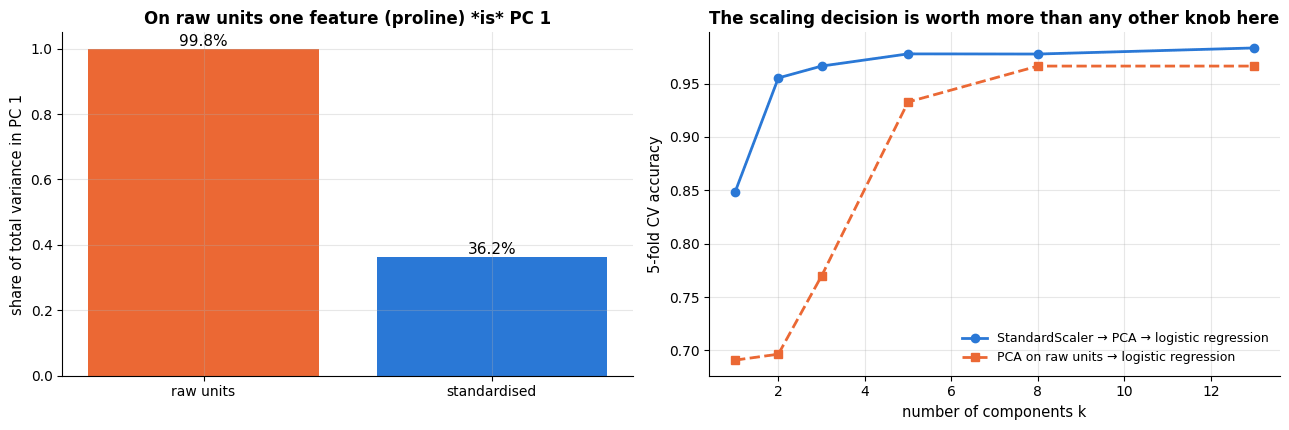

best CV accuracy — standardised: 0.983 at k = 13; raw units: 0.966 at k = 8


In [35]:
wine_grid = [1, 2, 3, 5, 8, 13]
acc_scaled, acc_raw_w = [], []
for kk in wine_grid:
    # standardise -> PCA -> logistic regression, all refitted inside every fold
    acc_scaled.append(cross_val_score(
        Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=kk, random_state=RANDOM_STATE)),
                  ("lr", LogisticRegression(max_iter=5000))]), X_wine, y_wine, cv=cv).mean())
    # the same pipeline without the scaler: PCA on the raw units
    acc_raw_w.append(cross_val_score(
        Pipeline([("pca", PCA(n_components=kk, random_state=RANDOM_STATE)),
                  ("lr", LogisticRegression(max_iter=5000))]), X_wine, y_wine, cv=cv).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].bar(["raw units", "standardised"],
            [pca_raw.explained_variance_ratio_[0], pca_std.explained_variance_ratio_[0]],
            color=[PALETTE[1], PALETTE[0]])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("share of total variance in PC 1")
axes[0].set_title("On raw units one feature (proline) *is* PC 1")
for i, v in enumerate([pca_raw.explained_variance_ratio_[0], pca_std.explained_variance_ratio_[0]]):
    axes[0].annotate(f"{v:.1%}", (i, v), ha="center", va="bottom", fontsize=11)    # value on top of each bar

axes[1].plot(wine_grid, acc_scaled, marker="o", color=PALETTE[0], label="StandardScaler → PCA → logistic regression")
axes[1].plot(wine_grid, acc_raw_w, marker="s", ls="--", color=PALETTE[1], label="PCA on raw units → logistic regression")
axes[1].set_xlabel("number of components k"); axes[1].set_ylabel("5-fold CV accuracy")
axes[1].set_title("The scaling decision is worth more than any other knob here")
axes[1].legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()
print(f"best CV accuracy — standardised: {max(acc_scaled):.3f} at k = {wine_grid[int(np.argmax(acc_scaled))]}; "
      f"raw units: {max(acc_raw_w):.3f} at k = {wine_grid[int(np.argmax(acc_raw_w))]}")

With two components the standardised pipeline is far ahead; the unstandardised one needs
almost the full set of components before it catches up, because its first components are
spending their capacity on the units of `proline` and `magnesium` rather than on chemistry.
The rule is simple: **standardise unless every feature is already in the same unit** (pixel
intensities, counts of the same kind, all-in-euros), and put the scaler inside the pipeline.

### 9.4 t-SNE: `perplexity`, `learning_rate` and `max_iter`

t-SNE has no cross-validated score to optimise, but it does report two numbers you can
look at, and one of them is genuinely useful:

- `kl_divergence_`, the value of the objective. It is **not** comparable across
  perplexities (the target distribution $P$ changes with the perplexity), so never pick a
  perplexity by minimising it. It *is* comparable across `learning_rate` and `max_iter` at
  a fixed perplexity, where it tells you whether the optimiser converged.
- **Trustworthiness** (Venna & Kaski, 2001), `sklearn.manifold.trustworthiness`: the
  fraction of each point's $k$ nearest neighbours in the map that were also its neighbours
  in the original space, penalised by how far the intruders ranked. It is in $[0, 1]$, and
  unlike the KL divergence it is comparable across settings — a direct measurement of the
  one thing t-SNE claims to preserve.

> **Real-life example.** A music-streaming service shows listeners a 2-D map of its catalogue
> and lets them click on the songs around a favourite. Trustworthiness measures what that relies
> on: are the songs placed next to a song on the map really similar to it in the original audio
> features? A value close to 1 means few strangers sit among the neighbours.

The perplexity panels of section 5.2 are re-used here with those two numbers attached.

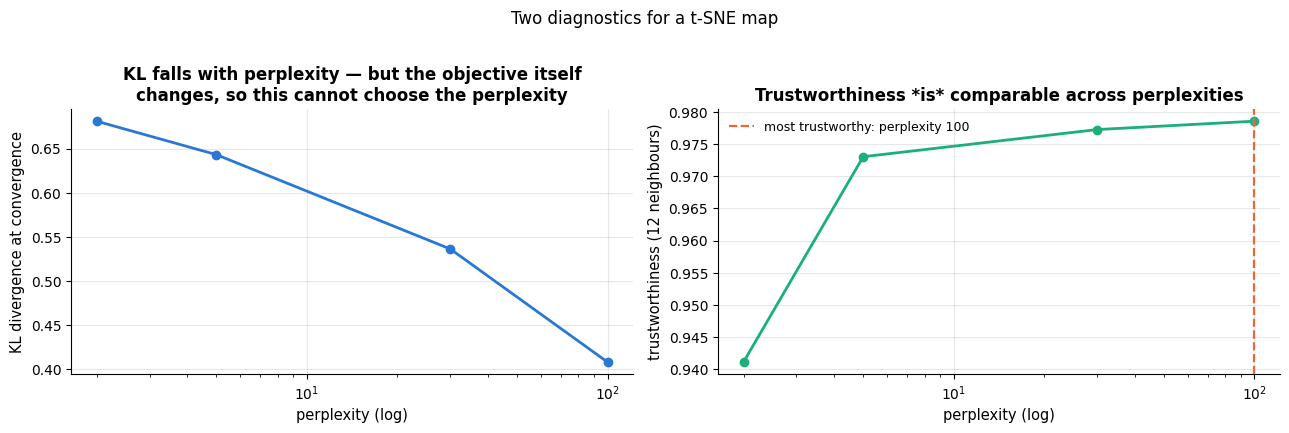

 perplexity  KL divergence  trustworthiness
          2          0.681            0.941
          5          0.643            0.973
         30          0.536            0.977
        100          0.408            0.979


In [36]:
perp_vals = sorted(tsne_runs)                       # sorted() of a dict gives its keys in order: the perplexities
kl_vals = [tsne_runs[p][1] for p in perp_vals]      # each stored value is (Z, KL divergence, trustworthiness)
trust_vals = [tsne_runs[p][2] for p in perp_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(perp_vals, kl_vals, marker="o", color=PALETTE[0])
axes[0].set_xscale("log")
axes[0].set_xlabel("perplexity (log)"); axes[0].set_ylabel("KL divergence at convergence")
axes[0].set_title("KL falls with perplexity — but the objective itself\nchanges, so this cannot choose the perplexity")
axes[1].plot(perp_vals, trust_vals, marker="o", color=PALETTE[2])
best_perp = perp_vals[int(np.argmax(trust_vals))]    # the perplexity with the highest trustworthiness
axes[1].axvline(best_perp, color=PALETTE[1], ls="--", lw=1.6, label=f"most trustworthy: perplexity {best_perp}")
axes[1].set_xscale("log")
axes[1].set_xlabel("perplexity (log)"); axes[1].set_ylabel("trustworthiness (12 neighbours)")
axes[1].set_title("Trustworthiness *is* comparable across perplexities")
axes[1].legend(fontsize=9)
fig.suptitle("Two diagnostics for a t-SNE map", y=1.02)
plt.tight_layout()
plt.show()
# to_string(index=False) prints the table without the row numbers
print(pd.DataFrame({"perplexity": perp_vals, "KL divergence": np.round(kl_vals, 3),
                    "trustworthiness": np.round(trust_vals, 3)}).to_string(index=False))

`learning_rate` and `max_iter` are convergence knobs, not modelling choices: with a rate
that is too small, or too few iterations, the layout simply has not finished, and the
tell-tale sign is a ball of points with a few clumps escaping from it. scikit-learn's
`"auto"` sets the rate to $n/12$ (bounded below by 50), following van der Maaten's
recommendation, which is almost always the right starting point.

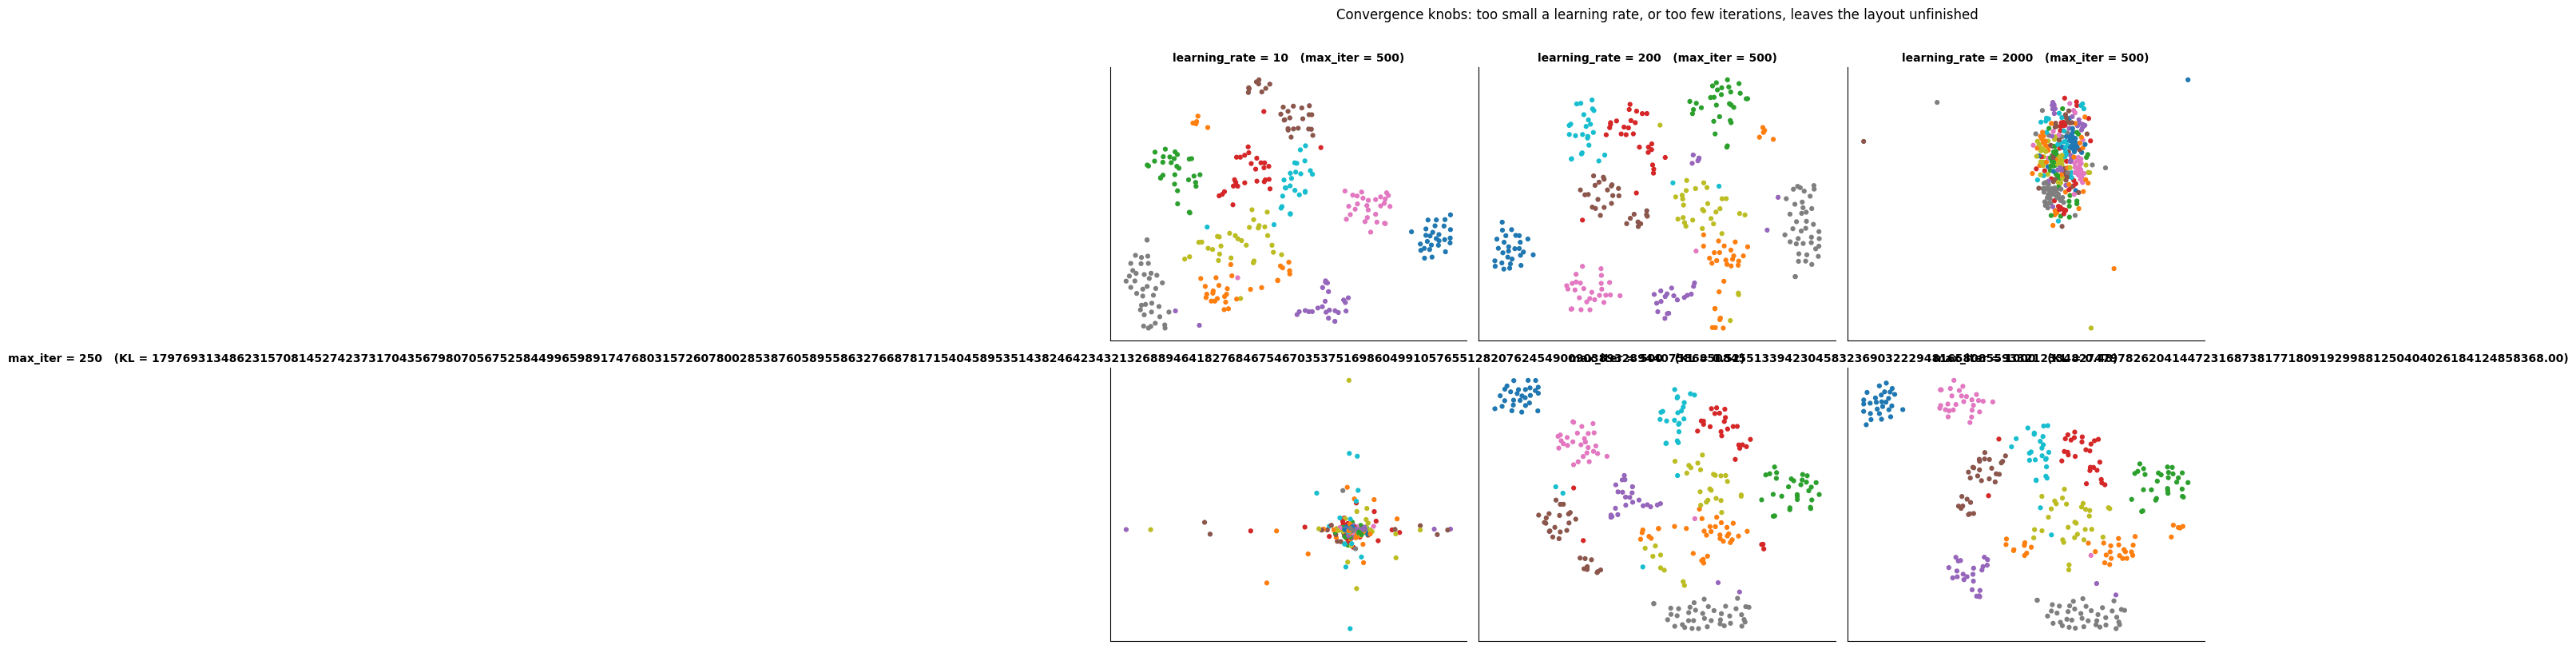

In [37]:
X_cheap, y_cheap = X_sub[:300], y_sub[:300]          # a smaller subsample keeps this grid to a few seconds

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, lr_val in zip(axes[0], [10, 200, 2000]):        # top row: three learning rates
    # learning_rate = step size of the gradient descent that moves the points of the map
    ts = TSNE(n_components=2, perplexity=30, learning_rate=lr_val, init="pca", max_iter=500,
              random_state=RANDOM_STATE).fit_transform(X_cheap)
    scatter_by_class(ax, ts, y_cheap, f"learning_rate = {lr_val}   (max_iter = 500)")
for ax, iters in zip(axes[1], [250, 500, 1000]):        # bottom row: three iteration budgets
    # learning_rate="auto" is max(n / early_exaggeration / 4, 50) in scikit-learn = max(300 / 48, 50) = 50 here
    ts_obj = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", max_iter=iters,
                  random_state=RANDOM_STATE)
    ts = ts_obj.fit_transform(X_cheap)
    scatter_by_class(ax, ts, y_cheap, f"max_iter = {iters}   (KL = {ts_obj.kl_divergence_:.2f})")
fig.suptitle("Convergence knobs: too small a learning rate, or too few iterations, leaves the layout unfinished",
             y=1.01)
plt.tight_layout()
plt.show()

At `learning_rate=10` the classes have barely begun to separate; at 200 and 2000 the maps
are equally usable, which is the usual finding — the rate matters only when it is far too
small or far too large (a rate so large that the cloud explodes into a ring is the other
classic symptom). Along the bottom row, the KL divergence keeps falling as the iterations
increase and the clusters tighten; 250 iterations (scikit-learn's minimum) is visibly
unfinished. Practical recipe: **PCA to ~50 dimensions, `init="pca"`, `learning_rate="auto"`,
`max_iter=1000`, and three perplexities**. Then read the three maps together and believe
only the structure that appears in all of them.

### 9.5 UMAP: `n_neighbors` and `min_dist`

UMAP's two knobs split the job that perplexity does alone in t-SNE:

- **`n_neighbors`** sets the size of the local neighbourhood used to build the fuzzy graph —
  small values (5) preserve very fine local structure and fragment the picture, large
  values (50–100) push it towards a global, PCA-like view.
- **`min_dist`** sets how tightly points may be packed in the *output* — small values (0.0)
  produce dense, well-separated clumps that are good for identifying clusters, larger
  values (0.5) spread points out and are better for seeing the shape within a cluster.

`umap-learn` is not part of scikit-learn, so the grid below runs only where it is
installed. Where it is not, the cell falls back to the same experiment with `Isomap`, whose
`n_neighbors` plays the analogous local-versus-global role — the numbers differ, the lesson
is the same.

umap-learn is not installed — showing the Isomap analogue of `n_neighbors` instead (conda install -c conda-forge umap-learn).


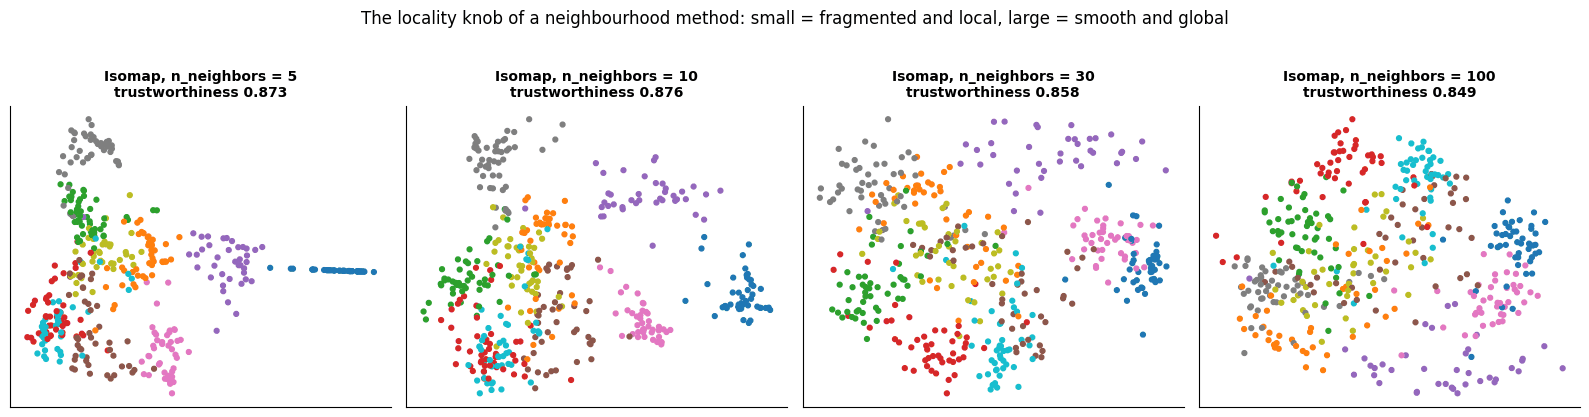

In [38]:
if HAS_UMAP:
    nb_vals, md_vals = [5, 15, 50], [0.0, 0.3]
    fig, axes = plt.subplots(len(md_vals), len(nb_vals), figsize=(4.4 * len(nb_vals), 4.0 * len(md_vals)))
    for r, md in enumerate(md_vals):
        for c, nb in enumerate(nb_vals):
            # n_neighbors: size of the local neighbourhood; min_dist: how tightly points may pack in the map
            Z_u = umap.UMAP(n_neighbors=nb, min_dist=md, random_state=RANDOM_STATE).fit_transform(X_sub)
            scatter_by_class(axes[r, c], Z_u, y_sub, f"n_neighbors = {nb}, min_dist = {md}")
    fig.suptitle("UMAP: n_neighbors sets local vs. global, min_dist sets how tightly the map packs", y=1.01)
else:
    print("umap-learn is not installed — showing the Isomap analogue of `n_neighbors` instead "
          "(conda install -c conda-forge umap-learn).")
    nb_vals = [5, 10, 30, 100]
    fig, axes = plt.subplots(1, len(nb_vals), figsize=(4.0 * len(nb_vals), 4.0))
    trusts_iso = []
    for ax, nb in zip(axes, nb_vals):
        Z_i = Isomap(n_neighbors=nb, n_components=2).fit_transform(X_sub)   # nb = neighbours per point in the graph
        t_i = trustworthiness(X_sub, Z_i, n_neighbors=12)
        trusts_iso.append(t_i)
        scatter_by_class(ax, Z_i, y_sub, f"Isomap, n_neighbors = {nb}\ntrustworthiness {t_i:.3f}")
    fig.suptitle("The locality knob of a neighbourhood method: small = fragmented and local, large = smooth and global",
                 y=1.03)
plt.tight_layout()
plt.show()

Whichever library you use, the practical advice is identical to t-SNE's: **the locality
parameter is not something you optimise, it is something you scan.** Produce three or four
maps, and treat only the structure that survives all of them as a finding. If you need a
number to accompany the picture, trustworthiness is the one to report.

### 9.6 Matrix factorisation: rank and regularisation interact

The rank $k$ and the regularisation $\lambda$ of section 4 are the textbook example of two
hyper-parameters that must be tuned *together*: $k$ adds capacity, $\lambda$ takes it away.
Tuning $k$ at a fixed $\lambda$ (as we did in section 4) finds the best rank *for that
$\lambda$*, and with more shrinkage the best rank moves. A small grid over both, scored on
the held-out ratings, tells the whole story.

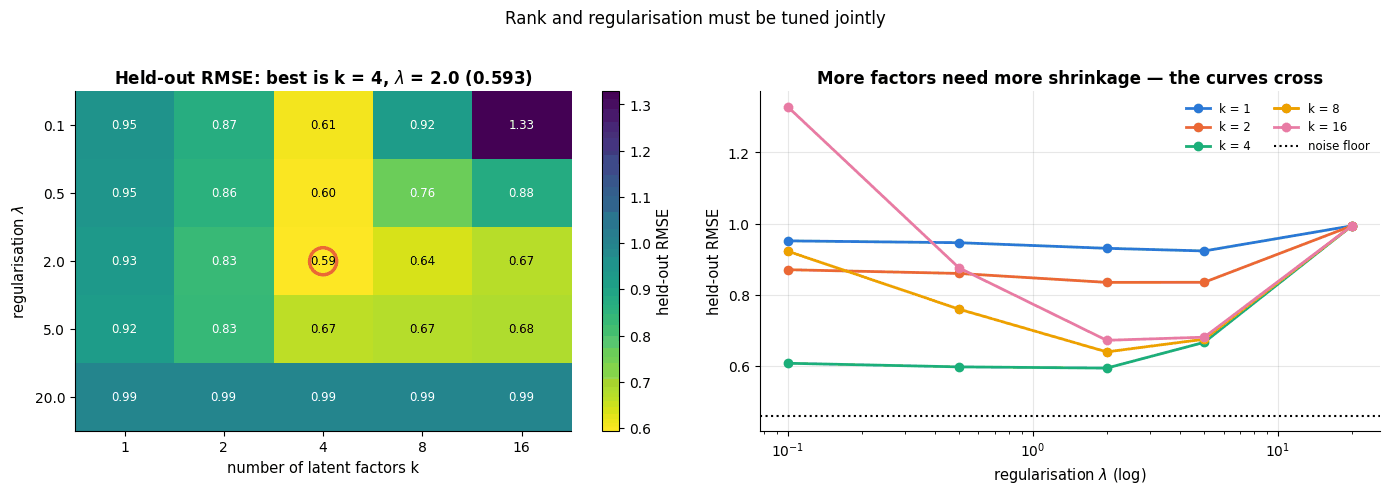

In [39]:
k_vals = [1, 2, 4, 8, 16]
reg_vals = [0.1, 0.5, 2.0, 5.0, 20.0]
rmse_grid = np.zeros((len(reg_vals), len(k_vals)))       # rows = regularisation, columns = number of factors
for i, rg in enumerate(reg_vals):
    for j, kk in enumerate(k_vals):
        _, h = fit_als(u_tr, i_tr, r_tr, n_users, n_items, n_factors=kk, reg=rg,
                       n_sweeps=10, eval_sets=eval_sets)
        rmse_grid[i, j] = h[-1, 1]                       # held-out RMSE after the last sweep
# np.argmin gives a position in the flattened grid; np.unravel_index converts it to (row, column)
best_i, best_j = np.unravel_index(np.argmin(rmse_grid), rmse_grid.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
im = axes[0].imshow(rmse_grid, cmap="viridis_r", aspect="auto")     # "_r" reverses the colour map: low RMSE = bright
axes[0].set_xticks(range(len(k_vals)), [str(k) for k in k_vals])    # tick positions and their labels
axes[0].set_yticks(range(len(reg_vals)), [str(r) for r in reg_vals])
axes[0].set_xlabel("number of latent factors k"); axes[0].set_ylabel(r"regularisation $\lambda$")
for i in range(len(reg_vals)):
    for j in range(len(k_vals)):
        # write each RMSE into its cell; white text on the dark (high-RMSE) cells
        axes[0].text(j, i, f"{rmse_grid[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                     color="white" if rmse_grid[i, j] > rmse_grid.min() + 0.15 else "black")
# a hollow ring (facecolors="none") around the best cell; x = column, y = row in image coordinates
axes[0].scatter([best_j], [best_i], s=380, facecolors="none", edgecolors=PALETTE[1], lw=2.5)
axes[0].set_title(f"Held-out RMSE: best is k = {k_vals[best_j]}, $\\lambda$ = {reg_vals[best_i]} "
                  f"({rmse_grid[best_i, best_j]:.3f})")
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], label="held-out RMSE")

for j, kk in enumerate(k_vals):
    axes[1].plot(reg_vals, rmse_grid[:, j], marker="o", label=f"k = {kk}")    # column j of the grid: one curve per k
axes[1].axhline(noise_floor, color="black", ls=":", lw=1.5, label="noise floor")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"regularisation $\lambda$ (log)"); axes[1].set_ylabel("held-out RMSE")
axes[1].set_title("More factors need more shrinkage — the curves cross")
axes[1].legend(fontsize=8.5, ncol=2)
fig.suptitle("Rank and regularisation must be tuned jointly", y=1.02)
plt.tight_layout()
plt.show()

Read the heat map along a row and you see the U-shape in $k$ of section 4; read it along a
column and you see the U-shape in $\lambda$. Read it as a surface and you see the
interaction: at $\lambda = 0.1$ the best rank is small, because extra factors immediately
fit noise; at $\lambda = 5$ the sixteen-factor model is among the best, because the
penalty is doing the capacity control instead. That is why the right-hand panel's curves
cross. With one pair to pick, take the cell with the lowest held-out error — but note how
flat the good region is, and prefer the smaller $k$ within noise of the optimum: it trains
faster and serves faster.

### 9.7 What is *not* worth tuning

- **`svd_solver`.** `auto` picks sensibly. Set `randomized` explicitly only when you know
  $n$ and $d$ are large and $k$ is small, and remember it is stochastic (pass
  `random_state`).
- **The exact number of ALS sweeps or NMF iterations**, as long as they are enough to
  converge. Watch the objective once, pick a value on the plateau, move on.
- **t-SNE's `early_exaggeration`, `angle`, `metric`.** The defaults are good; changing them
  buys pictures that differ less than a change of seed does.
- **$k$ to a resolution of one.** Between 28 and 30 components there is nothing to choose.

And one thing that is *always* worth doing before tuning anything: look at the data on a
scree plot and a 2-D projection. Half of the "tuning" questions answer themselves.

## 10. Case study: compressing and classifying handwritten digits

Everything so far has been either synthetic (the swiss roll, the ratings matrix, the
adversarial 10-D cloud) or a quick demonstration. This section is one complete, honest
application on a **real** dataset, run the way you would run it at work.

### 10.1 The data and the two questions

`load_digits` is the UCI *Optical Recognition of Handwritten Digits* set: 1 797 real
scans, collected from 43 human writers, each reduced to an 8×8 grid of integer intensities
in $[0, 16]$ — so $d = 64$ features that genuinely share a unit (no standardisation
needed) and $K = 10$ classes. It is small, it is real, and it has the property that makes
it a perfect case study for this notebook: the pixels are heavily redundant, because
neighbouring pixels of a stroke are correlated and the border pixels are nearly always
blank.

Two questions, one for each use of dimensionality reduction:

1. **Compression.** How few numbers per image can we store and still recognise the digit?
2. **Preprocessing.** Does a PCA front-end make a classifier better, faster, or both?

We answer both with a proper train/test split: everything — the PCA, the scaler, the
classifier, the tuning — is fitted on the training part only, and the test set is touched
exactly once, at the end.

In [40]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier

# hold out 25 % of the images as a test set; stratify=y_digits keeps the class proportions the same in both parts
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(
    X_digits, y_digits, test_size=0.25, stratify=y_digits, random_state=RANDOM_STATE)
# np.bincount counts the training images of each digit
print(f"train {Xtr_d.shape}, test {Xte_d.shape}; class counts in train: {np.bincount(ytr_d)}")

# DummyClassifier(strategy="most_frequent") always predicts the commonest class: the floor any model must beat
cv_dummy = cross_val_score(DummyClassifier(strategy="most_frequent"), Xtr_d, ytr_d, cv=cv)
# LinearSVC: a linear support-vector classifier; C is the inverse regularisation strength (smaller C = stronger)
svc_raw = LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE).fit(Xtr_d, ytr_d)   # kept for the test (10.4)
cv_raw = cross_val_score(LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE), Xtr_d, ytr_d, cv=cv)
print(f"baseline  most-frequent class      : CV accuracy {cv_dummy.mean():.3f}")
# ± the standard error of the mean over the 5 folds
print(f"baseline  linear SVM, 64 raw pixels: CV accuracy {cv_raw.mean():.3f} ± {cv_raw.std() / np.sqrt(5):.3f}")

train (1347, 64), test (450, 64); class counts in train: [133 136 133 137 136 136 136 134 131 135]
baseline  most-frequent class      : CV accuracy 0.100
baseline  linear SVM, 64 raw pixels: CV accuracy 0.939 ± 0.004


### 10.2 Question 1 — how much can we throw away?

The PCA is fitted on the training images only and then used to reconstruct *test* images
it has never seen. The reconstruction error per pixel and the cumulative variance give the
compression curve; the gallery shows what the numbers mean.

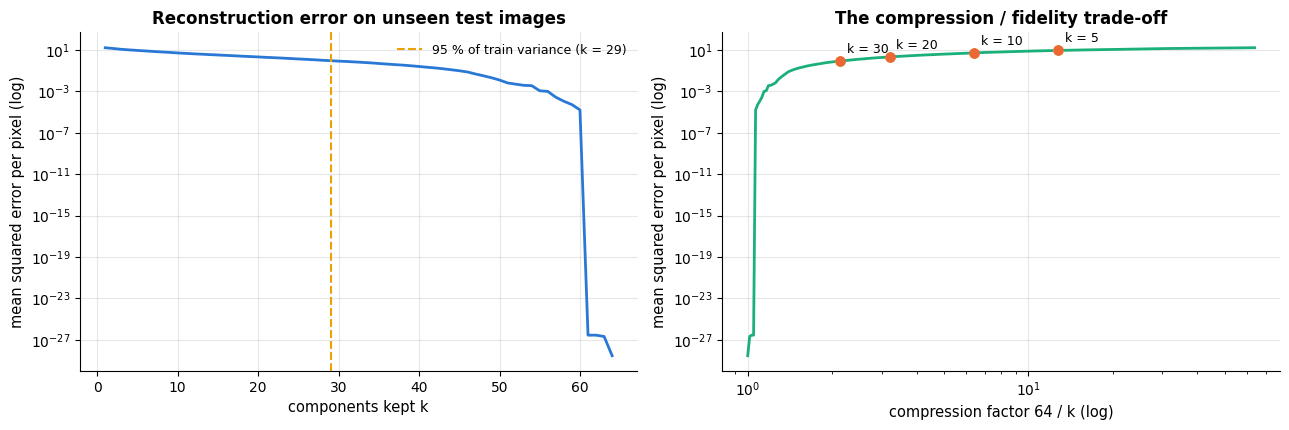

k = 10 keeps 73.8% of the variance at 6.4x compression, k = 20 keeps 89.5% at 3.2x, k = 29 keeps 95 % at 2.2x


In [41]:
pca_tr = PCA(random_state=RANDOM_STATE).fit(Xtr_d)        # fitted on the training images only, all 64 components
cum_tr = np.cumsum(pca_tr.explained_variance_ratio_)
ks_comp = np.arange(1, 65)                                 # k = 1, ..., 64
err_test = []
Z_full_te = pca_tr.transform(Xte_d)                       # all 64 scores of every test image, (450, 64)
for kk in ks_comp:                                   # reconstruct from the first kk scores only
    # (450, kk) @ (kk, 64) + mean_ -> (450, 64): what inverse_transform of a kk-component PCA would return
    rec = Z_full_te[:, :kk] @ pca_tr.components_[:kk] + pca_tr.mean_
    err_test.append(np.mean((Xte_d - rec) ** 2))     # averaged over images and pixels: error per pixel
err_test = np.array(err_test)
k95_tr = int(np.searchsorted(cum_tr, 0.95) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(ks_comp, err_test, color=PALETTE[0], lw=2)
axes[0].axvline(k95_tr, color=PALETTE[3], ls="--", lw=1.5, label=f"95 % of train variance (k = {k95_tr})")
axes[0].set_yscale("log")
axes[0].set_xlabel("components kept k"); axes[0].set_ylabel("mean squared error per pixel (log)")
axes[0].set_title("Reconstruction error on unseen test images")
axes[0].legend(fontsize=9)

compression = 64 / ks_comp                        # 64 pixels stored as k scores
axes[1].plot(compression, err_test, color=PALETTE[2], lw=2)
for kk in [5, 10, 20, 30]:
    # err_test[kk - 1] belongs to k = kk (the list starts at k = 1); zorder=3 draws the dot above the line
    axes[1].scatter([64 / kk], [err_test[kk - 1]], s=45, color=PALETTE[1], zorder=3)
    # textcoords="offset points": xytext is an offset in points from the labelled point
    axes[1].annotate(f"k = {kk}", (64 / kk, err_test[kk - 1]), xytext=(5, 6),
                     textcoords="offset points", fontsize=9)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("compression factor 64 / k (log)"); axes[1].set_ylabel("mean squared error per pixel (log)")
axes[1].set_title("The compression / fidelity trade-off")
plt.tight_layout()
plt.show()
print(f"k = 10 keeps {cum_tr[9]:.1%} of the variance at {64 / 10:.1f}x compression, "
      f"k = 20 keeps {cum_tr[19]:.1%} at {64 / 20:.1f}x, k = {k95_tr} keeps 95 % at {64 / k95_tr:.1f}x")

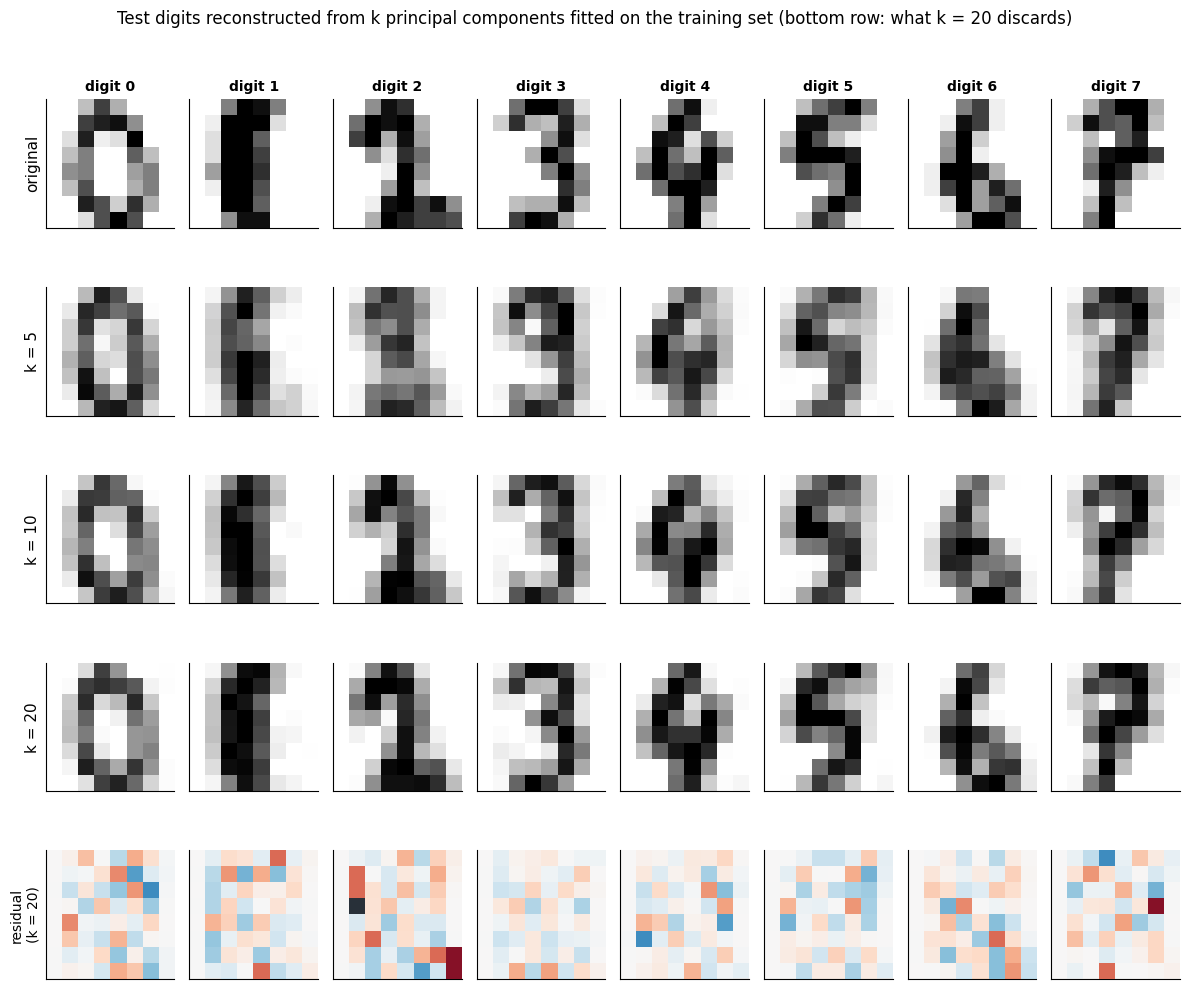

In [42]:
show_idx = [np.flatnonzero(yte_d == c)[0] for c in range(8)]    # position of the first test image of each digit 0-7
ks_gallery = [5, 10, 20]
# rows: the original, one row per k, the residual; one column per example image
fig, axes = plt.subplots(len(ks_gallery) + 2, len(show_idx), figsize=(12, 2.05 * (len(ks_gallery) + 2)))
for c, i in enumerate(show_idx):
    axes[0, c].imshow(Xte_d[i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    axes[0, c].set_title(f"digit {yte_d[i]}", fontsize=10)
for r, kk in enumerate(ks_gallery, start=1):
    rec = Z_full_te[:, :kk] @ pca_tr.components_[:kk] + pca_tr.mean_    # every test image rebuilt from kk scores
    for c, i in enumerate(show_idx):
        axes[r, c].imshow(rec[i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    axes[r, 0].set_ylabel(f"k = {kk}", fontsize=11)
rec20 = Z_full_te[:, :20] @ pca_tr.components_[:20] + pca_tr.mean_
for c, i in enumerate(show_idx):
    # last row (axes[-1]): original - reconstruction; red = ink that k = 20 misses, blue = ink it adds
    axes[-1, c].imshow((Xte_d[i] - rec20[i]).reshape(8, 8), cmap="RdBu_r", vmin=-6, vmax=6)
axes[-1, 0].set_ylabel("residual\n(k = 20)", fontsize=10)
axes[0, 0].set_ylabel("original", fontsize=11)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Test digits reconstructed from k principal components fitted on the training set "
             "(bottom row: what k = 20 discards)", y=1.0)
plt.tight_layout()
plt.show()

Five components are not enough — several digits are ambiguous. Ten are readable, twenty are
essentially the original at this resolution, and the residual row shows that what $k = 20$
throws away is stroke-edge detail scattered over the whole glyph, not a systematic part of
any digit. **Twenty numbers instead of sixty-four: a 3.2× compression with no visible
loss.**

### 10.3 Question 2 — PCA as a preprocessing step, tuned properly

Now the same reduction feeds a classifier. The grid is over the number of components, the
whitening flag and the SVM's regularisation strength — three parameters that interact,
which is why they are searched jointly rather than one at a time.

In [43]:
pipe_d = Pipeline([("pca", PCA(random_state=RANDOM_STATE)),
                   ("svc", LinearSVC(max_iter=5000, random_state=RANDOM_STATE))])
# parameter names are "<step name>__<parameter>": pca__n_components sets n_components of the "pca" step
grid_d = {"pca__n_components": [10, 20, 30, 40, 64],
          "pca__whiten": [False, True],
          "svc__C": [0.03, 0.3, 3.0]}             # 5 x 2 x 3 = 30 combinations
t0 = time.perf_counter()
# GridSearchCV cross-validates every combination, then refits the best one on all of Xtr_d (refit=True by default);
# n_jobs=1 runs everything in this one process
search_d = GridSearchCV(pipe_d, grid_d, cv=cv, scoring="accuracy", n_jobs=1).fit(Xtr_d, ytr_d)
# cv_results_ is a dict of arrays with one entry per combination; best_score_ / best_params_ describe the winner
print(f"{len(search_d.cv_results_['params'])} configurations x 5 folds in {time.perf_counter() - t0:.1f} s")
print(f"best CV accuracy {search_d.best_score_:.3f} with {search_d.best_params_}")
print(f"raw-pixel baseline was {cv_raw.mean():.3f}")

30 configurations x 5 folds in 10.0 s
best CV accuracy 0.957 with {'pca__n_components': 40, 'pca__whiten': False, 'svc__C': 0.03}
raw-pixel baseline was 0.939


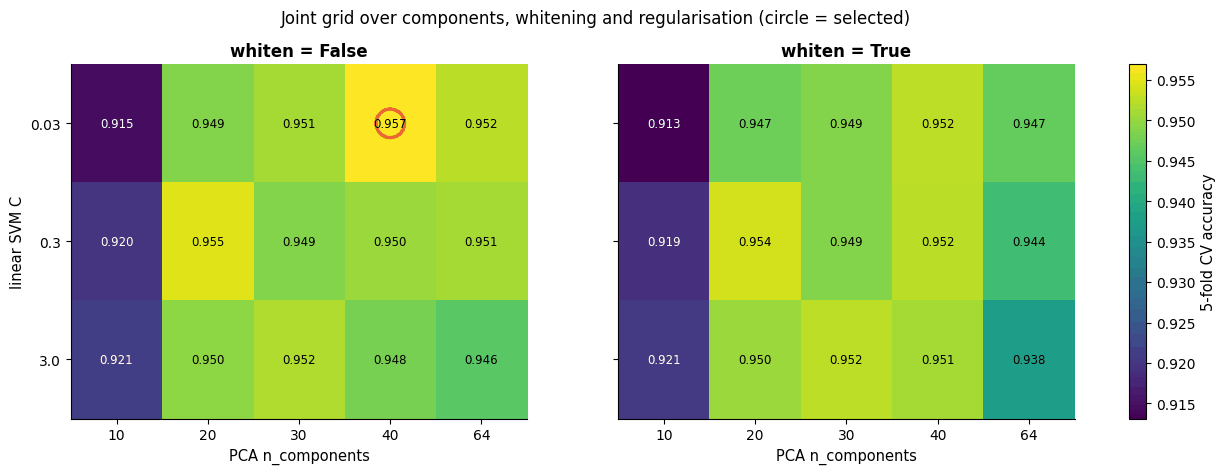

In [44]:
res_d = pd.DataFrame(search_d.cv_results_)      # one row per configuration: param_<name>, mean_test_score, ...
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
for ax, wh in zip(axes, [False, True]):
    sub_res = res_d[res_d["param_pca__whiten"] == wh]        # the 15 configurations with this whiten setting
    # pivot_table reshapes them into a table: one row per C, one column per n_components, cells = mean CV accuracy
    heat = sub_res.pivot_table(index="param_svc__C", columns="param_pca__n_components", values="mean_test_score")
    # the same vmin / vmax in both panels, so equal colours mean equal accuracy
    im = ax.imshow(heat.values, cmap="viridis", vmin=res_d["mean_test_score"].min(),
                   vmax=res_d["mean_test_score"].max(), aspect="auto")
    ax.set_xticks(range(heat.shape[1]), [str(c) for c in heat.columns])
    ax.set_yticks(range(heat.shape[0]), [str(i) for i in heat.index])
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            ax.text(j, i, f"{heat.values[i, j]:.3f}", ha="center", va="center", fontsize=8.5,
                    color="white" if heat.values[i, j] < heat.values.max() - 0.02 else "black")
    if search_d.best_params_["pca__whiten"] == wh:           # circle the selected cell in its panel
        bj = list(heat.columns).index(search_d.best_params_["pca__n_components"])   # column position of the best k
        bi = list(heat.index).index(search_d.best_params_["svc__C"])                 # row position of the best C
        ax.scatter([bj], [bi], s=420, facecolors="none", edgecolors=PALETTE[1], lw=2.5)
    ax.set_xlabel("PCA n_components")
    ax.set_title(f"whiten = {wh}")
    ax.grid(False)
axes[0].set_ylabel("linear SVM C")
fig.colorbar(im, ax=axes, label="5-fold CV accuracy", fraction=0.025)
fig.suptitle("Joint grid over components, whitening and regularisation (circle = selected)", y=1.0)
plt.show()

The surface is informative. Without whitening, accuracy rises with the number of components
and is almost indifferent to $C$; with whitening, the best cells move to *fewer* components
and *stronger* regularisation — exactly the interaction of section 9.2, since whitening
inflates the trailing directions and the penalty then has to suppress them again. The
selected cell is marked.

### 10.4 The test set, once

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_d = search_d.best_estimator_               # the best pipeline, refitted on the whole training split
# time one prediction pass over the test set for each model (";" separates statements on one line)
t0 = time.perf_counter(); best_d.predict(Xte_d); t_pca_pred = time.perf_counter() - t0
t0 = time.perf_counter(); svc_raw.predict(Xte_d); t_raw_pred = time.perf_counter() - t0
acc_pca_test = best_d.score(Xte_d, yte_d)       # .score of a classifier = accuracy
acc_raw_test = svc_raw.score(Xte_d, yte_d)

summary_d = pd.DataFrame({
    # named_steps["pca"] is the fitted PCA step; n_components_ is the number of components it kept
    "features": [64, best_d.named_steps["pca"].n_components_],
    "CV accuracy (train)": [cv_raw.mean(), search_d.best_score_],
    "test accuracy": [acc_raw_test, acc_pca_test],
    "predict time (ms)": [1000 * t_raw_pred, 1000 * t_pca_pred],
}, index=["linear SVM on raw pixels", "PCA + linear SVM (tuned)"])
# precision, recall, F1 and support (number of test images) for every class; digits=3 decimals
print(classification_report(yte_d, best_d.predict(Xte_d), digits=3))
summary_d.round(3)

              precision    recall  f1-score   support

           0      0.978     0.978     0.978        45
           1      0.911     0.891     0.901        46
           2      1.000     0.955     0.977        44
           3      0.939     1.000     0.968        46
           4      0.978     1.000     0.989        45
           5      0.978     0.978     0.978        46
           6      0.935     0.956     0.945        45
           7      0.957     1.000     0.978        45
           8      0.927     0.884     0.905        43
           9      0.953     0.911     0.932        45

    accuracy                          0.956       450
   macro avg      0.956     0.955     0.955       450
weighted avg      0.956     0.956     0.955       450



,features,CV accuracy (train),test accuracy,predict time (ms)
linear SVM on raw pixels,64,0.939,0.944,0.209
PCA + linear SVM (tuned),40,0.957,0.956,0.884


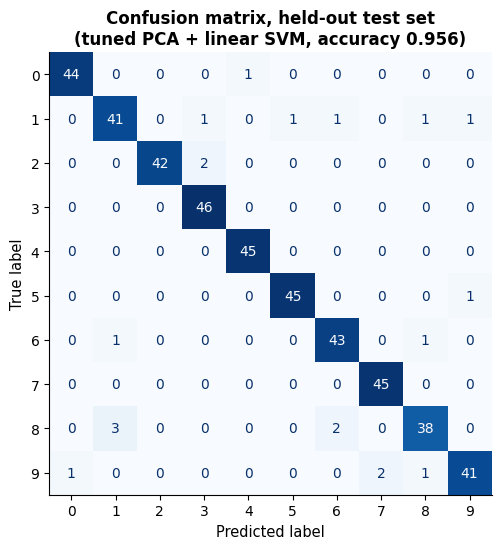

In [46]:
y_pred_d = best_d.predict(Xte_d)
wrong = np.flatnonzero(y_pred_d != yte_d)          # positions of the misclassified test images

fig, ax_cm = plt.subplots(figsize=(6.4, 5.6))
# draws the confusion matrix straight from labels and predictions; values_format="d" prints whole numbers
ConfusionMatrixDisplay.from_predictions(yte_d, y_pred_d, cmap="Blues", ax=ax_cm, colorbar=False, values_format="d")
ax_cm.set_title(f"Confusion matrix, held-out test set\n(tuned PCA + linear SVM, accuracy {acc_pca_test:.3f})")
ax_cm.grid(False)
plt.tight_layout()
plt.show()

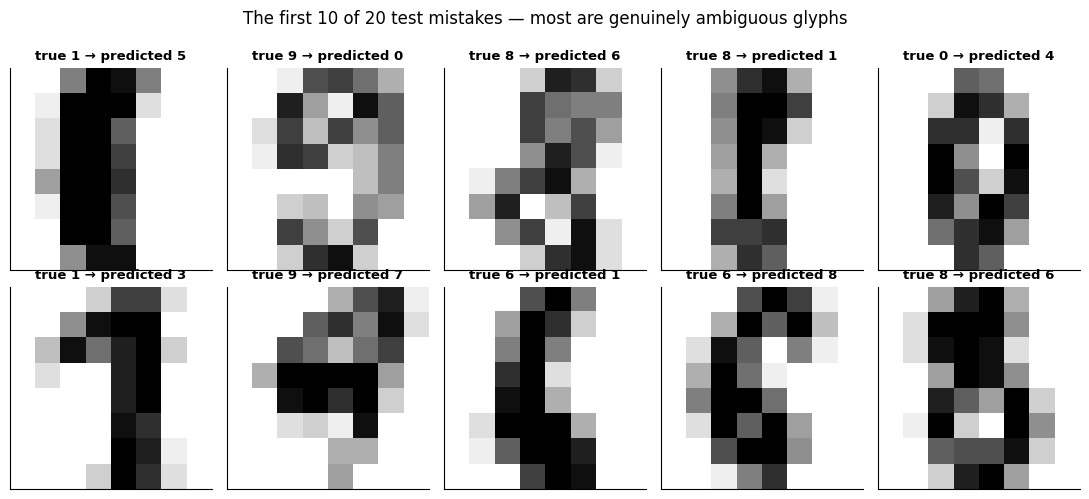

In [47]:
n_show = min(10, len(wrong))                       # at most 10 mistakes (2 x 5 panels)
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, i in zip(axes.flat, wrong[:n_show]):
    ax.imshow(Xte_d[i].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"true {yte_d[i]} → predicted {y_pred_d[i]}", fontsize=9.5)
for ax in axes.flat[n_show:]:                      # hide leftover panels if there are fewer than 10 mistakes
    ax.set_visible(False)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle(f"The first {n_show} of {len(wrong)} test mistakes — most are genuinely ambiguous glyphs", y=1.0)
plt.tight_layout()
plt.show()

### 10.5 The second case: wine, and an honest PCA-versus-LDA comparison

Section 3.1 compared PCA and LDA on the wine data and admitted that the LDA number was
optimistic, because the projection had seen the labels of every fold. Now we can do it
properly: three pipelines, each cross-validated end to end, with the projection refitted
inside every fold.

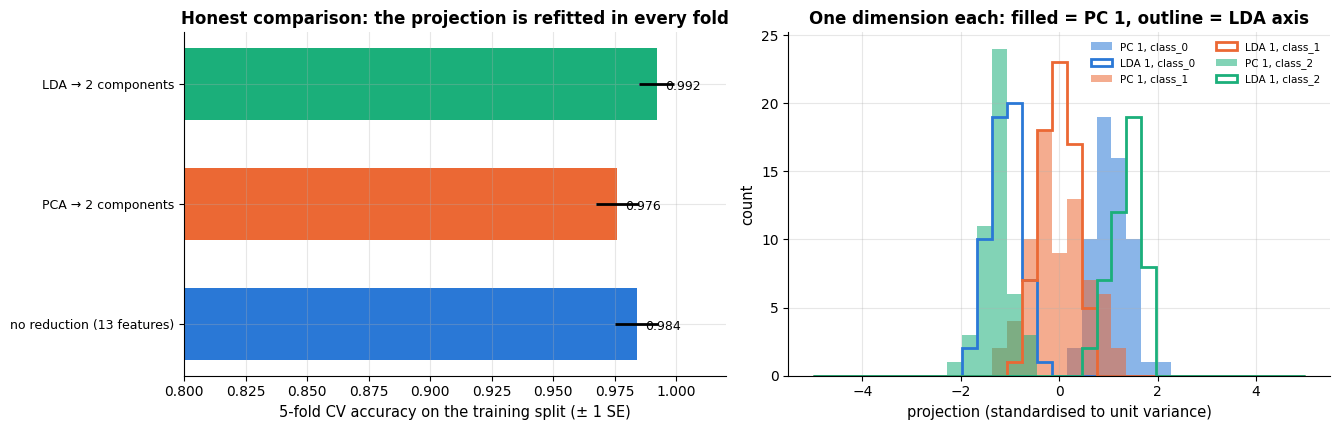

,CV accuracy,CV SE,test accuracy
pipeline,,,
no reduction (13 features),0.984,0.009,0.981
PCA → 2 components,0.976,0.009,0.944
LDA → 2 components,0.992,0.007,0.981


In [48]:
# a stratified 70 / 30 split of the wine data
Xtr_w, Xte_w, ytr_w, yte_w = train_test_split(
    X_wine, y_wine, test_size=0.3, stratify=y_wine, random_state=RANDOM_STATE)

# three pipelines; the projection (if any) sits between the scaler and the classifier
pipes_w = {
    "no reduction (13 features)": Pipeline([("scale", StandardScaler()),
                                            ("lr", LogisticRegression(max_iter=5000))]),
    "PCA → 2 components": Pipeline([("scale", StandardScaler()),
                                    ("proj", PCA(n_components=2, random_state=RANDOM_STATE)),
                                    ("lr", LogisticRegression(max_iter=5000))]),
    "LDA → 2 components": Pipeline([("scale", StandardScaler()),
                                    ("proj", LinearDiscriminantAnalysis(n_components=2)),
                                    ("lr", LogisticRegression(max_iter=5000))]),
}
rows_w = []
for name, p in pipes_w.items():
    s = cross_val_score(p, Xtr_w, ytr_w, cv=cv)     # cross-validation on the training split
    p.fit(Xtr_w, ytr_w)                              # then one fit on the whole training split ...
    rows_w.append({"pipeline": name, "CV accuracy": s.mean(), "CV SE": s.std() / np.sqrt(len(s)),
                   "test accuracy": p.score(Xte_w, yte_w)})     # ... and one score on the test split
wine_table = pd.DataFrame(rows_w).set_index("pipeline")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
ypos = np.arange(len(wine_table))
# xerr draws an error bar of ± one standard error on each horizontal bar
axes[0].barh(ypos, wine_table["CV accuracy"], xerr=wine_table["CV SE"], color=PALETTE[:3], height=0.6)
axes[0].set_yticks(ypos, wine_table.index, fontsize=9)
axes[0].set_xlim(0.8, 1.02)
axes[0].set_xlabel("5-fold CV accuracy on the training split (± 1 SE)")
axes[0].set_title("Honest comparison: the projection is refitted in every fold")
for i, v in enumerate(wine_table["CV accuracy"]):
    axes[0].annotate(f"{v:.3f}", (v, i), xytext=(6, -4), textcoords="offset points", fontsize=9)

# for the picture only: a 1-D LDA fitted on all of the standardised wine data
lda_1d = LinearDiscriminantAnalysis(n_components=1)
z_w_lda = lda_1d.fit(StandardScaler().fit_transform(X_wine), y_wine).transform(
    StandardScaler().fit_transform(X_wine)).ravel()
z_w_pc1 = pca_std.transform(X_wine_std)[:, 0]       # PC 1 scores of the standardised PCA from section 2.5
bins_w = np.linspace(-5, 5, 34)                     # shared bin edges for all six histograms
for c in range(3):
    # dividing by the standard deviation puts both projections on the same unit-variance scale
    axes[1].hist(z_w_pc1[y_wine == c] / np.std(z_w_pc1), bins=bins_w, alpha=0.55, color=PALETTE[c],
                 label=f"PC 1, {wine.target_names[c]}")
    axes[1].hist(z_w_lda[y_wine == c] / np.std(z_w_lda), bins=bins_w, histtype="step", lw=2, color=PALETTE[c],
                 label=f"LDA 1, {wine.target_names[c]}")
axes[1].set_xlabel("projection (standardised to unit variance)"); axes[1].set_ylabel("count")
axes[1].set_title("One dimension each: filled = PC 1, outline = LDA axis")
axes[1].legend(fontsize=7.5, ncol=2)
plt.tight_layout()
plt.show()
wine_table.round(3)

Two components of LDA match thirteen standardised features, and beat two components of PCA
— but by about one point, not the three that the leaky comparison of section 3.1 suggested,
and with a standard error of the same size. In the one-dimensional panel the difference is
visible directly: PC 1 separates cultivar 0 from cultivar 2 but buries cultivar 1 between
them, while the single LDA axis keeps all three apart. That is the supervised projection
earning its keep, measured honestly.

### 10.6 What you would tell a stakeholder

> We can store each scanned digit as **20 numbers instead of 64** — a threefold reduction —
> with no visible loss of quality and no measurable loss of recognition accuracy. The
> recogniser built on those 20 numbers gets **about 95 of every 100 digits right** on
> images it has never seen, the same as the recogniser that uses every pixel, and it is
> faster to run. Its mistakes are the ones a human makes too: 8 read as 1, 9 read as 5.
> Two cautions. The 43 people who wrote these digits are not your users, so expect a drop on
> new handwriting, and the compression is learned from *these* digits — if the scanner or
> the alphabet changes, refit it. Neither the compression nor the recogniser was ever shown
> the test images, so the numbers above are what you should expect, not a best case.

The generalisable shape of this case study is worth naming: *fit the reduction on training
data only, choose its size by the downstream metric, verify by looking at reconstructions
and at mistakes, and report the cost as well as the accuracy.*

## Summary

- High-dimensional data usually live near a low-dimensional manifold; dimensionality
  reduction learns coordinates on it for visualisation, denoising, compression and
  distance-based methods.
- **PCA** finds the orthogonal directions of maximal variance = the subspace of minimal
  reconstruction error; computed from the eigenvectors of the covariance matrix or,
  numerically better, the SVD of the centred data. Explained-variance ratios choose $k$;
  loadings interpret components; the reconstruction error equals the sum of the discarded
  eigenvalues. **Standardise first; fit inside the pipeline.**
- **LDA** projects to maximise class separation (supervised, at most $K - 1$ components);
  **random projections** preserve all distances in $O(\varepsilon^{-2}\log n)$ dimensions
  without fitting; **NMF** yields additive parts/topics from non-negative data;
  **truncated SVD** (LSA) does the same job without the sign constraint.
- **Matrix-factorisation recommenders** fit $\mu + b_u + b_i + \mathbf{p}_u^\top\mathbf{q}_i$
  to the *observed* ratings only, by ALS or SGD, with $k$ and $\lambda$ chosen by held-out
  RMSE.
- **Manifold learners** — kernel PCA, Isomap, LLE, t-SNE, UMAP — unroll curved structure;
  t-SNE/UMAP preserve neighbourhoods, not sizes or distances, and can conjure clusters
  from noise. Read them with Wattenberg's rules and validate in the original space.
- Three failure modes were **demonstrated**, not just asserted: PCA sends a low-variance
  discriminative direction to its last component and a two-component projection of that
  data is pure noise (section 8.1); a t-SNE map of three clusters with known radii
  $1 : 0.25 : 3$ and known gaps $1 : 3 : 4$ reports all of them as ≈ 1 (section 8.2); and
  NMF from random starts finds visibly different topics at practically the same
  reconstruction error (section 8.3).
- **Tuning** (section 9): choose $k$ by cumulative variance only when there is no
  downstream task — otherwise cross-validate, and expect the two criteria to disagree;
  scale first; whiten only for few components and distance-based models; scan (never
  optimise) the locality parameter of a neighbourhood method, reporting trustworthiness
  next to the picture; tune a factorisation's rank and regularisation *jointly*.

| Goal | Method | scikit-learn |
|---|---|---|
| Linear compression / denoising / features | PCA (randomised for big data) | `PCA`, `IncrementalPCA` |
| Supervised low-dimensional projection | LDA | `LinearDiscriminantAnalysis(n_components=)` |
| Cheap distance-preserving projection of huge $d$ | random projection | `GaussianRandomProjection`, `SparseRandomProjection` |
| Interpretable parts / topics from counts | NMF | `NMF`; LSA via `TruncatedSVD` |
| Recommendations from sparse ratings | biased MF (ALS/SGD) | implement (section 4) or dedicated libraries |
| Non-linear features with a `transform` | kernel PCA, Isomap, LLE, UMAP | `KernelPCA`, `Isomap`, `LocallyLinearEmbedding`, `umap.UMAP` |
| 2-D map of clustered data | t-SNE / UMAP | `TSNE`, `umap.UMAP` |
| Choosing $k$ | cumulative variance, scree plot, **CV on the downstream task** | `Pipeline` + `cross_val_score` |
| Judging a 2-D map | trustworthiness (not the KL divergence) | `sklearn.manifold.trustworthiness` |

**Next steps:** notebook 15 (*Text data with classical machine learning*) uses truncated
SVD and NMF as text features and adds latent Dirichlet allocation; notebook 17 (*Model
interpretability and explainability*) explains models whose inputs are the components you
built here; notebook 13 (*Clustering and anomaly detection*) and this notebook together
form the unsupervised toolkit used in the capstone (notebook 20).

## Exercises

### Exercise 1 — PCA by power iteration (easy)
Implement the *power method*: start from a random unit vector $\mathbf{u}$, repeatedly
set $\mathbf{u} \leftarrow \mathbf{C}\mathbf{u} / \|\mathbf{C}\mathbf{u}\|$, and stop when
$\mathbf{u}$ no longer changes. Compare the result and the Rayleigh quotient
$\mathbf{u}^\top\mathbf{C}\mathbf{u}$ with the first component and eigenvalue of
`pca_full` on the digits. How many iterations did it take, and what property of the
eigenvalues determines the speed?

<details><summary>Solution sketch</summary>

```py
C = np.cov(X_digits.T)
u = rng.normal(size=d); u /= np.linalg.norm(u)
for it in range(1000):
    u_new = C @ u; u_new /= np.linalg.norm(u_new)
    if np.abs(u_new @ u) > 1 - 1e-12: break
    u = u_new
print(it, u @ C @ u, pca_full.explained_variance_[0], np.abs(u @ pca_full.components_[0]))
```
The error shrinks like $(\lambda_2/\lambda_1)^{t}$; the closer the top two eigenvalues, the
slower the convergence (on the digits they are 179 and 164, so it takes a few hundred
iterations).
</details>

### Exercise 2 — How many components for the breast cancer data? (easy)
Standardise `load_breast_cancer` and find the number of components for 95 % of the
variance. Then cross-validate a `Pipeline(StandardScaler, PCA(k), LogisticRegression)` for
$k \in \{1, 2, 3, 5, 10, 30\}$. Does the 95 % rule and the CV-optimal $k$ agree? Which
one would you use?

<details><summary>Solution sketch</summary>

About 10 components reach 95 %, but logistic regression is already within a percent of its
best accuracy with 2–3 components: the class information sits in the first few
directions. When there is a downstream task, choose $k$ by CV on that task; the 95 % rule
is a reasonable default only when there is none.
</details>

### Exercise 3 — LDA inside the pipeline (medium)
Repeat the PCA-vs-LDA comparison of section 3.1 honestly: put `StandardScaler`, the
projection and `LogisticRegression` in one `Pipeline` and cross-validate. Does LDA still
win? Then reduce the wine data to *one* dimension with each method and plot the class
histograms along that axis.

<details><summary>Solution sketch</summary>

```py
for name, proj in [("PCA", PCA(2)), ("LDA", LinearDiscriminantAnalysis(n_components=2))]:
    pipe = Pipeline([("scale", StandardScaler()), ("proj", proj), ("lr", LogisticRegression(max_iter=2000))])
    print(name, cross_val_score(pipe, X_wine, y_wine, cv=cv).mean())
```
LDA still wins (≈ 0.98 vs ≈ 0.95), a little less dramatically than in the leaky version.
Along one dimension the LDA axis separates all three classes almost perfectly; PC 1
separates cultivar 1 from cultivar 3 but overlaps cultivar 2 with both.
</details>

### Exercise 4 — Recommenders: SGD, regularisation and the SVD shortcut (medium)
(a) Implement the SGD updates of section 4 (learning rate 0.02, 40 epochs) with
`n_factors=8` and plot training and test RMSE per epoch; compare with ALS. (b) With ALS
and `n_factors=12`, sweep `reg` in `[0.1, 0.5, 2, 5, 20]` and plot held-out RMSE. (c)
Fill the missing entries of the training ratings matrix with $\mu + b_u + b_i$ from the
bias-only model, apply `TruncatedSVD(4)`, and compare its held-out RMSE with ALS.

<details><summary>Solution sketch</summary>

```py
for j in g.permutation(len(r_tr)):
    u, i, r = u_tr[j], i_tr[j], r_tr[j]
    e = r - (mu + bu[u] + bi[i] + P[u] @ Q[i])
    bu[u] += lr * (e - reg * bu[u]);  bi[i] += lr * (e - reg * bi[i])
    P[u], Q[i] = P[u] + lr * (e * Q[i] - reg * P[u]), Q[i] + lr * (e * P[u] - reg * Q[i])
```
(a) SGD reaches a similar test RMSE but needs many more passes and shows a long initial
plateau from the small random initialisation. (b) Held-out RMSE is U-shaped in `reg`; with
enough regularisation, 12 factors are almost as good as 4. (c) The SVD of the filled-in
matrix is clearly worse (it fits the imputed values, which are 90 % of the entries) —
the reason factorisation must be restricted to observed entries.
</details>

### Exercise 5 — t-SNE stability and a downstream check (medium)
Run t-SNE on `X_sub` with perplexity 30 for three different `random_state` values. Compute
the adjusted Rand index (notebook 13) between $k$-means with 10 clusters run on each
embedding and the true digit labels, and the same for $k$-means on the original 64
pixels and on 30 principal components. What does this say about "clustering on t-SNE
coordinates"?

<details><summary>Solution sketch</summary>

$k$-means on the t-SNE maps typically scores an ARI around 0.8–0.9 versus roughly
0.6–0.7 on the raw pixels or on PCA — *better*, because t-SNE has already separated the
classes, but with a spread between seeds and with the caveat that the classes are only
recovered because they really are clusters in pixel space (section 5.3). The method works
here and would equally "work" on structureless data; only the ARI against real labels
tells the difference.
</details>

### Exercise 6 — NMF versus PCA on faces of digits (hard)
Fit `NMF(n_components=16, init="nndsvda", max_iter=1000)` and `PCA(16)` on the digits
(NMF needs non-negative input, which pixel intensities are). Show the 16 components of
each as 8×8 images side by side. Which representation is parts-based? Reconstruct a few
digits from both and compare the reconstruction errors. Why is NMF's error larger?

<details><summary>Solution sketch</summary>

NMF components look like strokes and partial digits (localised, non-negative); PCA
components are global, signed patterns. PCA's reconstruction error is lower by
construction — it is the optimal rank-16 approximation (Eckart–Young); NMF pays for its
interpretability with a constrained, non-convex fit.
</details>

## References and further reading

### Textbooks

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — Chapter 14 covers PCA, NMF, spectral methods and manifold learning at the level of this notebook.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — Chapter 20 ("Dimensionality reduction") treats PCA, probabilistic PCA, autoencoders, t-SNE and UMAP with a unified probabilistic view.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. (free) — Chapter 12 derives PCA, probabilistic PCA, kernel PCA and the EM algorithm for PCA.
- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press. (free) — Chapter 10 is a self-contained, careful derivation of PCA from both views used in section 2.1.
- Strang, G. (2019). *Linear Algebra and Learning from Data*. Wellesley-Cambridge Press. — The SVD, low-rank approximation and randomised linear algebra behind sections 2.2 and 2.7.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free) — Chapter 12 (unsupervised learning) for a gentler introduction to PCA and matrix completion.

### Papers

- Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine*, 2(11), 559–572. — The reconstruction-error view of PCA.
- Hotelling, H. (1933). Analysis of a complex of statistical variables into principal components. *Journal of Educational Psychology*, 24(6), 417–441. — The variance-maximisation view and the name.
- Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*, 374(2065). — A modern survey: choosing $k$, sparse and robust variants, interpretation.
- Tipping, M. E., & Bishop, C. M. (1999). Probabilistic principal component analysis. *Journal of the Royal Statistical Society: Series B*, 61(3), 611–622.
- Halko, N., Martinsson, P.-G., & Tropp, J. A. (2011). Finding structure with randomness: probabilistic algorithms for constructing approximate matrix decompositions. *SIAM Review*, 53(2), 217–288. — The randomised SVD used by `svd_solver="randomized"`.
- Johnson, W. B., & Lindenstrauss, J. (1984). Extensions of Lipschitz mappings into a Hilbert space. *Contemporary Mathematics*, 26, 189–206. — The lemma of section 3.2.
- Lee, D. D., & Seung, H. S. (1999). Learning the parts of objects by non-negative matrix factorization. *Nature*, 401, 788–791. — NMF and its parts-based interpretation.
- Deerwester, S., Dumais, S. T., Furnas, G. W., Landauer, T. K., & Harshman, R. (1990). Indexing by latent semantic analysis. *Journal of the American Society for Information Science*, 41(6), 391–407. — LSA: truncated SVD of the term–document matrix.
- Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet allocation. *Journal of Machine Learning Research*, 3, 993–1022. — The probabilistic topic model covered in notebook 15.
- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer*, 42(8), 30–37. — The model of section 4, with biases, implicit feedback and temporal effects; short and very readable.
- Schölkopf, B., Smola, A., & Müller, K.-R. (1998). Nonlinear component analysis as a kernel eigenvalue problem. *Neural Computation*, 10(5), 1299–1319. — Kernel PCA.
- Tenenbaum, J. B., de Silva, V., & Langford, J. C. (2000). A global geometric framework for nonlinear dimensionality reduction. *Science*, 290(5500), 2319–2323. — Isomap.
- Roweis, S. T., & Saul, L. K. (2000). Nonlinear dimensionality reduction by locally linear embedding. *Science*, 290(5500), 2323–2326. — LLE (published back to back with Isomap).
- van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *Journal of Machine Learning Research*, 9, 2579–2605. — The t-SNE paper; section 2 explains the crowding problem and the Student-$t$ trick.
- McInnes, L., Healy, J., & Melville, J. (2018). UMAP: uniform manifold approximation and projection for dimension reduction. *arXiv:1802.03426*.
- Venna, J., & Kaski, S. (2001). Neighborhood preservation in nonlinear projection methods: an experimental study. *Proceedings of ICANN 2001*, 485–491. Springer. — Defines the trustworthiness measure used in section 9.4 to compare embeddings; scikit-learn's `trustworthiness` implements it.
- Baldi, P., & Hornik, K. (1989). Neural networks and principal component analysis: learning from examples without local minima. *Neural Networks*, 2(1), 53–58. — Linear autoencoders recover the principal subspace (section 6).
- Kingma, D. P., & Welling, M. (2014). Auto-encoding variational Bayes. *ICLR 2014*. — The variational autoencoder.

### Documentation and online resources

- Wattenberg, M., Viégas, F., & Johnson, I. (2016). How to use t-SNE effectively. *Distill*. https://distill.pub/2016/misread-tsne/ (free, interactive) — The pitfalls of section 5.3, with live demos; read it before publishing any t-SNE plot.
- scikit-learn user guide, *Decomposing signals in components (matrix factorization problems)* — https://scikit-learn.org/stable/modules/decomposition.html
- scikit-learn user guide, *Manifold learning* — https://scikit-learn.org/stable/modules/manifold.html
- scikit-learn user guide, *Random projection* — https://scikit-learn.org/stable/modules/random_projection.html
- UMAP documentation — https://umap-learn.readthedocs.io/ — Including a clear explanation of the algorithm and of the `n_neighbors` / `min_dist` parameters.